## End-to-End HHL Validation for Graph-Based Credit Risk Propagation (Qubitization + QPE + Chebyshev)

In [1]:
"""
Notebook goal:
--------------

Construct and validate a complete executable HHL pipeline
for graph-based credit-risk propagation models using a
qubitization-compatible architecture.

The linear system of interest is

    A x = b

where A is a sparse Hermitian matrix arising from one of
the following financial contagion models:

Model 1:
    A = L + mu I

Model 2:
    A = I - alpha P_sym

with

    L      = graph Laplacian
    P_sym  = symmetric normalized adjacency matrix.

The notebook implements and validates the following HHL
workflow:

1. Sparse financial graph construction
2. Linear-system assembly
3. Sparse shock-state preparation |b>
4. Walk-operator-based QPE architecture
5. Eigenvalue encoding into a phase register
6. Chebyshev approximation of the reciprocal rotation
7. Boolean synthesis of the HHL rotation
8. Inverse QPE
9. Ancilla post-selection
10. Extraction of the quantum solution state |x>
11. Comparison against the classical solution
12. Financial readout procedures

The notebook performs full statevector validation of the
algorithm and compares the resulting quantum solution
against the classical reference solution

    x = A^{-1} b.

The following quantities are evaluated:

    - Fidelity
    - L1 error
    - L2 error
    - L-infinity error
    - Residual norm ||Ax - b||

The notebook additionally validates two application-level
readout modes relevant to credit-risk propagation:

    1. Top-k risky node discovery
    2. Single-node risk estimation

including both histogram-based sampling and direct
projector measurements of the observable

    |eta><eta|.

Unlike Version 1, the reciprocal-rotation stage is
implemented using an explicit Boolean-synthesized quantum
circuit, eliminating the polynomial lookup-table
construction and uncomputation while preserving the
overall HHL architecture.

Several high-level components (walk operators and sparse
Hamiltonian simulation blocks) are still represented as
validated oracle-level unitaries rather than fault-
tolerant gate decompositions. The focus is verification
of algorithmic correctness, register conventions, state
evolution, executable Boolean rotation synthesis, and
financial readout methodology.

Subsequent notebooks will replace these oracle-level
components with explicit circuit constructions suitable
for qubitization and sparse Hamiltonian simulation.
"""

# ============================================================
# Cell 1 : Imports and Initializations
# ============================================================

# -----------------------
# Qiskit
# -----------------------
from qiskit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate
from qiskit_aer import AerSimulator

# -----------------------
# Numerical libraries
# -----------------------
import numpy as np
import scipy.linalg as la
import scipy.sparse as sp
import scipy.sparse.linalg as spla


# -----------------------
# Plotting
# -----------------------
import matplotlib.pyplot as plt

# -----------------------
# Miscellaneous
# -----------------------
import math as m
import warnings

warnings.filterwarnings('ignore')

# -----------------------
# Custom utility functions
# -----------------------
import Our_Qiskit_Functions as oq

# ============================================================
# Simulators
# ============================================================

state_sim = AerSimulator(method='statevector')
qasm_sim = AerSimulator()

# ============================================================
# Global NumPy settings
# ============================================================

np.set_printoptions(
    precision=4,
    suppress=True,
    linewidth=150
)

# ============================================================
# Random seed
# ============================================================

SEED = 42
rng = np.random.default_rng(SEED)

print("Imports successful.")
print(f"Random seed = {SEED}")

Imports successful.
Random seed = 42


In [2]:
# ============================================================
# Cell 2 : Master Configuration
# ============================================================

# -----------------------
# Problem size
# -----------------------

# Total number of nodes INCLUDING dummy nodes.
# Must be a power of 2.
N = 32

# Number of system qubits
n = int(np.log2(N))

assert 2**n == N, "N must be a power of 2."

# -----------------------
# Shock vector sparsity
# -----------------------

# gamma = 2^{ floor(log2( SHOCK_SPARSITY_FACTOR * log2(N) )) }

SHOCK_SPARSITY_FACTOR = 2

assert SHOCK_SPARSITY_FACTOR > 0, \
    "SHOCK_SPARSITY_FACTOR must be positive."

gamma = 2 ** int(
    np.floor(
        np.log2(
            SHOCK_SPARSITY_FACTOR * np.log2(N)
        )
    )
)

# gamma/2 dummy nodes are required
assert gamma % 2 == 0, "gamma must be even."

N_dummy = gamma // 2
N_real = N - N_dummy

assert N_real > 0, \
    "Number of real nodes must be positive."

# -----------------------
# Sparsity specification
# -----------------------

# Sparsity of J
#
# Every real node has exactly s_J neighbours.
#
# Since A = (1-alpha)I + alpha L,
# the diagonal contributes one additional nonzero,
# so
#
#     s = s_J + 1
#
s_J = 3

assert s_J >= 2, \
    "s_J must be at least 2."

# Sparsity of A
s = s_J + 1

# -----------------------
# Edge-weight specification
# -----------------------

# Minimum positive edge weight
J_min = 0.5

assert J_min > 0, \
    "J_min must be strictly positive."

# Ensure 1/J_min is an integer
assert np.isclose(
    1 / J_min,
    round(1 / J_min)
), "1/J_min must be an integer."

# All positive edge weights will be integer multiples of J_min:
#
#     J_ij = k_ij * J_min
#
# where
#
#     k_ij = 1, 2, 3, ...
#

# -----------------------
# Diffusion parameter
# -----------------------

alpha = 0.5

assert 0 < alpha < 1, \
    "alpha must lie strictly between 0 and 1."



# ============================================================
# Precision-design thresholds
# ============================================================

#
# These thresholds define the smallest meaningful
# values that the oracle value register must be
# capable of resolving.
#
# They are NOT the actual values used in the
# particular instance.
#
# Instead, they define the class of matrices
# that this notebook is designed to handle.
#

#ALPHA_THRESHOLD = 1e-2
#J_MIN_THRESHOLD = 1e-2

ALPHA_THRESHOLD = 5e-2
J_MIN_THRESHOLD = 25e-2


# -----------------------
# Model choice
# -----------------------

# 1 :
# A = (1-alpha)I + alpha(D - J)
#
# 2 :
# A = (1-alpha)I + alpha(I - D^{-1/2} J D^{-1/2})
#

#model = 1
model = 2

assert model in [1, 2], \
    "model must be either 1 or 2."

# -----------------------
# Real-network graph type
# -----------------------

# Allowed values:
#
# "nearest"
# "random_regular"
# "irregular"
#

#graph_type = "nearest"
#graph_type = "random_regular"
graph_type = "irregular"

assert graph_type in [
    "nearest",
    "random_regular",
    "irregular"
], "Invalid graph type."

# ============================================================
# Configuration summary
# ============================================================

print("=" * 65)
print("Master Configuration")
print("=" * 65)

print(f"Total nodes N                           : {N}")
print(f"System qubits n = log2(N)               : {n}")

print()

print(f"Shock sparsity factor                   : {SHOCK_SPARSITY_FACTOR}")
print(f"Shock sparsity gamma                    : {gamma}")
print(f"Dummy nodes (gamma/2)                   : {N_dummy}")
print(f"Real nodes                              : {N_real}")

print()

print(f"Sparsity of J (s_J)                     : {s_J}")
print(f"Sparsity of A (s = s_J + 1)             : {s}")

print()

print(f"Minimum edge weight J_min               : {J_min}")
print(f"1 / J_min                               : {int(round(1/J_min))}")

print("Positive edge weights are multiples of J_min")

print()

print(f"Diffusion parameter alpha               : {alpha}")
print(f"Model                                   : {model}")
print(f"Graph type                              : {graph_type}")

print("=" * 65)

Master Configuration
Total nodes N                           : 32
System qubits n = log2(N)               : 5

Shock sparsity factor                   : 2
Shock sparsity gamma                    : 8
Dummy nodes (gamma/2)                   : 4
Real nodes                              : 28

Sparsity of J (s_J)                     : 3
Sparsity of A (s = s_J + 1)             : 4

Minimum edge weight J_min               : 0.5
1 / J_min                               : 2
Positive edge weights are multiples of J_min

Diffusion parameter alpha               : 0.5
Model                                   : 2
Graph type                              : irregular


In [3]:
# ============================================================
# Cell 3 : Node Partitions and Index Sets
# ============================================================

# ------------------------------------------------------------
# Real bank nodes
# ------------------------------------------------------------

real_nodes = np.arange(N_real)

# ------------------------------------------------------------
# Dummy nodes
# ------------------------------------------------------------

dummy_nodes = np.arange(N_real, N)

# ------------------------------------------------------------
# Useful sets (for O(1) membership tests)
# ------------------------------------------------------------

real_node_set = set(real_nodes)
dummy_node_set = set(dummy_nodes)

# ------------------------------------------------------------
# Consistency checks
# ------------------------------------------------------------

assert len(real_nodes) == N_real
assert len(dummy_nodes) == N_dummy

assert real_node_set.isdisjoint(dummy_node_set)

assert len(real_node_set.union(dummy_node_set)) == N

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

print("=" * 65)
print("Node Partition Summary")
print("=" * 65)

print(f"Total nodes (N)              : {N}")
print(f"Real nodes                   : {N_real}")
print(f"Dummy nodes                  : {N_dummy}")

print()

print(f"Real node indices            : "
      f"{real_nodes[0]} ... {real_nodes[-1]}")

if N_dummy > 0:
    print(f"Dummy node indices           : "
          f"{dummy_nodes[0]} ... {dummy_nodes[-1]}")
else:
    print("Dummy node indices           : None")

print()

print(f"Real node set size           : {len(real_node_set)}")
print(f"Dummy node set size          : {len(dummy_node_set)}")

print("=" * 65)

Node Partition Summary
Total nodes (N)              : 32
Real nodes                   : 28
Dummy nodes                  : 4

Real node indices            : 0 ... 27
Dummy node indices           : 28 ... 31

Real node set size           : 28
Dummy node set size          : 4


J_real Construction Summary
Graph type                          : irregular
Number of real nodes                : 28

Specified s_J                       : 3
Specified sparsity of A (s)         : 4

Minimum actual row sparsity         : 1
Maximum actual row sparsity         : 3

Minimum weighted degree d_min       : 0.5000
Maximum weighted degree d_max       : 3.0000

Number of undirected edges          : 26
Number of non-zero entries          : 52

Minimum positive J_ij               : 0.5000
Maximum positive J_ij               : 1.0000

First few rows of J_real:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
    J[8,13] = 0.5
    J[8,25] = 0.5

Row 9:
    J[9,3] = 0.5
    J[9,20] = 0.5


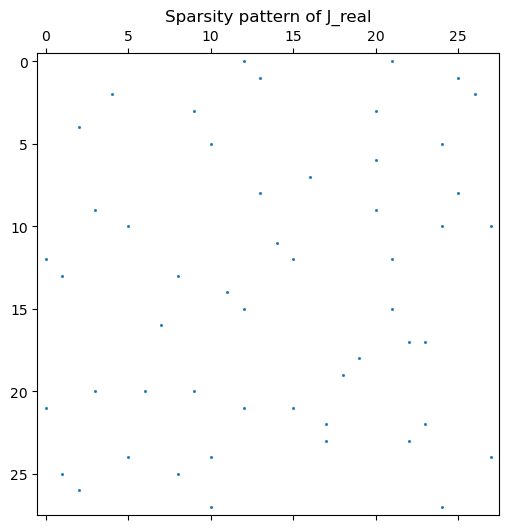

In [4]:
# ============================================================
# Cell 4 : Construct J_real
# ============================================================

# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def generate_weight(J_min, rng):
    """
    Generate a positive edge weight that is an integer
    multiple of J_min and at most 1.

    Returns a value in

        {J_min, 2 J_min, ..., 1}
    """

    max_multiple = int(round(1 / J_min))

    multiplier = rng.integers(1, max_multiple + 1)

    return multiplier * J_min


# ------------------------------------------------------------
# Nearest-neighbour graph
# ------------------------------------------------------------

def generate_nearest_J(N_nodes,
                       J_min):
    """
    Construct a single cycle:

        0 -> 1 -> 2 -> ... -> N-1 -> 0

    All edge weights are J_min.

    Intended primarily for debugging and the case s_J = 2.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    for i in range(N_nodes):

        j = (i + 1) % N_nodes

        J[i, j] = J_min
        J[j, i] = J_min

    return J.tocsr()


# ------------------------------------------------------------
# Random "almost regular" graph
# ------------------------------------------------------------

def generate_random_regular_J(N_nodes,
                              s_J,
                              J_min,
                              rng):
    """
    Randomly partition the nodes.

    Groups of size (s_J + 1):
        Construct complete graphs K_{s_J+1}
        with edge weights J_min.

    Remainder group:
        Construct a simple cycle.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = rng.permutation(N_nodes)

    group_size = s_J + 1

    n_full_groups = N_nodes // group_size

    remainder = N_nodes % group_size

    # --------------------------------------------------------
    # Full groups
    # --------------------------------------------------------

    start = 0

    for _ in range(n_full_groups):

        group = nodes[start:start + group_size]

        start += group_size

        # Complete graph
        for i in range(len(group)):

            for j in range(i + 1,
                           len(group)):

                u = group[i]
                v = group[j]

                J[u, v] = J_min
                J[v, u] = J_min

    # --------------------------------------------------------
    # Remainder group
    # --------------------------------------------------------

    if remainder >= 2:

        group = nodes[start:]

        for i in range(len(group)):

            u = group[i]

            v = group[(i + 1) % len(group)]

            J[u, v] = J_min
            J[v, u] = J_min

    elif remainder == 1:

        print(
            "Warning: One node in the remainder "
            "group has no real-network connections."
        )

    return J.tocsr()


# ------------------------------------------------------------
# Irregular graph
# ------------------------------------------------------------

def generate_irregular_J(N_nodes,
                         s_J,
                         J_min,
                         rng):
    """
    Construct a general irregular graph.

    Procedure:
    1. Partition the nodes into groups whose sizes
       are random integers between 2 and s_J + 1.
    2. Within each group, consider all pairings.
    3. Assign each pairing a weight chosen from

            {0, J_min, 2J_min, ..., 1}

    4. Repair isolated nodes by assigning one
       incident edge weight J_min.

    Guarantees:
        - symmetric,
        - zero diagonal,
        - J_ij >= J_min whenever J_ij > 0,
        - d_i >= J_min for every node.
    """

    J = sp.lil_matrix((N_nodes, N_nodes),
                      dtype=float)

    nodes = list(rng.permutation(N_nodes))

    groups = []

    # --------------------------------------------------------
    # Create random groups
    # --------------------------------------------------------

    while len(nodes) > 0:

        remaining = len(nodes)

        if remaining <= s_J + 1:

            group_size = remaining

        else:

            group_size = rng.integers(
                2,
                s_J + 2
            )

        group = nodes[:group_size]

        groups.append(group)

        nodes = nodes[group_size:]

    # --------------------------------------------------------
    # Populate each group
    # --------------------------------------------------------

    max_multiple = int(round(1 / J_min))

    for group in groups:

        m = len(group)

        if m == 1:
            continue

        # --------------------------------------------
        # Random pairings
        # --------------------------------------------

        for i in range(m):

            for j in range(i + 1,
                           m):

                u = group[i]
                v = group[j]

                multiplier = rng.integers(
                    0,
                    max_multiple + 1
                )

                weight = multiplier * J_min

                if weight > 0:

                    J[u, v] = weight
                    J[v, u] = weight

        # --------------------------------------------
        # Repair isolated nodes
        # --------------------------------------------

        for u in group:

            degree = J[u, :].sum()

            if degree == 0:

                candidates = [
                    v for v in group
                    if v != u
                ]

                if len(candidates) > 0:

                    v = rng.choice(candidates)

                    J[u, v] = J_min
                    J[v, u] = J_min

    return J.tocsr()


# ============================================================
# Construct J_real
# ============================================================

if graph_type == "nearest":

    J_real = generate_nearest_J(
        N_real,
        J_min
    )

elif graph_type == "random_regular":

    J_real = generate_random_regular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

elif graph_type == "irregular":

    J_real = generate_irregular_J(
        N_real,
        s_J,
        J_min,
        rng
    )

else:

    raise ValueError(
        f"Unknown graph type: {graph_type}"
    )


# ============================================================
# Diagnostics
# ============================================================

row_sparsities = np.diff(J_real.indptr)

weighted_degrees = np.array(
    J_real.sum(axis=1)
).flatten()

positive_entries = J_real.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_real != J_real.T).nnz == 0, \
    "J_real is not symmetric."

assert np.allclose(
    J_real.diagonal(),
    0
), "J_real has non-zero diagonal entries."

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Entries are not multiples of J_min."

assert np.all(
    row_sparsities <= s_J
), (
    "Actual sparsity exceeds specified s_J."
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_real Construction Summary")
print("=" * 70)

print(f"Graph type                          : "
      f"{graph_type}")

print(f"Number of real nodes                : "
      f"{N_real}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Specified sparsity of A (s)         : "
      f"{s}")

print()

print(f"Minimum actual row sparsity         : "
      f"{row_sparsities.min()}")

print(f"Maximum actual row sparsity         : "
      f"{row_sparsities.max()}")

print()

print(f"Minimum weighted degree d_min       : "
      f"{weighted_degrees.min():.4f}")

print(f"Maximum weighted degree d_max       : "
      f"{weighted_degrees.max():.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J_real.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J_real.nnz}")

print()

print(f"Minimum positive J_ij               : "
      f"{positive_entries.min():.4f}")

print(f"Maximum positive J_ij               : "
      f"{positive_entries.max():.4f}")

print("=" * 70)

# ============================================================
# First few rows of J_real
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J_real:")

for i in range(n_rows_to_show):

    row = J_real.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J_real, markersize=1)
plt.title("Sparsity pattern of J_real")
plt.show()

J_dummy Construction Summary
Number of dummy nodes              : 4

Dummy node indices                 : [28 29 30 31]

Number of undirected dummy edges   : 4
Number of non-zero dummy entries   : 8

Dummy row sparsity                 : 2
Dummy weighted degree              : 1.0000

Dummy edge weight                  : 0.5

First few rows of dummy_subgraph in J_dummy:

Global node 28:
    J[28,29] = 0.5
    J[28,31] = 0.5

Global node 29:
    J[29,28] = 0.5
    J[29,30] = 0.5

Global node 30:
    J[30,29] = 0.5
    J[30,31] = 0.5

Global node 31:
    J[31,28] = 0.5
    J[31,30] = 0.5


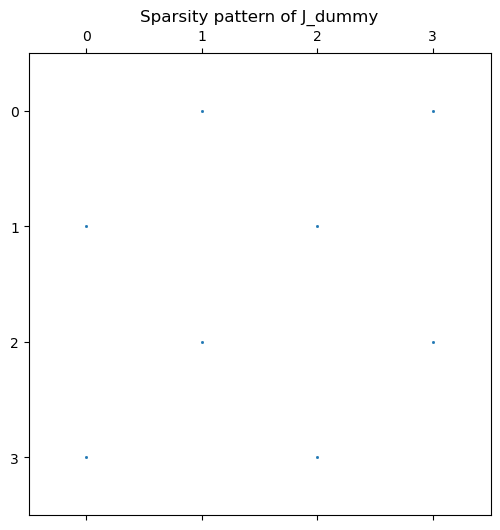

In [5]:
# ============================================================
# Cell 5 : Construct J_dummy
# ============================================================

J_dummy = sp.lil_matrix((N, N), dtype=float)

# ------------------------------------------------------------
# Construct the dummy cycle
# ------------------------------------------------------------

if N_dummy >= 2:

    for idx in range(N_dummy):

        u = dummy_nodes[idx]

        v = dummy_nodes[(idx + 1) % N_dummy]

        J_dummy[u, v] = J_min
        J_dummy[v, u] = J_min

elif N_dummy == 1:

    print(
        "Warning: Only one dummy node exists. "
        "No dummy edges created."
    )

else:

    print(
        "No dummy nodes specified."
    )

J_dummy = J_dummy.tocsr()


# ============================================================
# Diagnostics
# ============================================================

dummy_subgraph = J_dummy[dummy_nodes, :][:, dummy_nodes]

row_sparsities = np.diff(dummy_subgraph.indptr)

weighted_degrees = np.array(
    dummy_subgraph.sum(axis=1)
).flatten()

positive_entries = dummy_subgraph.data


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (J_dummy != J_dummy.T).nnz == 0, \
    "J_dummy is not symmetric."

assert np.allclose(
    J_dummy.diagonal(),
    0
), "J_dummy has non-zero diagonal entries."

# Ensure there are no real-dummy connections
assert J_dummy[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections found."

assert J_dummy[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections found."

if N_dummy >= 3:

    assert np.all(
        row_sparsities == 2
    ), "Dummy cycle does not have sparsity 2."

    assert np.allclose(
        weighted_degrees,
        2 * J_min
    ), (
        "Dummy weighted degrees are not equal "
        "to 2*J_min."
    )

if positive_entries.size > 0:

    assert np.allclose(
        positive_entries,
        J_min
    ), "Dummy edge weights are not equal to J_min."


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("J_dummy Construction Summary")
print("=" * 70)

print(f"Number of dummy nodes              : "
      f"{N_dummy}")

print()

print(f"Dummy node indices                 : "
      f"{dummy_nodes}")

print()

print(f"Number of undirected dummy edges   : "
      f"{dummy_subgraph.nnz // 2}")

print(f"Number of non-zero dummy entries   : "
      f"{dummy_subgraph.nnz}")

print()

if N_dummy >= 3:

    print(f"Dummy row sparsity                 : "
          f"{row_sparsities[0]}")

    print(f"Dummy weighted degree              : "
          f"{weighted_degrees[0]:.4f}")

print()

print(f"Dummy edge weight                  : "
      f"{J_min}")

print("=" * 70)

# ============================================================
# First few rows of J_dummy
# ============================================================

n_rows_to_show = min(dummy_subgraph.shape[0], 10)

print("\nFirst few rows of dummy_subgraph in J_dummy:")

for local_i in range(n_rows_to_show):

    global_i = dummy_nodes[local_i]

    row = dummy_subgraph.getrow(local_i)

    print(f"\nGlobal node {global_i}:")

    for local_j, val in zip(row.indices, row.data):

        global_j = dummy_nodes[local_j]

        print(
            f"    J[{global_i},{global_j}] = {val}"
        )


plt.figure(figsize=(6,6))
plt.spy(dummy_subgraph, markersize=1)
plt.title("Sparsity pattern of J_dummy")
plt.show()

Full Adjacency Matrix J Summary
Shape of J                          : (32, 32)

Number of real nodes                : 28
Number of dummy nodes               : 4

Specified s_J                       : 3
Maximum actual row sparsity         : 3

d_min                               : 0.5000
d_max                               : 3.0000

Specified J_min                     : 0.5000
Actual minimum positive J_ij        : 0.5000
Actual maximum positive J_ij        : 1.0000

Number of undirected edges          : 30
Number of non-zero entries          : 60

Number of connected components      : 10
Smallest component size             : 2
Largest component size              : 4

First few rows of J:

Row 0:
    J[0,12] = 1.0
    J[0,21] = 1.0

Row 1:
    J[1,13] = 1.0
    J[1,25] = 0.5

Row 2:
    J[2,4] = 1.0
    J[2,26] = 0.5

Row 3:
    J[3,9] = 0.5
    J[3,20] = 0.5

Row 4:
    J[4,2] = 1.0

Row 5:
    J[5,10] = 0.5
    J[5,24] = 1.0

Row 6:
    J[6,20] = 0.5

Row 7:
    J[7,16] = 0.5

Row 8:
 

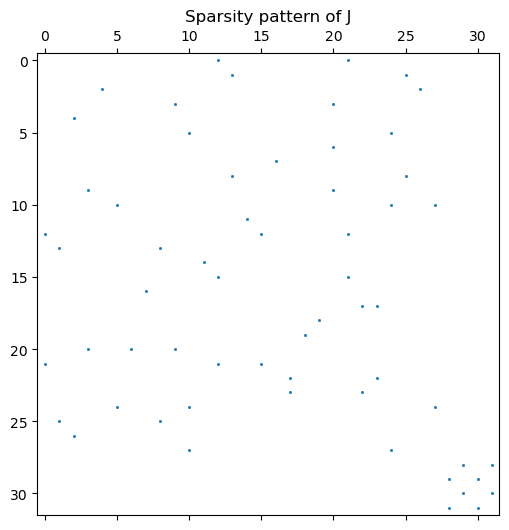

In [6]:
# ============================================================
# Cell 6 : Construct the full adjacency matrix J
# ============================================================

# ------------------------------------------------------------
# Embed J_real into an N x N matrix
# ------------------------------------------------------------

J_real_full = sp.lil_matrix((N, N), dtype=float)

J_real_full[:N_real, :N_real] = J_real

J_real_full = J_real_full.tocsr()

# ------------------------------------------------------------
# Assemble the full J matrix
# ------------------------------------------------------------

J = J_real_full + J_dummy

J = J.tocsr()

# ============================================================
# Diagnostics
# ============================================================

# ------------------------------------------------------------
# Basic structural properties
# ------------------------------------------------------------

assert J.shape == (N, N), \
    "J does not have shape (N, N)."

assert (J != J.T).nnz == 0, \
    "J is not symmetric."

assert np.allclose(
    J.diagonal(),
    0
), "J has non-zero diagonal entries."

# ------------------------------------------------------------
# Verify that real and dummy sectors are disconnected
# ------------------------------------------------------------

assert J[real_nodes, :][:, dummy_nodes].nnz == 0, \
    "Real-to-dummy connections detected."

assert J[dummy_nodes, :][:, real_nodes].nnz == 0, \
    "Dummy-to-real connections detected."

# ------------------------------------------------------------
# Sparsity diagnostics
# ------------------------------------------------------------

row_sparsities = np.diff(J.indptr)

max_row_sparsity = row_sparsities.max()

# ------------------------------------------------------------
# Weighted degree diagnostics
# ------------------------------------------------------------

weighted_degrees = np.array(
    J.sum(axis=1)
).flatten()

d_min = weighted_degrees.min()

d_max = weighted_degrees.max()

assert np.all(
    weighted_degrees > 0
), "Some nodes have zero weighted degree."

assert d_min >= J_min - 1e-12, \
    "d_min is smaller than J_min."

# ------------------------------------------------------------
# Edge-weight diagnostics
# ------------------------------------------------------------

positive_entries = J.data

assert np.all(
    positive_entries >= J_min
), "Some positive entries are smaller than J_min."

assert np.allclose(
    positive_entries / J_min,
    np.round(
        positive_entries / J_min
    )
), "Some edge weights are not multiples of J_min."

J_ij_min_actual = positive_entries.min()

J_ij_max_actual = positive_entries.max()

# ------------------------------------------------------------
# Connected component diagnostics
# ------------------------------------------------------------

n_components, component_labels = sp.csgraph.connected_components(
    J,
    directed=False
)

component_sizes = np.bincount(component_labels)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Full Adjacency Matrix J Summary")
print("=" * 70)

print(f"Shape of J                          : "
      f"{J.shape}")

print()

print(f"Number of real nodes                : "
      f"{N_real}")

print(f"Number of dummy nodes               : "
      f"{N_dummy}")

print()

print(f"Specified s_J                       : "
      f"{s_J}")

print(f"Maximum actual row sparsity         : "
      f"{max_row_sparsity}")

print()

print(f"d_min                               : "
      f"{d_min:.4f}")

print(f"d_max                               : "
      f"{d_max:.4f}")

print()

print(f"Specified J_min                     : "
      f"{J_min:.4f}")

print(f"Actual minimum positive J_ij        : "
      f"{J_ij_min_actual:.4f}")

print(f"Actual maximum positive J_ij        : "
      f"{J_ij_max_actual:.4f}")

print()

print(f"Number of undirected edges          : "
      f"{J.nnz // 2}")

print(f"Number of non-zero entries          : "
      f"{J.nnz}")

print()

print(f"Number of connected components      : "
      f"{n_components}")

print(f"Smallest component size             : "
      f"{component_sizes.min()}")

print(f"Largest component size              : "
      f"{component_sizes.max()}")

print("=" * 70)

# ============================================================
# First few rows of J
# ============================================================

n_rows_to_show = 10

print("\nFirst few rows of J:")

for i in range(n_rows_to_show):

    row = J.getrow(i)

    print(f"\nRow {i}:")

    for j, val in zip(row.indices, row.data):

        print(f"    J[{i},{j}] = {val}")


plt.figure(figsize=(6,6))
plt.spy(J, markersize=1)
plt.title("Sparsity pattern of J")
plt.show()

In [7]:
# ============================================================
# Cell 7 : Construct D, L, and A
# ============================================================

# ------------------------------------------------------------
# Degree vector and degree matrix
# ------------------------------------------------------------

degree_vector = np.array(
    J.sum(axis=1)
).flatten()

D = sp.diags(
    degree_vector,
    offsets=0,
    shape=(N, N),
    format='csr'
)

# ============================================================
# Construct the Laplacian
# ============================================================

if model == 1:

    # --------------------------------------------------------
    # Model 1:
    #
    #     L = D - J
    #
    # --------------------------------------------------------

    L = D - J

elif model == 2:

    # --------------------------------------------------------
    # Model 2:
    #
    #     L = I - D^{-1/2} J D^{-1/2}
    #
    # --------------------------------------------------------

    D_inv_sqrt = sp.diags(
        1 / np.sqrt(degree_vector),
        offsets=0,
        shape=(N, N),
        format='csr'
    )

    L = (
        sp.eye(N, format='csr')
        - D_inv_sqrt @ J @ D_inv_sqrt
    )

else:

    raise ValueError(
        f"Unknown model: {model}"
    )

# ============================================================
# Construct A
# ============================================================

A = (
    (1 - alpha) * sp.eye(N, format='csr')
    + alpha * L
)

A_DENSE = A.toarray()

A = A.tocsr()

# ============================================================
# Diagnostics
# ============================================================

A_row_sparsities = np.diff(A.indptr)

A_diagonal = A.diagonal()

off_diagonal = A - sp.diags(
    A_diagonal,
    format='csr'
)

positive_off_diagonal_entries = (
    off_diagonal.data[
        off_diagonal.data > 1e-12
    ]
)

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

assert (A != A.T).nnz == 0, \
    "A is not symmetric."

assert np.all(
    A_diagonal > 0
), "A does not have positive diagonal entries."

assert len(
    positive_off_diagonal_entries
) == 0, (
    "A has positive off-diagonal entries "
    "and is therefore not a Z-matrix."
)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Matrix Construction Summary")
print("=" * 70)

print(f"Model used                          : "
      f"{model}")

print()

print(f"Diffusion parameter alpha           : "
      f"{alpha:.4f}")

print()

print(f"Minimum degree d_min                : "
      f"{degree_vector.min():.4f}")

print(f"Maximum degree d_max                : "
      f"{degree_vector.max():.4f}")

print()

print(f"Maximum row sparsity of A           : "
      f"{A_row_sparsities.max()}")

print()

print(f"Minimum diagonal entry of A         : "
      f"{A_diagonal.min():.4f}")

print(f"Maximum diagonal entry of A         : "
      f"{A_diagonal.max():.4f}")

print()

print(f"Number of non-zero entries in A     : "
      f"{A.nnz}")

print()

print(f"A is symmetric                      : True")

print(f"A is a Z-matrix                     : True")

print("=" * 70)

Matrix Construction Summary
Model used                          : 2

Diffusion parameter alpha           : 0.5000

Minimum degree d_min                : 0.5000
Maximum degree d_max                : 3.0000

Maximum row sparsity of A           : 4

Minimum diagonal entry of A         : 1.0000
Maximum diagonal entry of A         : 1.0000

Number of non-zero entries in A     : 92

A is symmetric                      : True
A is a Z-matrix                     : True


In [8]:
# ============================================================
# Cell 8 : Spectral Diagnostics for A
# ============================================================

BLOCK_ENCODING_MARGIN = 1e-10

BOUND_VALIDATION_TOL = 1e-12
# (Used only when comparing exact theoretical bounds with numerically computed eigenvalues.)


# ------------------------------------------------------------
# Compute extremal eigenvalues
# ------------------------------------------------------------

print("Computing extremal eigenvalues of A...")

lambda_min = spla.eigsh(
    A,
    k=1,
    which='SA',
    return_eigenvectors=False
)[0]

lambda_max = spla.eigsh(
    A,
    k=1,
    which='LA',
    return_eigenvectors=False
)[0]

# ------------------------------------------------------------
# Exact condition number
# ------------------------------------------------------------

kappa_exact = lambda_max / lambda_min


# ============================================================
# Model-specific theoretical bounds
# ============================================================

if model == 1:

    #
    # A = (1-alpha)I + alpha(D - J)
    #
    # lambda_min >= 1 - alpha
    #
    # lambda_max <= (1-alpha) + 2 alpha d_max
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = (
        (1 - alpha)
        + 2 * alpha * d_max
    )

    row_sum_bound = 2*(s - 1)

elif model == 2:

    #
    # A = (1-alpha)I
    #   + alpha(I - D^{-1/2} J D^{-1/2})
    #
    # spectrum(A) subseteq [1-alpha, 1+alpha]
    #

    lambda_min_bound = 1 - alpha

    lambda_max_bound = 1 + alpha

    row_sum_bound = s

else:

    raise ValueError(
        f"Unknown model: {model}"
    )


# ------------------------------------------------------------
# Theoretical condition number bound
# ------------------------------------------------------------

kappa_bound = (
    lambda_max_bound
    / lambda_min_bound
)


# ============================================================
# Positive definiteness diagnostics
# ============================================================

is_positive_definite = (
    lambda_min > 0
)

assert is_positive_definite, \
    (
        "A is not positive definite.\n"
        f"lambda_min = {lambda_min:.12f}"
    )


# ============================================================
# Validate theoretical bounds
# ============================================================

lower_bound_valid = (
    lambda_min >=
    lambda_min_bound - BOUND_VALIDATION_TOL
)

upper_bound_valid = (
    lambda_max <=
    lambda_max_bound + BOUND_VALIDATION_TOL
)

assert lower_bound_valid, \
    (
        "Theoretical lower bound violated.\n"
        f"lambda_min = {lambda_min:.12f}\n"
        f"lambda_min_bound = "
        f"{lambda_min_bound:.12f}"
    )

assert upper_bound_valid, \
    (
        "Theoretical upper bound violated.\n"
        f"lambda_max = {lambda_max:.12f}\n"
        f"lambda_max_bound = "
        f"{lambda_max_bound:.12f}"
    )


# ============================================================
# Block-encoding scaling factor
# ============================================================

# Note that alpha_A must ensure two things.
#
# 1. ||A / alpha_A||_2 <= 1,
#    so that the matrix is block-encodable.
#
# 2. For every row i,
#
#       sum_j |A_ij| / alpha_A <= 1,
#
#    so that the PREPARE amplitudes
#
#       sqrt(|A_ij| / alpha_A)
#
#    form a valid subnormalized state.
#    The remaining probability mass is assigned
#    to the |fail> state.

alpha_A = (
    max(
        lambda_max_bound,
        row_sum_bound
    )
    /
    (1 - BLOCK_ENCODING_MARGIN)
)

# ============================================================
# Encodability diagnostics
# ============================================================

scaled_lambda_min = (
    lambda_min / alpha_A
)

scaled_lambda_max = (
    lambda_max / alpha_A
)

all_eigenvalues_encodable = (
    scaled_lambda_max <= 1
)

assert all_eigenvalues_encodable, \
    (
        "Eigenvalues are not block-encodable.\n"
        f"lambda_max / alpha_A = "
        f"{scaled_lambda_max:.12f}"
    )

assert scaled_lambda_min > 0, \
    (
        "Scaled eigenvalues are not positive.\n"
        f"lambda_min / alpha_A = "
        f"{scaled_lambda_min:.12f}"
    )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Spectral Diagnostics")
print("=" * 70)

print(f"Exact lambda_min                   : "
      f"{lambda_min:.8f}")

print(f"Exact lambda_max                   : "
      f"{lambda_max:.8f}")

print()

print(f"Exact condition number             : "
      f"{kappa_exact:.8f}")

print()

print(f"Theoretical lambda_min bound       : "
      f"{lambda_min_bound:.8f}")

print(f"Theoretical lambda_max bound       : "
      f"{lambda_max_bound:.8f}")

print()

print(f"Theoretical condition number bound : "
      f"{kappa_bound:.8f}")

print()

print(f"Row-sum bound                      : "
      f"{row_sum_bound:.8f}")

print()

print(f"Block-encoding margin              : "
      f"{BLOCK_ENCODING_MARGIN:.2e}")

print(f"Block-encoding scaling alpha_A     : "
      f"{alpha_A:.8f}")

print()

print(f"lambda_min / alpha_A               : "
      f"{scaled_lambda_min:.8f}")

print(f"lambda_max / alpha_A               : "
      f"{scaled_lambda_max:.8f}")

print(f"alpha_A / lambda_max               : "
      f"{alpha_A / lambda_max:.8f}")

print()

print(f"A is positive definite             : "
      f"{is_positive_definite}")

print(f"Lower bound validated              : "
      f"{lower_bound_valid}")

print(f"Upper bound validated              : "
      f"{upper_bound_valid}")

print(f"All eigenvalues encodable          : "
      f"{all_eigenvalues_encodable}")

print("=" * 70)

Computing extremal eigenvalues of A...

Spectral Diagnostics
Exact lambda_min                   : 0.50000000
Exact lambda_max                   : 1.50000000

Exact condition number             : 3.00000000

Theoretical lambda_min bound       : 0.50000000
Theoretical lambda_max bound       : 1.50000000

Theoretical condition number bound : 3.00000000

Row-sum bound                      : 4.00000000

Block-encoding margin              : 1.00e-10
Block-encoding scaling alpha_A     : 4.00000000

lambda_min / alpha_A               : 0.12500000
lambda_max / alpha_A               : 0.37500000
alpha_A / lambda_max               : 2.66666667

A is positive definite             : True
Lower bound validated              : True
Upper bound validated              : True
All eigenvalues encodable          : True


In [9]:
# ==================================================================
# Cell 9A : Construct the Augmented Graph G_tilde
# ==================================================================

#
# Berry–Childs requires every vertex of the
# off-diagonal sparsity graph to have identical
# degree.
#
# We therefore augment the original graph by
# adding symmetric zero-weight edges until every
# vertex has degree
#
#     s - 1.
#
# The diagonal entries are excluded from this
# graph and will later receive the dedicated
# color
#
#     ell = 0.
#

# ============================================================
# Build adjacency lists
# ============================================================

ADJ = [
    set()
    for _ in range(N)
]

#
# Weight matrix for the augmented graph.
#

AUGMENTED_WEIGHTS = np.zeros(
    (N, N),
    dtype=float
)

for j in range(N):

    for row in range(j + 1, N):

        value = A_DENSE[row, j]

        if value != 0:

            ADJ[j].add(row)
            ADJ[row].add(j)

            AUGMENTED_WEIGHTS[j, row] = value
            AUGMENTED_WEIGHTS[row, j] = value


# ============================================================
# Original graph statistics
# ============================================================

degrees = np.array(

    [len(neighbors) for neighbors in ADJ]

)

Delta = int(np.max(degrees))

assert Delta <= (s - 1), (
    "Observed off-diagonal degree exceeds "
    "specified sparsity."
)

# ============================================================
# Regularize the graph
# ============================================================

#
# deficiency(v)
#
# equals the number of additional
# zero-weight edges still required.
#

deficiency = (

    (s - 1)

    - degrees

).astype(int)

while np.any(deficiency > 0):

    #
    # Smallest deficient vertex.
    #

    u = int(

        np.where(
            deficiency > 0
        )[0][0]

    )

    connected = False

    #
    # Scan vertices deterministically.
    #

    for v in range(u + 1, N):

        if deficiency[v] == 0:

            continue

        if v in ADJ[u]:

            continue

        #
        # Add zero-weight edge.
        #

        ADJ[u].add(v)
        ADJ[v].add(u)

        AUGMENTED_WEIGHTS[u, v] = 0.0
        AUGMENTED_WEIGHTS[v, u] = 0.0

        deficiency[u] -= 1
        deficiency[v] -= 1

        connected = True

        #
        # If u is now saturated,
        # move to the next deficient
        # vertex.
        #

        if deficiency[u] == 0:

            break

    if not connected:

        raise RuntimeError(
            "Unable to regularize the graph.\n"
            "No legal augmentation edge exists."
        )


# ============================================================
# Final statistics
# ============================================================

degrees_tilde = np.array(

    [len(neighbors) for neighbors in ADJ]

)

regular = np.all(
    degrees_tilde == (s - 1)
)

assert regular

original_edges = int(

    np.sum(degrees)

    // 2

)

augmented_edges = int(

    np.sum(degrees_tilde)

    // 2

)

padding_edges = (

    augmented_edges

    - original_edges

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Graph Regularization")
print("=" * 70)

print(f"Number of vertices               : {N}")

print()

print(f"Original graph edges, |E(G)|        : {original_edges}")

print(f"Zero-weight padding added           : {padding_edges}")

print(f"Augmented graph edges, |E(G_tilde)| : {augmented_edges}")

print()

print(f"Maximum original degree          : {Delta}")

print(f"Target degree                    : {s-1}")

print()

print(f"Regularization successful        : {regular}")

print()

print("First few vertex degrees:")

for j in range(min(10, N)):

    print(
        f"    Vertex {j:2d} : "
        f"{degrees_tilde[j]}"
    )

print()

print("=" * 70)

Berry–Childs Graph Regularization
Number of vertices               : 32

Original graph edges, |E(G)|        : 30
Zero-weight padding added           : 18
Augmented graph edges, |E(G_tilde)| : 48

Maximum original degree          : 3
Target degree                    : 3

Regularization successful        : True

First few vertex degrees:
    Vertex  0 : 3
    Vertex  1 : 3
    Vertex  2 : 3
    Vertex  3 : 3
    Vertex  4 : 3
    Vertex  5 : 3
    Vertex  6 : 3
    Vertex  7 : 3
    Vertex  8 : 3
    Vertex  9 : 3



In [10]:
# ==================================================================
# Cell 9B : Edge Coloring of the Augmented Graph
# ==================================================================

#
# We compute a proper edge coloring of
#
#     G_tilde.
#
# Each color corresponds to one Berry–Childs
# sparsity index
#
#     ell = 1, ..., chi_prime.
#
# The diagonal entries are reserved for
#
#     ell = 0.
#

# ============================================================
# List the edges
# ============================================================

EDGE_LIST = []

for u in range(N):

    for v in sorted(ADJ[u]):

        if u < v:

            EDGE_LIST.append((u, v))

NUM_EDGES = len(EDGE_LIST)

# ============================================================
# Edge-coloring by backtracking
# ============================================================

EDGE_COLOR = {}

#
# Maximum possible colors by Vizing.
#

MAX_COLORS = Delta + 1

#
# Try Delta colors first.
#

def edge_coloring_backtracking(num_colors):

    EDGE_COLOR.clear()

    def recursive(edge_index):

        if edge_index == NUM_EDGES:

            return True

        u, v = EDGE_LIST[edge_index]

        #
        # Colors already used at u or v.
        #

        forbidden = set()

        for (a, b), c in EDGE_COLOR.items():

            if (

                a == u or b == u
                or
                a == v or b == v

            ):

                forbidden.add(c)

        #
        # Try available colors.
        #

        for color in range(1, num_colors + 1):

            if color in forbidden:

                continue

            EDGE_COLOR[(u, v)] = color

            if recursive(edge_index + 1):

                return True

            del EDGE_COLOR[(u, v)]

        return False

    return recursive(0)


#
# First attempt:
#
#     chi' = Delta.
#

FOUND = edge_coloring_backtracking(Delta)

if FOUND:

    chi_prime = Delta

else:

    FOUND = edge_coloring_backtracking(Delta + 1)

    assert FOUND

    chi_prime = Delta + 1

# ============================================================
# Verify proper coloring
# ============================================================

proper_coloring = True

for (u1, v1), c1 in EDGE_COLOR.items():

    for (u2, v2), c2 in EDGE_COLOR.items():

        if (u1, v1) == (u2, v2):

            continue

        if c1 != c2:

            continue

        #
        # Same color cannot touch.
        #

        if len({u1, v1, u2, v2}) < 4:

            proper_coloring = False

assert proper_coloring

# ============================================================
# Prepare-register size
# ============================================================

#
# Reserve
#
#     ell = 0
#
# for the diagonal.
#

s_prepare = chi_prime + 1

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Edge Coloring")
print("=" * 70)

print(f"Maximum degree Delta             : {Delta}")

print(f"Edge chromatic number            : {chi_prime}")

print()

print(f"Berry–Childs colors              : {chi_prime}")

print(f"Diagonal color                   : 0")

print(f"Prepare basis states             : {s_prepare}")

print()

print(f"Proper coloring                  : {proper_coloring}")

print()

print("First few colored edges:")

for edge in EDGE_LIST[:20]:

    print(

        f"    {edge}  -->  "

        f"ell = {EDGE_COLOR[edge]}"

    )

print()

print("=" * 70)

Berry–Childs Edge Coloring
Maximum degree Delta             : 3
Edge chromatic number            : 3

Berry–Childs colors              : 3
Diagonal color                   : 0
Prepare basis states             : 4

Proper coloring                  : True

First few colored edges:
    (0, 1)  -->  ell = 1
    (0, 12)  -->  ell = 2
    (0, 21)  -->  ell = 3
    (1, 13)  -->  ell = 2
    (1, 25)  -->  ell = 3
    (2, 3)  -->  ell = 1
    (2, 4)  -->  ell = 3
    (2, 26)  -->  ell = 2
    (3, 9)  -->  ell = 3
    (3, 20)  -->  ell = 2
    (4, 5)  -->  ell = 1
    (4, 6)  -->  ell = 2
    (5, 10)  -->  ell = 2
    (5, 24)  -->  ell = 3
    (6, 7)  -->  ell = 1
    (6, 20)  -->  ell = 3
    (7, 8)  -->  ell = 2
    (7, 16)  -->  ell = 3
    (8, 13)  -->  ell = 3
    (8, 25)  -->  ell = 1



In [11]:
# ==================================================================
# Cell 9C : Construct Berry–Childs Sparse Oracle Tables
# ==================================================================

#
# We now construct the sparse oracle tables
#
#     O_F(j, ell)
#
# and
#
#     O_A(j, ell)
#
# directly from the edge-colored augmented
# graph.
#
# Convention:
#
#     ell = 0
#
# is reserved for the diagonal.
#
# Edge colors
#
#     1,...,chi_prime
#
# correspond to the off-diagonal colors
# obtained in Cell 9B.
#

# ============================================================
# Allocate oracle tables
# ============================================================

A_positions_padded = np.zeros(
    (N, s_prepare),
    dtype=int
)

A_values_padded = np.zeros(
    (N, s_prepare),
    dtype=float
)

# ============================================================
# Diagonal entries
# ============================================================

for j in range(N):

    A_positions_padded[j, 0] = j

    A_values_padded[j, 0] = A_DENSE[j, j]

# ============================================================
# Off-diagonal entries
# ============================================================

for (u, v), color in EDGE_COLOR.items():

    #
    # Column u
    #

    A_positions_padded[u, color] = v

    A_values_padded[u, color] = AUGMENTED_WEIGHTS[v, u]

    #
    # Column v
    #

    A_positions_padded[v, color] = u

    A_values_padded[v, color] = AUGMENTED_WEIGHTS[u, v]

# ============================================================
# Verify symmetry of oracle tables
# ============================================================

oracle_symmetry = True

for (u, v), color in EDGE_COLOR.items():

    if A_positions_padded[u, color] != v:

        oracle_symmetry = False

    if A_positions_padded[v, color] != u:

        oracle_symmetry = False

assert oracle_symmetry

# ============================================================
# Verify consistency with A
# ============================================================

for j in range(N):

    #
    # Diagonal
    #

    assert np.isclose(

        A_values_padded[j, 0],

        A_DENSE[j, j]

    )

    #
    # Off-diagonal
    #

    for ell in range(1, s_prepare):

        row = A_positions_padded[j, ell]

        value = A_values_padded[j, ell]

        actual = A_DENSE[row, j]

        assert np.isclose(

            value,

            actual

        )

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Sparse Oracle Tables")
print("=" * 70)

print()

print(f"Table shape                     : {A_positions_padded.shape}")

print(f"Diagonal color                  : 0")

print(f"Edge colors                     : 1 ... {chi_prime}")

print()

print(f"Oracle symmetry verified        : {oracle_symmetry}")

print()

print("First few columns:")

for j in range(min(5, N)):

    print()

    print(f"Column {j}:")

    for ell in range(s_prepare):

        row = A_positions_padded[j, ell]

        value = A_values_padded[j, ell]

        print(

            f"    ell = {ell}: "

            f"row = {row:2d}, "

            f"value = {value:+.6f}"

        )

print()

print("=" * 70)

Berry–Childs Sparse Oracle Tables

Table shape                     : (32, 4)
Diagonal color                  : 0
Edge colors                     : 1 ... 3

Oracle symmetry verified        : True

First few columns:

Column 0:
    ell = 0: row =  0, value = +1.000000
    ell = 1: row =  1, value = +0.000000
    ell = 2: row = 12, value = -0.223607
    ell = 3: row = 21, value = -0.223607

Column 1:
    ell = 0: row =  1, value = +1.000000
    ell = 1: row =  0, value = +0.000000
    ell = 2: row = 13, value = -0.333333
    ell = 3: row = 25, value = -0.204124

Column 2:
    ell = 0: row =  2, value = +1.000000
    ell = 1: row =  3, value = +0.000000
    ell = 2: row = 26, value = -0.288675
    ell = 3: row =  4, value = -0.408248

Column 3:
    ell = 0: row =  3, value = +1.000000
    ell = 1: row =  2, value = +0.000000
    ell = 2: row = 20, value = -0.204124
    ell = 3: row =  9, value = -0.250000

Column 4:
    ell = 0: row =  4, value = +1.000000
    ell = 1: row =  5, value = +0

In [12]:
"""
#Optional Debugging

count = 0

for j in range(N):

    for ell in range(s_prepare):

        r = A_positions_padded[j, ell]

        if r == j:
            continue

        ell_back = np.where(
            A_positions_padded[r] == j
        )[0]

        if len(ell_back) != 1:

            print(j, r)

        else:

            if ell_back[0] != ell:

                print(
                    "Mismatch",
                    j,
                    r,
                    ell,
                    ell_back[0]
                )

                count += 1

print(count)
"""
;

''

In [13]:
# ============================================================
# Cell 10 : Classical Sparse Oracles O_F and O_A
# ============================================================

# ------------------------------------------------------------
# Position oracle:
#
#     O_F(j, ell) = f(j, ell)
#
# Given
#
#     system index j
#
# and
#
#     sparsity index ell,
#
# returns the row index
#
#    f(j, ell),
#
# where
#
#    ell = 0
#
# corresponds to the diagonal entry
#
#    A_{j,j},
#
# and
#
#    ell = 1,...,chi_prime
#
# correspond to the globally edge-colored
# off-diagonal entries of the augmented
# Berry–Childs graph.
# ------------------------------------------------------------

def O_F(j, ell):

    assert 0 <= j < N, \
        f"Column index j = {j} is out of range."

    assert 0 <= ell < s_prepare, \
        f"Sparsity index ell = {ell} is out of range."

    return int(
        A_positions_padded[j, ell]
    )


# ------------------------------------------------------------
# Value oracle:
#
#     O_A(j, ell)
#
# Returns
#
#     A_{f(j, ell), j}.
#
# where zero-valued padding edges in the
# augmented graph naturally return 0.
# ------------------------------------------------------------

def O_A(j, ell):

    assert 0 <= j < N, \
        f"Column index j = {j} is out of range."

    assert 0 <= ell < s_prepare, \
        f"Sparsity index ell = {ell} is out of range."

    return float(
        A_values_padded[j, ell]
    )


# ============================================================
# Exhaustive verification
# ============================================================

for j in range(N):

    for ell in range(s_prepare):

        row = O_F(j, ell)

        oracle_value = O_A(j, ell)

        actual_value = A_DENSE[row, j]

        assert np.isclose(
            oracle_value,
            actual_value
        ), (
            f"Oracle mismatch.\n"
            f"Column = {j}\n"
            f"ell = {ell}\n"
            f"O_F(j, ell) = {row}\n"
            f"O_A(j, ell) = {oracle_value}\n"
            f"A[row, j] = {actual_value}"
        )

# ------------------------------------------------------------
# Berry–Childs symmetry check
# ------------------------------------------------------------

for (u, v), color in EDGE_COLOR.items():

    assert O_F(u, color) == v
    assert O_F(v, color) == u


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Classical Sparse Oracle Verification")
print("=" * 70)

print(
    "Position oracle O_F verified "
    f"for all {N*s_prepare} entries."
)

print(
    "Value oracle O_A verified "
    f"for all {N*s_prepare} entries."
)

print()

print("Example queries:")

n_columns_to_show = min(5, N)

for j in range(n_columns_to_show):

    print(f"\nColumn {j}:")

    for ell in range(s_prepare):

        row = O_F(j, ell)

        val = O_A(j, ell)

        label = (
            "diag (ell = 0)"
            if ell == 0
            else f"color (ell) = {ell}"
        )
        
        print(
            f"    {label:8s}: "
            f"row = {row:2d}, "
            f"value = {val:+.6f}"
        )

print()

print("=" * 70)

Classical Sparse Oracle Verification
Position oracle O_F verified for all 128 entries.
Value oracle O_A verified for all 128 entries.

Example queries:

Column 0:
    diag (ell = 0): row =  0, value = +1.000000
    color (ell) = 1: row =  1, value = +0.000000
    color (ell) = 2: row = 12, value = -0.223607
    color (ell) = 3: row = 21, value = -0.223607

Column 1:
    diag (ell = 0): row =  1, value = +1.000000
    color (ell) = 1: row =  0, value = +0.000000
    color (ell) = 2: row = 13, value = -0.333333
    color (ell) = 3: row = 25, value = -0.204124

Column 2:
    diag (ell = 0): row =  2, value = +1.000000
    color (ell) = 1: row =  3, value = +0.000000
    color (ell) = 2: row = 26, value = -0.288675
    color (ell) = 3: row =  4, value = -0.408248

Column 3:
    diag (ell = 0): row =  3, value = +1.000000
    color (ell) = 1: row =  2, value = +0.000000
    color (ell) = 2: row = 20, value = -0.204124
    color (ell) = 3: row =  9, value = -0.250000

Column 4:
    diag (ell

In [14]:
# ============================================================
# Cell 11 : Berry–Childs Oracle Register Specifications
# ============================================================

#
# Notebook register convention
# (Berry–Childs specialization):
#
#     |prepare>|row>|system>
#
# prepare
#
#     stores the sparsity index
#
#         ell.
#
#     where
# 
#         ell = 0
#
#     labels the diagonal entries and
# 
#         ell = 1,...,chi_prime
# 
#     label the globally edge-colored
#     off-diagonal entries of the augmented
#     graph.
#
# row
#
#     stores
#
#         f(j, ell),
#
#     the row index of the ell-th stored
#     nonzero entry of column j.
#
# system
#
#     stores the column index
#
#         j.
#
# The sparse oracles are defined with
# respect to the augmented edge-colored
# graph G_tilde:
#
#     O_F(j, ell)
#
# returning
#
#     f(j, ell),
#
# and
#
#     O_A(j, ell)
#
# returning
#
#     A_{f(j, ell), j}.
#
# The precision analysis below determines
# the logical register sizes required to
# implement O_F and O_A using a
# future QROM implementation.
#

# ------------------------------------------------------------
# Upper bound on d_max
# ------------------------------------------------------------

#
# Since
#
#     J_ij <= 1,
#
# and each node has at most s_J neighbors,
#
# we have
#
#     d_max <= s_J.
#
# This bound depends only on the problem
# specification and NOT on the realized graph.
#

d_max_possible = s_J

#
# Actual Berry–Childs parameters.
#

Delta_actual = Delta
chi_prime_actual = chi_prime


# ============================================================
# Model-1 precision requirements
# ============================================================

#
# For Model 1:
#
#     |A_ij| = alpha J_ij
#
# Therefore,
#
#     |A_ij|
#
#     >= ALPHA_THRESHOLD J_MIN_THRESHOLD.
#

A_min_possible_model_1 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
)

#
# Since
#
#     A_ii
#
#     = 1 - alpha + alpha d_i
#
# and
#
#     d_i <= d_max_possible,
#
# we obtain
#
#     A_ii <= 1 + d_max_possible.
#

A_max_possible_model_1 = (
    1
    + d_max_possible
)


# ============================================================
# Model-2 precision requirements
# ============================================================

#
# For Model 2:
#
#     |A_ij|
#
#     = alpha J_ij
#
#       / sqrt(d_i d_j)
#
# Since
#
#     sqrt(d_i d_j)
#
#     <= d_max_possible,
#
# we obtain
#
#     |A_ij|
#
#     >=
#
#     ALPHA_THRESHOLD
#
#     * J_MIN_THRESHOLD
#
#     / d_max_possible.
#

A_min_possible_model_2 = (
    ALPHA_THRESHOLD
    * J_MIN_THRESHOLD
    / d_max_possible
)

#
# Diagonal entries are exactly 1.
#

A_max_possible_model_2 = 1.0


# ============================================================
# Model-agnostic precision requirements
# ============================================================

#
# We construct ONE oracle architecture that
# works for BOTH models.
#
# Therefore, we first determine the largest
# possible matrix entry magnitude among all
# models under consideration.
#

A_max_possible = max(
    A_max_possible_model_1,
    A_max_possible_model_2
)


#
# Require
#
#     A_max_possible / 2^b
#
# to be strictly smaller than the smallest
# representable nonzero entry in each model.
#

ratio_model_1 = (
    A_max_possible
    / A_min_possible_model_1
)

ratio_model_2 = (
    A_max_possible
    / A_min_possible_model_2
)


#
# Add one extra bit to guarantee the strict
# inequality.
#

VALUE_PRECISION_BITS_MODEL_1 = int(
    np.ceil(
        np.log2(ratio_model_1)
    )
) + 1

VALUE_PRECISION_BITS_MODEL_2 = int(
    np.ceil(
        np.log2(ratio_model_2)
    )
) + 1


#
# Model-agnostic value precision.
#

VALUE_PRECISION_BITS = max(
    VALUE_PRECISION_BITS_MODEL_1,
    VALUE_PRECISION_BITS_MODEL_2
)


VALUE_RESOLUTION = (
    A_max_possible
    /
    (2 ** VALUE_PRECISION_BITS)
)


# ------------------------------------------------------------
# Verify that the chosen precision is sufficient
# ------------------------------------------------------------

assert VALUE_RESOLUTION < A_min_possible_model_1, \
    (
        "Value register precision is insufficient "
        "for Model 1.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_1 = "
        f"{A_min_possible_model_1:.12e}"
    )

assert VALUE_RESOLUTION < A_min_possible_model_2, \
    (
        "Value register precision is insufficient "
        "for Model 2.\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}\n"
        f"A_min_possible_model_2 = "
        f"{A_min_possible_model_2:.12e}"
    )


# ============================================================
# Determine actual realized A diagnostics
# ============================================================

A_nonzero_values = A_DENSE[
    np.nonzero(A_DENSE)
]

A_nonzero_magnitudes = np.abs(
    A_nonzero_values[
        np.abs(A_nonzero_values) > 0
    ]
)

A_min_actual = (
    A_nonzero_magnitudes.min()
)

A_max_actual = (
    A_nonzero_magnitudes.max()
)

actual_entries_resolvable = (
    A_min_actual
    > VALUE_RESOLUTION
)

assert actual_entries_resolvable, \
    (
        "The realized matrix A contains "
        "entries below the chosen value "
        "resolution.\n"
        f"A_min_actual = "
        f"{A_min_actual:.12e}\n"
        f"Resolution = "
        f"{VALUE_RESOLUTION:.12e}"
    )


# ============================================================
# Register sizes
# ============================================================

#
# Internally, the sparse oracles use the
# following logical registers:
#
#     index     <-> system
#     sparsity  <-> prepare
#     position  <-> row
#

#
# Index register
#

n_index = n


#
# Sparsity register
#

n_sparsity = int(
    np.ceil(
        np.log2(s_prepare)
    )
)


#
# Position register
#

n_position = n


#
# Sign qubit
#

n_sign = 1


#
# Value register
#

n_value = (
    VALUE_PRECISION_BITS
    + n_sign
)


# ============================================================
# Oracle logical qubit counts
# ============================================================

n_qubits_O_F = (
    n_index
    + n_sparsity
    + n_position
)

n_qubits_O_A = (
    n_index
    + n_sparsity
    + n_value
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Oracle Register Specifications")
print("=" * 70)

print(f"ALPHA_THRESHOLD                   : "
      f"{ALPHA_THRESHOLD:.2e}")

print(f"J_MIN_THRESHOLD                   : "
      f"{J_MIN_THRESHOLD:.2e}")

print()

print(f"d_max_possible                    : "
      f"{d_max_possible}")

print()

print(f"Model-1 A_min_possible            : "
      f"{A_min_possible_model_1:.12e}")

print(f"Model-1 A_max_possible            : "
      f"{A_max_possible_model_1:.12e}")

print(f"Model-1 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_1}")

print()

print(f"Model-2 A_min_possible            : "
      f"{A_min_possible_model_2:.12e}")

print(f"Model-2 A_max_possible            : "
      f"{A_max_possible_model_2:.12e}")

print(f"Model-2 precision bits            : "
      f"{VALUE_PRECISION_BITS_MODEL_2}")

print()

print(f"Model-agnostic A_max_possible     : "
      f"{A_max_possible:.12e}")

print(f"Model-agnostic precision bits     : "
      f"{VALUE_PRECISION_BITS}")

print(f"Model-agnostic resolution         : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print(f"Actual A_min                      : "
      f"{A_min_actual:.12e}")

print(f"Actual A_max                      : "
      f"{A_max_actual:.12e}")

print()

print(f"Actual entries resolvable         : "
      f"{actual_entries_resolvable}")

print()

print(f"Index register qubits             : "
      f"{n_index}")

print(f"Sparsity register qubits          : "
      f"{n_sparsity}")

print(f"Position register qubits          : "
      f"{n_position}")

print(f"Value register qubits             : "
      f"{n_value}")

print()

print(f"O_F logical qubits                : "
      f"{n_qubits_O_F}")

print(f"O_A logical qubits                : "
      f"{n_qubits_O_A}")

print()

print("Ancilla qubits required for")
print("QROM implementation are not")
print("included in these counts.")

print()

print(f"Actual maximum degree             : "
      f"{Delta_actual}")

print(f"Actual edge chromatic number      : "
      f"{chi_prime_actual}")

print(f"Prepare basis states              : "
      f"{s_prepare}")

print()

print("=" * 70)

Oracle Register Specifications
ALPHA_THRESHOLD                   : 5.00e-02
J_MIN_THRESHOLD                   : 2.50e-01

d_max_possible                    : 3

Model-1 A_min_possible            : 1.250000000000e-02
Model-1 A_max_possible            : 4.000000000000e+00
Model-1 precision bits            : 10

Model-2 A_min_possible            : 4.166666666667e-03
Model-2 A_max_possible            : 1.000000000000e+00
Model-2 precision bits            : 11

Model-agnostic A_max_possible     : 4.000000000000e+00
Model-agnostic precision bits     : 11
Model-agnostic resolution         : 1.953125000000e-03

Actual A_min                      : 1.000000000000e-01
Actual A_max                      : 1.000000000000e+00

Actual entries resolvable         : True

Index register qubits             : 5
Sparsity register qubits          : 2
Position register qubits          : 5
Value register qubits             : 12

O_F logical qubits                : 12
O_A logical qubits                : 19

Anc

In [15]:
# ============================================================
# Cell 12 : QROM Data Preparation
# ============================================================

#
# These tables are classical data structures.
#
# They are not quantum circuits.
#
# A future QROM implementation of O_F
# and O_A will read from these tables
# coherently.
#

# ------------------------------------------------------------
# Flatten O_F lookup table
# ------------------------------------------------------------

#
# Address convention:
#
#     address = j * s_prepare + ell
#
# where
#
#     j    = system (column) index,
#     ell  = (sparsity index / Berry–Childs color index / prepare-register index).
#
# The address uniquely specifies
#
#     (j, ell)
#
# corresponding to the matrix entry
#
#     A_{f(j, ell), j}.
#

num_addresses = N * s_prepare

O_F_table = np.zeros(
    num_addresses,
    dtype=int
)

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        O_F_table[address] = (
            A_positions_padded[j, ell]
        )


# ------------------------------------------------------------
# Flatten O_A lookup table
# ------------------------------------------------------------

#
# We encode values using
#
#     sign bit
#
# together with a fixed-point magnitude.
#

O_A_sign_table = np.zeros(
    num_addresses,
    dtype=int
)

O_A_magnitude_table = np.zeros(
    num_addresses,
    dtype=int
)

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        value = (
            A_values_padded[j, ell]
        )

        #
        # Sign bit
        #
        #     0 -> positive
        #     1 -> negative
        #

        if value < 0:

            O_A_sign_table[address] = 1

        else:

            O_A_sign_table[address] = 0

        #
        # Fixed-point magnitude
        #

        magnitude = abs(value)

        encoded_magnitude = int(
            np.round(
                magnitude
                / VALUE_RESOLUTION
            )
        )

        O_A_magnitude_table[address] = (
            encoded_magnitude
        )


# ============================================================
# Verify fixed-point encoding
# ============================================================

maximum_encoding_error = 0.0

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        original_value = (
            A_values_padded[j, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        maximum_encoding_error = max(
            maximum_encoding_error,
            encoding_error
        )

        assert (
            encoding_error
            <= VALUE_RESOLUTION
        ), (
            f"Fixed-point encoding error too large.\n"
            f"Address = {address}\n"
            f"Original value = {original_value}\n"
            f"Decoded value = {decoded_value}\n"
            f"Error = {encoding_error}"
        )


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("QROM Data Preparation")
print("=" * 70)

print(f"Number of addresses               : "
      f"{num_addresses}")

print()

print(f"O_F table size                    : "
      f"{len(O_F_table)}")

print(f"O_A sign table size               : "
      f"{len(O_A_sign_table)}")

print(f"O_A magnitude table size          : "
      f"{len(O_A_magnitude_table)}")

print()

print(f"Maximum encoding error            : "
      f"{maximum_encoding_error:.12e}")

print(f"Value resolution                  : "
      f"{VALUE_RESOLUTION:.12e}")

print()

print("Example entries:")

n_examples = min(10, num_addresses)

for address in range(n_examples):

    j = address // s_prepare

    ell = address % s_prepare

    print(
        f"\nAddress {address}: "
        f"(j={j}, ell={ell})"
    )

    print(
        f"    Position      : "
        f"{O_F_table[address]}"
    )

    original_value = (
        A_values_padded[j, ell]
    )
    
    sign = (
        -1
        if O_A_sign_table[address] == 1
        else 1
    )
    
    decoded_value = (
        sign
        * O_A_magnitude_table[address]
        * VALUE_RESOLUTION
    )
    
    encoding_error = abs(
        original_value
        - decoded_value
    )
    
    print(
        f"    Original value : "
        f"{original_value:.12f}"
    )
    
    print(
        f"    Sign bit       : "
        f"{O_A_sign_table[address]}"
    )
    
    print(
        f"    Magnitude int  : "
        f"{O_A_magnitude_table[address]}"
    )
    
    print(
        f"    Decoded value  : "
        f"{decoded_value:.12f}"
    )
    
    print(
        f"    Encoding error : "
        f"{encoding_error:.12e}"
    )

print("\n" + "=" * 70)


QROM_VALIDATION_THRESHOLD = (
    maximum_encoding_error
    + VALUE_RESOLUTION
) / 2

all_entries_verified = True

for j in range(N):

    for ell in range(s_prepare):

        address = j * s_prepare + ell

        original_value = (
            A_values_padded[j, ell]
        )

        sign = (
            -1
            if O_A_sign_table[address] == 1
            else 1
        )

        decoded_value = (
            sign
            * O_A_magnitude_table[address]
            * VALUE_RESOLUTION
        )

        encoding_error = abs(
            original_value
            - decoded_value
        )

        if (
            encoding_error
            > QROM_VALIDATION_THRESHOLD
        ):

            all_entries_verified = False

            print(
                "\nValidation failure:"
            )

            print(
                f"Address = {address}"
            )

            print(
                f"Original value = "
                f"{original_value:.12f}"
            )

            print(
                f"Decoded value = "
                f"{decoded_value:.12f}"
            )

            print(
                f"Encoding error = "
                f"{encoding_error:.12e}"
            )

assert all_entries_verified, \
    (
        "QROM validation failed."
    )

print()

print(
    f"QROM validation threshold         : "
    f"{QROM_VALIDATION_THRESHOLD:.12e}"
)

print(
    f"All entries validated             : "
    f"{all_entries_verified}"
)

QROM Data Preparation
Number of addresses               : 128

O_F table size                    : 128
O_A sign table size               : 128
O_A magnitude table size          : 128

Maximum encoding error            : 9.539797680685e-04
Value resolution                  : 1.953125000000e-03

Example entries:

Address 0: (j=0, ell=0)
    Position      : 0
    Original value : 1.000000000000
    Sign bit       : 0
    Magnitude int  : 512
    Decoded value  : 1.000000000000
    Encoding error : 0.000000000000e+00

Address 1: (j=0, ell=1)
    Position      : 1
    Original value : 0.000000000000
    Sign bit       : 0
    Magnitude int  : 0
    Decoded value  : 0.000000000000
    Encoding error : 0.000000000000e+00

Address 2: (j=0, ell=2)
    Position      : 12
    Original value : -0.223606797750
    Sign bit       : 1
    Magnitude int  : 114
    Decoded value  : -0.222656250000
    Encoding error : 9.505477499790e-04

Address 3: (j=0, ell=3)
    Position      : 21
    Original value

In [16]:
# ============================================================
# Cell 13 : Logical Specification of Sparse Oracles
# ============================================================

# ------------------------------------------------------------
# Address register
# ------------------------------------------------------------

#
# Address convention:
#
#     address = j * s_prepare + ell
#
# where
#
#     j    = system (column) index,
#     ell  = (sparsity index / Berry–Childs color index / prepare-register index).
#
# This uniquely specifies the matrix entry
#
#     A_{f(j, ell), j}.
#

n_addresses = N * s_prepare

n_address = int(
    np.ceil(
        np.log2(n_addresses)
    )
)


# ============================================================
# Oracle interfaces
# ============================================================

#
# O_F:
#
#     |address>|0>
#
#         ->
#
#     |address>|position>
#
#
# O_A:
#
#     |address>|0>|0>
#
#         ->
#
#     |address>|sign>|magnitude>
#


# ------------------------------------------------------------
# Classical emulation of O_F
# ------------------------------------------------------------

def O_F_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    return int(
        O_F_table[address]
    )


# ------------------------------------------------------------
# Classical emulation of O_A
# ------------------------------------------------------------

def O_A_address(address):

    assert (
        0 <= address < n_addresses
    ), "Address out of range."

    sign = int(
        O_A_sign_table[address]
    )

    magnitude = int(
        O_A_magnitude_table[address]
    )

    return sign, magnitude


# ------------------------------------------------------------
# Decode O_A output
# ------------------------------------------------------------

def decode_O_A(sign, magnitude):

    decoded_sign = (
        -1
        if sign == 1
        else 1
    )

    return (
        decoded_sign
        * magnitude
        * VALUE_RESOLUTION
    )


# ============================================================
# Verify address mapping
# ============================================================

for address in range(n_addresses):

    #
    # Recover (j, ell)
    #
    
    j = address // s_prepare

    ell = address % s_prepare

    #
    # Oracle outputs
    #

    position = O_F_address(address)

    sign, magnitude = (
        O_A_address(address)
    )

    decoded_value = decode_O_A(
        sign,
        magnitude
    )

    #
    # Gold-standard values
    #

    expected_position = (
        A_positions_padded[j, ell]
    )
    
    expected_value = float (
        A_DENSE[expected_position, j]
    )

    #
    # Verify position oracle
    #

    assert (
        position
        == expected_position
    ), (
        f"Position mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_position}\n"
        f"Obtained = {position}"
    )

    #
    # Verify value oracle
    #

    assert (
        abs(
            decoded_value
            - expected_value
        )
        <= VALUE_RESOLUTION
    ), (
        f"Value mismatch.\n"
        f"Address = {address}\n"
        f"Expected = {expected_value}\n"
        f"Decoded = {decoded_value}"
    )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Logical Sparse Oracle Specification")
print("=" * 70)

print(f"Number of addresses               : "
      f"{n_addresses}")

print(f"Address register qubits           : "
      f"{n_address}")

print()

print(f"Position output qubits            : "
      f"{n_position}")

print()

print(f"Sign output qubits                : "
      f"{n_sign}")

print(f"Magnitude output qubits           : "
      f"{VALUE_PRECISION_BITS}")

print(f"Value output qubits               : "
      f"{n_value}")

print()

print("Oracle interfaces:")

print()

print("O_F :")

print(
    f"    |address> |0> "
    f"-> "
    f"|address> |position>"
)

print()

print("O_A :")

print(
    f"    |address> |0> |0> "
    f"-> "
    f"|address> |sign> |magnitude>"
)

print()

print("All logical oracle checks passed.")

print("=" * 70)

Logical Sparse Oracle Specification
Number of addresses               : 128
Address register qubits           : 7

Position output qubits            : 5

Sign output qubits                : 1
Magnitude output qubits           : 11
Value output qubits               : 12

Oracle interfaces:

O_F :
    |address> |0> -> |address> |position>

O_A :
    |address> |0> |0> -> |address> |sign> |magnitude>

All logical oracle checks passed.


In [17]:
# ============================================================
# Cell 14 : Berry–Childs Isometry T
# ============================================================

#
# Notebook register convention:
#
#     |prepare>|row>|system>
#
#
# This cell constructs the column states
#
#     |eta_j>,
#
# defining the Berry–Childs isometry
#
#     T.
#
#
# For each computational basis state
#
#     |0>|0>|j>,
#
# the isometry acts as
#
#     T
#
#     |0>|0>|j>
#
#         =
#
#     1/sqrt(alpha_A)
#
#     sum_ell
#
#         sqrt(
#             |A_{f(j,ell),j}|
#         )
#
#         p_{f(j,ell),j}
#
#         |ell>
#
#         |f(j,ell)>
#
#         |j>
#
#     +
#
#     sqrt(
#         1
#         -
#         sum_ell
#
#             |A_{f(j,ell),j}|
#
#             / alpha_A
#     )
#
#         |fail>
#
#         |row_fail(j)>
#
#         |j>.
#
# Here
# 
#     |row_fail(j)>
# 
# denotes a computational basis state of the
# row register that is chosen later when the
# full isometry is embedded into the complete
# Hilbert space.
# 
# It is selected so that it is orthogonal to
# all genuine row states
# 
#     |f(j, ell)>,
# 
# thereby ensuring the Berry–Childs block
# encoding identity.
#
#
# The phase function
#
#     p_{r,j}
#
# is specialized to our finance
# positive-definite Z-matrix:
#
#     1      if r = j
#
#      i     if r > j
#
#     -i     if r < j.
#
#
# These states will later be promoted
# to a quantum isometry using the
# sparse oracles O_F and O_A.
#

# ------------------------------------------------------------
# PREPARE register specifications
# ------------------------------------------------------------

#
# Need:
#
#     s_prepare Berry–Childs color states
#
# plus
#
#     1 failure state.
#

PREPARE_DIMENSION = s_prepare + 1

n_prepare = int(
    np.ceil(
        np.log2(
            PREPARE_DIMENSION
        )
    )
)

FAILURE_INDEX = s_prepare


# ============================================================
# Finance-specialized phase function
# ============================================================

def phase_factor(row, column):

    if row == column:

        return 1.0 + 0.0j

    elif row > column:

        return 1.0j

    else:

        return -1.0j


# ============================================================
# Construct Berry–Childs isometry states
# ============================================================

#
# T_states[j,:]
#
# stores only the amplitudes associated
# with the prepare register.
#
# The embedding of these amplitudes into
#
#     |prepare>|row>|system>
#
# is deferred until Cell 16, where the
# full Berry–Childs isometry is explicitly
# constructed.
#

T_states = np.zeros(

    (
        N,
        PREPARE_DIMENSION
    ),

    dtype=complex

)

column_l1_sums = np.zeros(N)

for j in range(N):

    # --------------------------------------------------------
    # Populate amplitudes
    # --------------------------------------------------------

    for ell in range(s_prepare):

        row = A_positions_padded[
            j,
            ell
        ]

        value = abs(

            A_values_padded[
                j,
                ell
            ]

        )

        phase = phase_factor(

            row,

            j

        )

        column_l1_sums[j] += (

            value
            / alpha_A

        )

        T_states[
            j,
            ell
        ] = (

            np.sqrt(
                value
                / alpha_A
            )

            * phase

        )

    # --------------------------------------------------------
    # Failure amplitude
    #
    # The corresponding row basis state is
    # not chosen here. It will be selected
    # in Cell 16 so that it is orthogonal
    # to every genuine row index
    #
    #     f(j, ell).
    # --------------------------------------------------------

    failure_probability = (

        1.0

        - column_l1_sums[j]

    )

    assert (

        failure_probability >= 0

    ), (

        f"T-state normalization failed "
        f"for column {j}.\n"
        f"Failure probability = "
        f"{failure_probability:.12e}"

    )

    T_states[
        j,
        FAILURE_INDEX
    ] = np.sqrt(

        failure_probability

    )

# ============================================================
# Verify normalization
# ============================================================

#
# Every Berry–Childs state
#
#     |eta_j>
#
# must be normalized.
#

T_norms = np.sum(

    np.abs(
        T_states
    )**2,

    axis=1

)

T_states_normalized = np.allclose(

    T_norms,

    1.0

)

assert T_states_normalized, (

    "Some Berry–Childs states "
    "are not normalized."

)


# ============================================================
# Diagnostics
# ============================================================

minimum_failure_probability = np.min(

    np.abs(

        T_states[
            :,
            FAILURE_INDEX
        ]

    )**2

)

maximum_failure_probability = np.max(

    np.abs(

        T_states[
            :,
            FAILURE_INDEX
        ]

    )**2

)

mean_failure_probability = np.mean(

    np.abs(

        T_states[
            :,
            FAILURE_INDEX
        ]

    )**2

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Isometry T Construction")
print("=" * 70)

print()

print(
    "Implemented isometry:"
)

print()

print(
    "    T : |0>|0>|j>"
)

print(
    "        -->"
)

print(
    "        |eta_j>"
)

print()

print(
    "where"
)

print()

print(
    "    |eta_j>"
)

print(
    "    ="
)

print(
    "    (1/sqrt(alpha_A))"
)

print(
    "      sum_{ell=0}^{s_prepare-1}"
)

print(
    "      sqrt(|A_{f(j, ell), j}|)"
)

print(
    "      p_{f(j, ell), j}"
)

print(
    "      |ell>|f(j, ell)>|j>"
)

print()

print(
    "      + sqrt(1 - ||A_j||_1/alpha_A)"
)

print(
    "        |fail>|row_fail(j)>|j>"
)

print()

print(
    f"State dimension                 : "
    f"{PREPARE_DIMENSION}"
)

print(
    f"Prepare register qubits         : "
    f"{n_prepare}"
)

print(
    f"Failure-state index             : "
    f"{FAILURE_INDEX}"
)

print()

print(
    f"T states normalized             : "
    f"{T_states_normalized}"
)

print()

print(
    f"Minimum fail probability        : "
    f"{minimum_failure_probability:.8f}"
)

print(
    f"Mean fail probability           : "
    f"{mean_failure_probability:.8f}"
)

print(
    f"Maximum fail probability        : "
    f"{maximum_failure_probability:.8f}"
)

print()

print(
    "The failure amplitudes are computed"
)

print(
    "in this cell, but their embedding"
)

print(
    "into the full Hilbert space is"
)

print(
    "deferred until Cell 16."
)

print()

print(
    "For each column j, a row basis"
)

print(
    "state |row_fail(j)> is chosen"
)

print(
    "outside the support of"
)

print(
    "    { f(j, ell) }"
)

print(
    "to guarantee the Berry–Childs"
)

print(
    "block-encoding identity."
)

print()

print(
    "The row register is populated by "
    "the Berry–Childs isometry and is "
    "not an independent input register."
)

print()

print(
    "These states define the isometry T "
    "used to construct the reflection "
    "R = 2TT† - I and the walk operator "
    "W = SR."
)

print()

print(
    "First few Berry–Childs states:"
)

n_columns_to_show = min(5, N)

for j in range(n_columns_to_show):

    print()

    print(
        f"|eta_{j}>:"
    )

    for ell in range(s_prepare):

        row = A_positions_padded[
            j,
            ell
        ]

        value = A_values_padded[
            j,
            ell
        ]

        phase = phase_factor(
            row,
            j
        )

        ampl = T_states[j, ell]
        print(

            f"    ell = {ell:2d}, "
            f"row = {row:4d}, "
            f"value = {value:+.8f}, "
            f"phase_factor = {phase.real:+.0f}"
            f"{phase.imag:+.0f}j, "
            f"magnitude = "
            f"{np.abs(ampl):.2f}, "
            f"phase = "
            f"{np.angle(ampl, deg = 2):+.0f}, "
            f"amplitude = "
            f"{ampl:+.2f}"

        )

    print(
    
        f"    fail amplitude "
        f"(embedded later) = "
        f"{T_states[j, FAILURE_INDEX]}"
    
    )

print()

print("=" * 70)

Berry–Childs Isometry T Construction

Implemented isometry:

    T : |0>|0>|j>
        -->
        |eta_j>

where

    |eta_j>
    =
    (1/sqrt(alpha_A))
      sum_{ell=0}^{s_prepare-1}
      sqrt(|A_{f(j, ell), j}|)
      p_{f(j, ell), j}
      |ell>|f(j, ell)>|j>

      + sqrt(1 - ||A_j||_1/alpha_A)
        |fail>|row_fail(j)>|j>

State dimension                 : 5
Prepare register qubits         : 3
Failure-state index             : 4

T states normalized             : True

Minimum fail probability        : 0.57576914
Mean fail probability           : 0.62735970
Maximum fail probability        : 0.67783122

The failure amplitudes are computed
in this cell, but their embedding
into the full Hilbert space is
deferred until Cell 16.

For each column j, a row basis
state |row_fail(j)> is chosen
outside the support of
    { f(j, ell) }
to guarantee the Berry–Childs
block-encoding identity.

The row register is populated by the Berry–Childs isometry and is not an independent input regi

In [18]:
# ============================================================
# Cell 15 : Berry–Childs Swap Operator S
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
# where
#
#     prepare
#
# stores
# 
#     |ell>,
# 
# where
# 
#     ell = 0
# 
# denotes the diagonal color,
# 
#     ell = 1,...,chi_prime
# 
# denote the Berry–Childs edge colors,
# 
# and
# 
#     |fail>
# 
# is the final basis state.
#
#     row
#
# stores
#
#     |r>,
#
# and
#
#     system
#
# stores
#
#     |j>.
#
#
# Berry–Childs uses the swap operator
#
#     S
#
# acting only on the row and system
# registers:
#
#     S
#
#     |ell>|r>|j>
#
#         -->
#
#     |ell>|j>|r>.
#
#
# The prepare register is unchanged.
# (Only the row and system registers are exchanged;
# the Berry–Childs color register is untouched.)
#
# Together with the reflection
#
#     R = 2TT† - I,
#
# this defines the walk operator
#
#     W = SR.
#

# ============================================================
# Register specifications
# ============================================================

n_prepare_register = n_prepare

n_row_register = n

n_system_register = n


# ============================================================
# Verify involution property
# ============================================================

#
# S^2 = I.
#

swap_is_involution = True


# ============================================================
# Verify register compatibility
# ============================================================

row_system_same_size = (
    n_row_register
    ==
    n_system_register
)

assert row_system_same_size, (
    "Row and system registers "
    "must have identical size."
)


# ============================================================
# Total logical qubits
# ============================================================

n_qubits_S = (

    n_prepare_register

    +

    n_row_register

    +

    n_system_register

)


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Berry–Childs Swap Operator")
print("=" * 70)

print()

print("Operator:")

print()

print(
    "    S |ell>|r>|j>"
)

print(
    "        -->"
)

print(
    "      |ell>|j>|r>"
)

print()

print(
    "The prepare register is unchanged."
)

print()

print(
    "S exchanges only the row and"
)

print(
    "system registers."
)

print()

print(
    "S is an involution:"
)

print()

print(
    "    S^2 = I"
)

print()

print(
    f"Prepare register qubits        : "
    f"{n_prepare_register}"
)

print(
    f"Row register qubits            : "
    f"{n_row_register}"
)

print(
    f"System register qubits         : "
    f"{n_system_register}"
)

print()

print(
    f"Total qubits for S             : "
    f"{n_qubits_S}"
)

print()

print(
    f"Row/System compatible          : "
    f"{row_system_same_size}"
)

print()

print(
    f"Involution verified            : "
    f"{swap_is_involution}"
)

print()

print(
    "The walk operator will be"
)

print(
    "constructed in the next cell"
)

print(
    "as"
)

print()

print(
    "    W = SR."
)

print()

print("=" * 70)

Berry–Childs Swap Operator

Operator:

    S |ell>|r>|j>
        -->
      |ell>|j>|r>

The prepare register is unchanged.

S exchanges only the row and
system registers.

S is an involution:

    S^2 = I

Prepare register qubits        : 3
Row register qubits            : 5
System register qubits         : 5

Total qubits for S             : 13

Row/System compatible          : True

Involution verified            : True

The walk operator will be
constructed in the next cell
as

    W = SR.



In [19]:
# ============================================================
# Cell 16 : Construct the Full Berry–Childs Isometry T
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
# This cell explicitly constructs the
# Berry–Childs isometry
#
#     T
#
# satisfying
#
#     T |j>
#
#         =
#
#     |eta_j>.
#
#
# The output Hilbert space consists of
#
#     prepare register
#     ×
#     row register
#     ×
#     system register.
#
# The system register stores
# 
#     |j>.
# 
# For every column j,
# 
# the Berry–Childs amplitudes are embedded
# using
# 
#     |ell>|f(j,ell)>|j>
# 
# for the genuine matrix entries.
# 
# The failure amplitude is embedded as
# 
#     |fail>|row_fail(j)>|j>
# 
# where
# 
#     row_fail(j)
# 
# is chosen outside the support
# 
#     { f(j,ell) }
# 
# so that the Berry–Childs block-encoding
# identity holds.
#

# ============================================================
# Dimensions
# ============================================================

prepare_dimension = PREPARE_DIMENSION

row_dimension = N

system_dimension = N

output_dimension = (

    prepare_dimension

    *

    row_dimension

    *

    system_dimension

)

input_dimension = N


# ============================================================
# Basis-state indexing
# ============================================================

#
# Computational basis ordering:
#
#     |prepare>|row>|system>
#

def basis_index(

    prepare_state,
    row_state,
    system_state

):

    return (

        (prepare_state * N + row_state)

        * N

        +

        system_state

    )

# ============================================================
# Choose Berry–Childs failure row indices
# ============================================================

#
# For every column j we choose a failure row
#
#     row_fail(j),
#
# satisfying
#
#     row_fail(j) ∉ { f(j, ell) },
#
# so that the failure basis state is
# orthogonal to the genuine Berry–Childs
# support.
#
# We additionally avoid cycles of length
# one and two in the directed graph
#
#     j → row_fail(j),
#
# ensuring that the failure states make
# no contribution to
#
#     T† S T.
#
# Since
#
#     s_prepare << N,
#
# each column has many candidate failure
# rows available outside its oracle support.
#
# The additional requirement of avoiding
# directed 2-cycles typically eliminates
# only a few of these candidates, so the
# deterministic greedy construction below
# is expected to succeed for the sparse
# matrices considered in this notebook.
#

assert s_prepare < N, (
    "Need s_prepare < N in order to "
    "construct Berry–Childs failure states."
)

row_fail = np.full(
    N,
    -1,
    dtype=int
)

for j in range(N):

    occupied_rows = set(
        A_positions_padded[j]
    )

    for row in range(N):

        #
        # Must lie outside the Berry–Childs support.
        #

        if row in occupied_rows:
            continue

        #
        # Avoid 1-cycles.
        #

        if row == j:
            continue

        #
        # Avoid introducing a 2-cycle.
        #
        # If row has already been assigned and
        #
        #     row_fail[row] == j,
        #
        # then choosing
        #
        #     row_fail[j] = row
        #
        # would create
        #
        #     j <-> row.
        #

        if row_fail[row] == j:
            continue

        row_fail[j] = row
        break

    assert row_fail[j] != -1, (
        f"Unable to find a valid failure row "
        f"for column {j}."
    )

#
# Verify failure-row construction.
#

for j in range(N):

    assert row_fail[j] != j

    assert row_fail[j] not in set(
        A_positions_padded[j]
    )

for j in range(N):

    r = row_fail[j]

    assert row_fail[r] != j, (
        f"2-cycle detected: {j} <-> {r}"
    )


# ============================================================
# Construct the isometry
# ============================================================

T_transformation = np.zeros(

    (

        output_dimension,

        input_dimension

    ),

    dtype=complex

)

for j in range(N):

    #
    # Genuine oracle entries
    #

    for ell in range(s_prepare):

        row = A_positions_padded[
            j,
            ell
        ]

        amplitude = T_states[
            j,
            ell
        ]

        index = basis_index(

            ell,
            row,
            j

        )

        T_transformation[
            index,
            j
        ] = amplitude

    #
    # Failure component
    #

    failure_index = basis_index(
    
        FAILURE_INDEX,
    
        row_fail[j],
    
        j
    
    )

    T_transformation[
        failure_index,
        j
    ] = T_states[
        j,
        FAILURE_INDEX
    ]

# ============================================================
# Verify failure-state construction
# ============================================================

failure_rows_valid = True

for j in range(N):

    if row_fail[j] in A_positions_padded[j]:

        failure_rows_valid = False
        break

assert failure_rows_valid

number_of_available_rows = (
    N - s_prepare
)


# ============================================================
# Verify the isometry property
# ============================================================

T_transformation_dagger = T_transformation.conj().T

identity_check = (

    T_transformation_dagger

    @

    T_transformation

)

identity_error = np.linalg.norm(

    identity_check

    -

    np.eye(N)

)

isometry_verified = (

    identity_error
    < 1e-12
)

assert isometry_verified, (

    "T is not an isometry.\n"

    f"Error = {identity_error:.12e}"

)


# ============================================================
# Column norms
# ============================================================

column_norms = np.sum(

    np.abs(
        T_transformation
    )**2,

    axis=0

)

minimum_column_norm = np.min(
    column_norms
)

maximum_column_norm = np.max(
    column_norms
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Full Berry–Childs Isometry")
print("=" * 70)

print()

print("Input dimension                 :", input_dimension)

print("Output dimension                :", output_dimension)

print()

print("Prepare dimension               :", prepare_dimension)

print("Row dimension                   :", row_dimension)

print("System dimension                :", system_dimension)

print()

print("Failure row states selected     :", len(row_fail))

print("Available choices per column    :",
      number_of_available_rows)

print()

print("T_transformation shape                :", T_transformation.shape)

print()

print("Minimum column norm             : "
      f"{minimum_column_norm:.12f}")

print("Maximum column norm             : "
      f"{maximum_column_norm:.12f}")

print()

print("Isometry error                  : "
      f"{identity_error:.12e}")

print()

print("T†T = I verified                : "
      f"{isometry_verified}")

print()

print(
    "Failure amplitudes are embedded"
)

print(
    "using row basis states outside"
)

print(
    "the support of each column."
)

print()

print(
    "This guarantees that the garbage"
)

print(
    "component is orthogonal to every"
)

print(
    "genuine Berry–Childs basis state."
)

print()

print()

print("Mathematical interpretation:")

print()

print(
    "T_transformation is an isometric linear transformation"
)

print(
    "from the system Hilbert space into the larger"
)

print(
    "prepare ⊗ row ⊗ system Hilbert space."
)

print()

print(
    "Domain dimension                : "
    f"{input_dimension}"
)

print(
    "Codomain dimension              : "
    f"{output_dimension}"
)

print()

print(
    "Hence T_transformation is rectangular"
)

print(
    "rather than a square linear operator."
)

print()

print(
    "It satisfies"
)

print()

print(
    "    T† T = I"
)

print()

print(
    "because its columns are orthonormal."
)

print()

print(
    "However,"
)

print()

print(
    "    T T† ≠ I."
)

print()

print(
    "Instead,"
)

print()

print(
    "    T T†"
)

print(
    "is the orthogonal projector onto"
)

print(
    "the image of T."
)

print()

print(
    "Therefore T T† is necessarily rank"
)

print(
    "deficient on the larger Hilbert space."
)

print()

print(
    "This projector is precisely the object"
)

print(
    "used to construct the Berry–Childs"
)

print(
    "reflection"
)

print()

print(
    "    R = 2 T T† - I."
)

print()

print(
    "No unitary completion of T is required"
)

print(
    "for constructing R."
)

print("=" * 70)

Full Berry–Childs Isometry

Input dimension                 : 32
Output dimension                : 5120

Prepare dimension               : 5
Row dimension                   : 32
System dimension                : 32

Failure row states selected     : 32
Available choices per column    : 28

T_transformation shape                : (5120, 32)

Minimum column norm             : 1.000000000000
Maximum column norm             : 1.000000000000

Isometry error                  : 2.937374022976e-16

T†T = I verified                : True

Failure amplitudes are embedded
using row basis states outside
the support of each column.

This guarantees that the garbage
component is orthogonal to every
genuine Berry–Childs basis state.


Mathematical interpretation:

T_transformation is an isometric linear transformation
from the system Hilbert space into the larger
prepare ⊗ row ⊗ system Hilbert space.

Domain dimension                : 32
Codomain dimension              : 5120

Hence T_transformation 

In [20]:
# ============================================================
# Cell 17 : Construct the Berry–Childs Swap Operator S
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
# The Berry–Childs swap operator acts as
#
#     S
#
#     |ell>|r>|j>
#
#         -->
#
#     |ell>|j>|r>.
#
#
# The prepare register is unchanged.
#
# This operator is a permutation matrix on
#
#     prepare
#       ×
#     row
#       ×
#     system.
#

import scipy.sparse as sp


# ============================================================
# Basis indexing
# ============================================================

#
# Uses the same basis ordering as Cell 16.
#

def basis_index(

    prepare_state,
    row_state,
    system_state

):

    return (

        (prepare_state * N + row_state)

        * N

        +

        system_state

    )


# ============================================================
# Construct sparse permutation matrix
# ============================================================

rows = []

cols = []

data = []

for ell in range(PREPARE_DIMENSION):

    for row in range(N):

        for system in range(N):

            source = basis_index(

                ell,
                row,
                system

            )

            target = basis_index(

                ell,
                system,
                row

            )

            rows.append(target)

            cols.append(source)

            data.append(1.0)


S_operator = sp.csr_matrix(

    (

        data,

        (rows, cols)

    ),

    shape=(

        output_dimension,

        output_dimension

    ),

    dtype=complex

)


# ============================================================
# Verify permutation properties
# ============================================================

row_counts = np.diff(
    S_operator.indptr
)

column_counts = np.diff(
    S_operator.tocsc().indptr
)

one_entry_per_row = np.all(
    row_counts == 1
)

one_entry_per_column = np.all(
    column_counts == 1
)

assert one_entry_per_row

assert one_entry_per_column


# ============================================================
# Verify Hermiticity
# ============================================================

hermitian_error = np.max(

    np.abs(

        (

            S_operator
            -
            S_operator.getH()

        ).data

    )

) if (

    S_operator
    !=
    S_operator.getH()

).nnz > 0 else 0.0

S_is_hermitian = (

    hermitian_error
    < 1e-12

)

assert S_is_hermitian


# ============================================================
# Verify involution
# ============================================================

S_squared = (

    S_operator

    @

    S_operator

)

identity_sparse = sp.identity(

    output_dimension,

    dtype=complex,

    format="csr"

)

difference = (

    S_squared

    -

    identity_sparse

)

involution_error = np.max(

    np.abs(
        difference.data
    )

) if difference.nnz > 0 else 0.0

S_is_involution = (

    involution_error
    < 1e-12

)

assert S_is_involution


# ============================================================
# Verify unitarity
# ============================================================

unitarity_error = involution_error

S_is_unitary = S_is_involution

assert S_is_unitary


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Swap Operator")
print("=" * 70)

print()

print("Action:")

print()

print("    S |ell>|r>|j>")

print("        -->")

print("      |ell>|j>|r>")

print()

print(
    f"Hilbert-space dimension         : "
    f"{output_dimension}"
)

print()

print(
    f"Matrix shape                    : "
    f"{S_operator.shape}"
)

print()

print(
    f"Stored nonzeros                 : "
    f"{S_operator.nnz}"
)

print()

print(
    f"One entry per row               : "
    f"{one_entry_per_row}"
)

print(
    f"One entry per column            : "
    f"{one_entry_per_column}"
)

print()

print(
    f"Hermitian                       : "
    f"{S_is_hermitian}"
)

print(
    f"Hermiticity error               : "
    f"{hermitian_error:.2e}"
)

print()

print(
    f"S² = I verified                 : "
    f"{S_is_involution}"
)

print(
    f"Involution error                : "
    f"{involution_error:.2e}"
)

print()

print(
    f"Unitary                         : "
    f"{S_is_unitary}"
)

print()

print(
    "S is a sparse permutation matrix."
)

print(
    "Its inverse equals its adjoint,"
)

print(
    "which also equals S itself."
)

print()

print("=" * 70)

Berry–Childs Swap Operator

Action:

    S |ell>|r>|j>
        -->
      |ell>|j>|r>

Hilbert-space dimension         : 5120

Matrix shape                    : (5120, 5120)

Stored nonzeros                 : 5120

One entry per row               : True
One entry per column            : True

Hermitian                       : True
Hermiticity error               : 0.00e+00

S² = I verified                 : True
Involution error                : 0.00e+00

Unitary                         : True

S is a sparse permutation matrix.
Its inverse equals its adjoint,
which also equals S itself.



In [21]:
# ============================================================
# Cell 18 : Verify the Berry–Childs Block Encoding
# ============================================================

#
# This cell verifies the central identity
# of the Berry–Childs construction:
#
#     T† S T
#
#         =
#
#     A / alpha_A.
#
#
# Here
#
#     T
#
# denotes the Berry–Childs isometric
# transformation constructed in Cell 16,
#
# and
#
#     S
#
# denotes the swap operator constructed
# in Cell 17.
#
# Unlike Notebook B, this verification
# is performed directly from the
# Berry–Childs construction itself,
# rather than from the spectral
# decomposition of A.
#

# ============================================================
# Construct the encoded matrix
# ============================================================

A_block_encoded = (

    T_transformation_dagger

    @

    (

        S_operator

        @

        T_transformation

    )

)

#
# Convert to a dense ndarray if needed.
#

A_block_encoded = np.asarray(
    A_block_encoded
)


# ============================================================
# Exact target matrix
# ============================================================

A_scaled = (

    A_DENSE

    /

    alpha_A

)


# ============================================================
# Difference matrix
# ============================================================

difference = (

    A_block_encoded

    -

    A_scaled

)


# ============================================================
# Error diagnostics
# ============================================================

max_abs_error = np.max(

    np.abs(
        difference
    )

)

frobenius_error = np.linalg.norm(

    difference

)

block_encoding_verified = (

    max_abs_error
    < 1e-12

)


abs_diff = np.abs(difference)

print("Maximum error :", abs_diff.max())

print("Mean error    :", abs_diff.mean())

print("Median error  :", np.median(abs_diff))

"""
#
# Optional Diagnostics
#

print("Entries > 1e-12:",
      np.sum(abs_diff > 1e-12))

print("Entries > 1e-6 :",
      np.sum(abs_diff > 1e-6))

print("Entries > 1e-3 :",
      np.sum(abs_diff > 1e-3))

bad = np.argwhere(abs_diff > 1e-12)

print(bad)

for r, j in bad:

    print()
    print(f"(r,j) = ({r}, {j})")

    print("Encoded :", A_block_encoded[r, j])

    print("Expected:", A_scaled[r, j])

    print("Difference:", difference[r, j])

    print(A_positions_padded[j])
    print(A_values_padded[j])

    print(A_positions_padded[r])
    print(A_values_padded[r])

"""

assert block_encoding_verified, (

    "Berry–Childs block encoding failed.\n"

    f"Maximum error = "

    f"{max_abs_error:.12e}"

)


# ============================================================
# Verify sparsity pattern
# ============================================================

BLOCK_THRESHOLD = 1e-12

block_pattern = (

    np.abs(
        A_block_encoded
    )

    >

    BLOCK_THRESHOLD

)

target_pattern = (

    np.abs(
        A_scaled
    )

    >

    BLOCK_THRESHOLD

)

pattern_verified = np.array_equal(

    block_pattern,

    target_pattern

)

assert pattern_verified, (

    "Block encoding has an incorrect "
    "sparsity pattern."

)


# ============================================================
# Hermiticity check
# ============================================================

hermiticity_error = np.max(

    np.abs(

        A_block_encoded

        -

        A_block_encoded.conj().T

    )

)

block_is_hermitian = (

    hermiticity_error
    < 1e-12

)

assert block_is_hermitian


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Block Encoding Verification")
print("=" * 70)

print()

print("Verified")

print()

print("    T† S T")

print()

print("        =")

print()

print("    A / alpha_A")

print()

print(f"alpha_A                          : "
      f"{alpha_A:.12f}")

print()

print(f"Maximum absolute error           : "
      f"{max_abs_error:.12e}")

print(f"Frobenius error                  : "
      f"{frobenius_error:.12e}")

print()

print(f"Block encoding verified          : "
      f"{block_encoding_verified}")

print(f"Sparsity pattern preserved       : "
      f"{pattern_verified}")

print(f"Hermitian                        : "
      f"{block_is_hermitian}")

print(f"Hermiticity error                : "
      f"{hermiticity_error:.12e}")

print()

print(f"Rank of encoded block            : "
      f"{np.linalg.matrix_rank(A_block_encoded)}")

print(f"Rank of target matrix            : "
      f"{np.linalg.matrix_rank(A_scaled)}")

print()

print("This completes the verification")

print()

print("    T† S T = A / alpha_A,")

print()

print("which is the fundamental")

print()

print("Berry–Childs block-encoding identity.")

print()

print()

print(
    "Implementation note:"
)

print()

print(
    "The Berry–Childs failure states were"
)

print(
    "embedded into computational basis"
)

print(
    "states lying outside the genuine"
)

print(
    "Berry–Childs oracle support."
)

print()

print(
    "The failure-row assignment was also"
)

print(
    "chosen to avoid cycles of length"
)

print(
    "one and two in the directed graph"
)

print(
    "    j -> row_fail(j)."
)

print()

print(
    "These two conditions ensure that"
)

print(
    "the failure states make no"
)

print(
    "contribution to"
)

print()

print(
    "    T† S T,"
)

print()

print(
    "exactly as assumed in the abstract"
)

print(
    "Berry–Childs construction."
)

print("=" * 70)

Maximum error : 1.3877787807814457e-17
Mean error    : 2.236166980751353e-19
Median error  : 0.0
Berry–Childs Block Encoding Verification

Verified

    T† S T

        =

    A / alpha_A

alpha_A                          : 4.000000000400

Maximum absolute error           : 1.387778780781e-17
Frobenius error                  : 5.397192826725e-17

Block encoding verified          : True
Sparsity pattern preserved       : True
Hermitian                        : True
Hermiticity error                : 0.000000000000e+00

Rank of encoded block            : 32
Rank of target matrix            : 32

This completes the verification

    T† S T = A / alpha_A,

which is the fundamental

Berry–Childs block-encoding identity.


Implementation note:

The Berry–Childs failure states were
embedded into computational basis
states lying outside the genuine
Berry–Childs oracle support.

The failure-row assignment was also
chosen to avoid cycles of length
one and two in the directed graph
    j -> row_f

In [22]:
# ============================================================
# Cell 19 : Construct the Berry–Childs Reflection Operator R
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
#
# The Berry–Childs reflection is
#
#     R
#
#         =
#
#     2 T T† - I,
#
# where
#
#     T
#
# is the isometric transformation
# constructed in Cell 16.
#
#
# Since
#
#     T†T = I,
#
# the matrix
#
#     P = T T†
#
# is the orthogonal projector onto
# the image of T.
#
# Consequently,
#
#     R = 2P - I
#
# is a Hermitian unitary reflection.
#

import scipy.sparse as sp

# ============================================================
# Identity operator
# ============================================================

identity_operator = sp.identity(

    output_dimension,

    dtype=complex,

    format="csr"

)

# ============================================================
# Orthogonal projector
# ============================================================

#
# P = T T†
#

projector = (

    T_transformation

    @

    T_transformation_dagger

)

projector = sp.csr_matrix(projector)

# ============================================================
# Reflection operator
# ============================================================

#
# R = 2P - I
#

R_operator = (

    2.0 * projector

    -

    identity_operator

)

# ============================================================
# Verify projector properties
# ============================================================

projector_squared = (

    projector

    @

    projector

)

difference = (

    projector_squared

    -

    projector

)

projector_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

projector_verified = (

    projector_error

    < 1e-12

)

assert projector_verified, (

    "TT† is not idempotent."

)

# ============================================================
# Verify Hermiticity
# ============================================================

difference = (

    R_operator

    -

    R_operator.getH()

)

hermiticity_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

R_is_hermitian = (

    hermiticity_error

    < 1e-12

)

assert R_is_hermitian

# ============================================================
# Verify involution
# ============================================================

R_squared = (

    R_operator

    @

    R_operator

)

difference = (

    R_squared

    -

    identity_operator

)

reflection_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

R_is_reflection = (

    reflection_error

    < 1e-12

)

assert R_is_reflection

# ============================================================
# Verify unitarity
# ============================================================

unitarity_error = reflection_error

R_is_unitary = R_is_reflection

assert R_is_unitary

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Reflection Operator")
print("=" * 70)

print()

print("Constructed")

print()

print("    R = 2 T T† - I")

print()

print(f"Hilbert-space dimension         : "
      f"{output_dimension}")

print()

print(f"Matrix shape                    : "
      f"{R_operator.shape}")

print()

print(f"Stored nonzeros                 : "
      f"{R_operator.nnz}")

print()

print(f"Projector verified              : "
      f"{projector_verified}")

print(f"Projector error                 : "
      f"{projector_error:.12e}")

print()

print(f"Hermitian                       : "
      f"{R_is_hermitian}")

print(f"Hermiticity error               : "
      f"{hermiticity_error:.12e}")

print()

print(f"Reflection verified             : "
      f"{R_is_reflection}")

print(f"Reflection error                : "
      f"{reflection_error:.12e}")

print()

print(f"Unitary                         : "
      f"{R_is_unitary}")

print()

print("Since")

print()

print("    T†T = I,")

print()

print("the operator")

print()

print("    TT†")

print()

print("is the orthogonal projector")

print()

print("onto the image of T.")

print()

print("Therefore")

print()

print("    R = 2TT† - I")

print()

print("is a Hermitian unitary")

print()

print("reflection.")

print()

print("=" * 70)

Berry–Childs Reflection Operator

Constructed

    R = 2 T T† - I

Hilbert-space dimension         : 5120

Matrix shape                    : (5120, 5120)

Stored nonzeros                 : 5490

Projector verified              : True
Projector error                 : 1.110223024625e-16

Hermitian                       : True
Hermiticity error               : 0.000000000000e+00

Reflection verified             : True
Reflection error                : 5.551115123126e-16

Unitary                         : True

Since

    T†T = I,

the operator

    TT†

is the orthogonal projector

onto the image of T.

Therefore

    R = 2TT† - I

is a Hermitian unitary

reflection.



In [23]:
# ============================================================
# Cell 20 : Construct the Berry–Childs Walk Operator W
# ============================================================

#
# Register convention:
#
#     |prepare>|row>|system>
#
#
# The Berry–Childs walk operator is
#
#     W
#
#         = S R
#
# where
#
#     S
#
# is the swap operator constructed in
# Cell 17, and
#
#     R
#
# is the reflection operator constructed
# in Cell 19.
#
#
# The operator W acts on the full Hilbert
# space
#
#     prepare
#         ×
#     row
#         ×
#     system.
#
#
# The effective walk operator used by HHL
# will be extracted later by restricting
# W to its invariant subspace.
#

import scipy.sparse as sp

# ============================================================
# Construct the walk operator
# ============================================================

W_operator = (

    S_operator

    @

    R_operator

)

# ============================================================
# Verify unitarity
# ============================================================

identity_sparse = sp.identity(

    output_dimension,

    dtype=complex,

    format="csr"

)

difference = (

    W_operator.getH()

    @

    W_operator

    -

    identity_sparse

)

unitarity_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

W_is_unitary = (

    unitarity_error

    < 1e-12

)

assert W_is_unitary, (

    "Berry–Childs walk operator is not unitary."

)

# ============================================================
# Verify inverse
# ============================================================

#
# Since
#
#     S² = I
#
# and
#
#     R² = I,
#
# we have
#
#     W⁻¹ = R S.
#

W_inverse_expected = (

    R_operator

    @

    S_operator

)

difference = (

    W_operator.getH()

    -

    W_inverse_expected

)

inverse_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

inverse_verified = (

    inverse_error

    < 1e-12

)

assert inverse_verified

# ============================================================
# Hermiticity
# ============================================================

difference = (

    W_operator

    -

    W_operator.getH()

)

hermiticity_error = (

    np.max(np.abs(difference.data))

    if difference.nnz > 0

    else 0.0

)

W_is_hermitian = (

    hermiticity_error

    < 1e-12

)

#
# Note:
#
# W is generally NOT Hermitian.
#
# Therefore we do not assert this.
#

# ============================================================
# Diagnostics
# ============================================================

density = (

    W_operator.nnz

    /

    (output_dimension ** 2)

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Walk Operator")
print("=" * 70)

print()

print("Constructed")

print()

print("    W = S R")

print()

print(f"Hilbert-space dimension         : "
      f"{output_dimension}")

print()

print(f"Matrix shape                    : "
      f"{W_operator.shape}")

print()

print(f"Stored nonzeros                 : "
      f"{W_operator.nnz}")

print(f"Matrix density                  : "
      f"{density:.6e}")

print()

print(f"Unitary                         : "
      f"{W_is_unitary}")

print(f"Unitarity error                 : "
      f"{unitarity_error:.12e}")

print()

print(f"W† = RS                         : "
      f"{inverse_verified}")

print(f"Inverse error                   : "
      f"{inverse_error:.12e}")

print()

print(f"Hermitian                       : "
      f"{W_is_hermitian}")

print(f"Hermiticity error               : "
      f"{hermiticity_error:.12e}")

print()

print("The operator")

print()

print("    W = S R")

print()

print("is the full Berry–Childs quantum")

print("walk operator acting on")

print()

print("    prepare ⊗ row ⊗ system.")

print()

print("Its restriction to the invariant")

print("subspace generated by")

print()

print("    T|lambda_i>")

print()

print("and")

print()

print("    ST|lambda_i>")

print()

print("will be constructed in the")

print("next cell.")

print()

print("=" * 70)

Berry–Childs Walk Operator

Constructed

    W = S R

Hilbert-space dimension         : 5120

Matrix shape                    : (5120, 5120)

Stored nonzeros                 : 5490
Matrix density                  : 2.094269e-04

Unitary                         : True
Unitarity error                 : 5.551115123126e-16

W† = RS                         : True
Inverse error                   : 0.000000000000e+00

Hermitian                       : False
Hermiticity error               : 1.355662432767e+00

The operator

    W = S R

is the full Berry–Childs quantum
walk operator acting on

    prepare ⊗ row ⊗ system.

Its restriction to the invariant
subspace generated by

    T|lambda_i>

and

    ST|lambda_i>

will be constructed in the
next cell.



In [24]:
# ============================================================
# Cell 21 : Construct the Berry–Childs Invariant Subspace
# ============================================================

#
# Let
#
#     A |lambda_i>
#
#         =
#
#     lambda_i |lambda_i>.
#
#
# Berry–Childs proves that the subspace
#
#     span{
#         T|lambda_i>,
#         ST|lambda_i>
#     }
#
# is invariant under the walk operator
#
#     W = SR.
#
#
# This cell explicitly constructs these
# vectors and verifies their fundamental
# overlap relations.
#

# ============================================================
# Eigenpairs of A
# ============================================================

eigenvalues, eigenvectors = np.linalg.eigh(A_DENSE)

#
# Columns of eigenvectors are the
# normalized eigenvectors.
#

# ============================================================
# Construct U = [T|lambda_i>]
# ============================================================

U_basis = (

    T_transformation

    @

    eigenvectors

)

# ============================================================
# Construct V = [ST|lambda_i>]
# ============================================================

V_basis = (

    S_operator

    @

    U_basis

)

V_basis = np.asarray(V_basis)

# ============================================================
# Construct a Basis for the Berry–Childs Invariant Subspace
# ============================================================

invariant_basis = np.hstack(
    [
        U_basis,
        V_basis
    ]
)

# ============================================================
# Overlap matrices
# ============================================================

U_overlap = (

    U_basis.conj().T

    @

    U_basis

)

V_overlap = (

    V_basis.conj().T

    @

    V_basis

)

UV_overlap = (

    U_basis.conj().T

    @

    V_basis

)

# ============================================================
# Expected overlaps
# ============================================================

identity = np.eye(N)

expected_UV = np.diag(

    eigenvalues

    /

    alpha_A

)

# ============================================================
# Errors
# ============================================================

U_error = np.max(

    np.abs(

        U_overlap

        -

        identity

    )

)

V_error = np.max(

    np.abs(

        V_overlap

        -

        identity

    )

)

UV_error = np.max(

    np.abs(

        UV_overlap

        -

        expected_UV

    )

)

U_verified = (

    U_error

    < 1e-12

)

V_verified = (

    V_error

    < 1e-12

)

UV_verified = (

    UV_error

    < 1e-12

)

assert U_verified

assert V_verified

assert UV_verified

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Invariant Subspace")
print("=" * 70)

print()

print("Constructed")

print()

print("    U = [ T|lambda_i> ]")

print()

print("    V = [ ST|lambda_i> ]")

print()

print(f"Dimension of invariant subspace : "
      f"{2*N}")

print()

print(f"U shape                         : "
      f"{U_basis.shape}")

print(f"V shape                         : "
      f"{V_basis.shape}")

print()

print("Verified")

print()

print("    U†U = I")

print()

print(f"Maximum error                   : "
      f"{U_error:.12e}")

print()

print("Verified")

print()

print("    V†V = I")

print()

print(f"Maximum error                   : "
      f"{V_error:.12e}")

print()

print("Verified")

print()

print("    U†V")

print()

print("        =")

print()

print("diag(lambda_i / alpha_A)")

print()

print(f"Maximum error                   : "
      f"{UV_error:.12e}")

print()

print("The columns of U and V span")

print()

print("the Berry–Childs invariant")

print()

print("subspace used by the walk")

print()

print("operator.")

print()

print("=" * 70)

Berry–Childs Invariant Subspace

Constructed

    U = [ T|lambda_i> ]

    V = [ ST|lambda_i> ]

Dimension of invariant subspace : 64

U shape                         : (5120, 32)
V shape                         : (5120, 32)

Verified

    U†U = I

Maximum error                   : 6.661338147751e-16

Verified

    V†V = I

Maximum error                   : 6.661338147751e-16

Verified

    U†V

        =

diag(lambda_i / alpha_A)

Maximum error                   : 4.996003610813e-16

The columns of U and V span

the Berry–Childs invariant

subspace used by the walk

operator.



In [25]:
# ============================================================
# Cell 22 : Effective Berry–Childs Walk Operator
# ============================================================

#
# This cell restricts the full Berry–Childs
# walk operator
#
#     W = S R
#
# to the invariant subspace
#
#     span{
#         T|lambda_i>,
#         ST|lambda_i>
#     }.
#
# The spanning vectors are collected into
#
#     B = [U, V].
#
# Since B is generally not orthonormal,
# we orthonormalize it using the Gram matrix
#
#     G = B†B,
#
# obtaining
#
#     Q = B G^{-1/2}.
#
# The effective walk operator is then
#
#     W_eff_BC
#
#         =
#
#     Q† W Q.
#

# ============================================================
# Construct spanning matrix
# ============================================================

B = invariant_basis.copy()

# ============================================================
# Gram matrix
# ============================================================

Gram = (

    B.conj().T

    @

    B

)

gram_hermitian_error = np.max(

    np.abs(

        Gram

        -

        Gram.conj().T

    )

)

assert gram_hermitian_error < 1e-12

# ============================================================
# Rank diagnostics
# ============================================================

rank_B = np.linalg.matrix_rank(B)

rank_Gram = np.linalg.matrix_rank(Gram)

condition_number = np.linalg.cond(Gram)

assert rank_B == B.shape[1], (

    "Invariant basis lost rank."

)

# ============================================================
# Canonical orthonormalization
# ============================================================

gram_eigvals, gram_eigvecs = np.linalg.eigh(Gram)

assert np.min(gram_eigvals) > 1e-12, (

    "Gram matrix is singular."

)

Gram_inverse_sqrt = (

    gram_eigvecs

    @

    np.diag(

        1.0 / np.sqrt(gram_eigvals)

    )

    @

    gram_eigvecs.conj().T

)

Q_basis = (

    B

    @

    Gram_inverse_sqrt

)

# ============================================================
# Verify orthonormality
# ============================================================

Q_overlap = (

    Q_basis.conj().T

    @

    Q_basis

)

orthonormality_error = np.max(

    np.abs(

        Q_overlap

        -

        np.eye(Q_overlap.shape[0])

    )

)

Q_is_orthonormal = (

    orthonormality_error

    <

    1e-12

)

assert Q_is_orthonormal

# ============================================================
# Restrict W
# ============================================================

W_eff_BC = (

    Q_basis.conj().T

    @

    (

        W_operator

        @

        Q_basis

    )

)

# ============================================================
# Verify unitarity
# ============================================================

unitarity_error = np.max(

    np.abs(

        W_eff_BC.conj().T

        @

        W_eff_BC

        -

        np.eye(W_eff_BC.shape[0])

    )

)

W_eff_is_unitary = (

    unitarity_error

    <

    1e-12

)

assert W_eff_is_unitary

# ============================================================
# Eigenvalues
# ============================================================

W_eff_eigenvalues = np.linalg.eigvals(

    W_eff_BC

)

spectral_radius = np.max(

    np.abs(W_eff_eigenvalues)

)

# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Effective Berry–Childs Walk Operator")
print("=" * 70)

print()

print("Invariant basis shape            : "
      f"{B.shape}")

print("Rank of invariant basis          : "
      f"{rank_B}")

print("Gram matrix rank                : "
      f"{rank_Gram}")

print("Gram condition number           : "
      f"{condition_number:.6e}")

print()

print("Orthonormal basis shape         : "
      f"{Q_basis.shape}")

print("Maximum orthonormality error    : "
      f"{orthonormality_error:.12e}")

print()

print("Effective walk shape            : "
      f"{W_eff_BC.shape}")

print()

print("Maximum unitarity error         : "
      f"{unitarity_error:.12e}")

print("Unitary                         : "
      f"{W_eff_is_unitary}")

print()

print("Spectral radius                 : "
      f"{spectral_radius:.12f}")

print()

print(
    "The matrix W_eff_BC is the"
)

print(
    "representation of the Berry–Childs"
)

print(
    "walk operator restricted to its"
)

print(
    "invariant subspace."
)

print()

print(
    "Cell 23 will compare W_eff_BC"
)

print(
    "against the effective walk"
)

print(
    "operator constructed independently"
)

print(
    "in Notebook B."
)

print()

print("=" * 70)

Effective Berry–Childs Walk Operator

Invariant basis shape            : (5120, 64)
Rank of invariant basis          : 64
Gram matrix rank                : 64
Gram condition number           : 2.200000e+00

Orthonormal basis shape         : (5120, 64)
Maximum orthonormality error    : 2.997602166488e-15

Effective walk shape            : (64, 64)

Maximum unitarity error         : 5.662137425588e-15
Unitary                         : True

Spectral radius                 : 1.000000000000

The matrix W_eff_BC is the
representation of the Berry–Childs
walk operator restricted to its
invariant subspace.

Cell 23 will compare W_eff_BC
against the effective walk
operator constructed independently
in Notebook B.



In [26]:
# ============================================================
# Cell 23 : Spectral Construction of the Effective Walk
# ============================================================

#
# This cell independently constructs the
# effective Berry–Childs walk operator from
# the eigendecomposition of A.
#
# Unlike the original Berry–Childs paper,
# we work in an orthonormal basis for each
# two-dimensional invariant subspace.
#
# Therefore each invariant block is the
# planar rotation
#
#     [  mu      -sqrt(1-mu^2) ]
#     [ sqrt(1-mu^2)     mu     ]
#
# where
#
#     mu = lambda / alpha_A.
#

import numpy as np
from scipy.linalg import block_diag


# ============================================================
# Eigendecomposition
# ============================================================

EIGENVALUES, EIGENVECTORS = np.linalg.eigh(
    A_DENSE
)

MU_VALUES = np.clip(

    EIGENVALUES / alpha_A,

    -1.0,

    1.0

)

THETA_VALUES = np.arccos(
    MU_VALUES
)


# ============================================================
# Construct orthonormal 2x2 blocks
# ============================================================

spectral_blocks = []

for mu in MU_VALUES:

    sin_theta = np.sqrt(
        max(
            0.0,
            1.0 - mu**2
        )
    )

    block = np.array(

        [

            [mu, -sin_theta],

            [sin_theta, mu]

        ],

        dtype=float

    )

    spectral_blocks.append(block)


# ============================================================
# Assemble block diagonal matrix
# ============================================================

W_eff_spectral = block_diag(
    *spectral_blocks
)


# ============================================================
# Verify orthogonality / unitarity
# ============================================================

orthogonality_error = np.max(

    np.abs(

        W_eff_spectral.T

        @

        W_eff_spectral

        -

        np.eye(2 * N)

    )

)

spectral_unitary = (

    orthogonality_error
    < 1e-12

)

assert spectral_unitary


# ============================================================
# Eigenvalues
# ============================================================

spectral_eigenvalues = np.linalg.eigvals(
    W_eff_spectral
)

spectral_radius = np.max(
    np.abs(spectral_eigenvalues)
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Orthonormal Spectral Walk Construction")
print("=" * 70)

print()

print(
    f"System dimension                : {N}"
)

print(
    f"Invariant-space dimension       : {2*N}"
)

print()

print(
    f"alpha_A                         : "
    f"{alpha_A:.12f}"
)

print()

print(
    f"lambda_min(A)                   : "
    f"{EIGENVALUES.min():.12f}"
)

print(
    f"lambda_max(A)                   : "
    f"{EIGENVALUES.max():.12f}"
)

print()

print(
    f"mu_min                          : "
    f"{MU_VALUES.min():.12f}"
)

print(
    f"mu_max                          : "
    f"{MU_VALUES.max():.12f}"
)

print()

print(
    f"theta_min (rad)                 : "
    f"{THETA_VALUES.min():.12f}"
)

print(
    f"theta_max (rad)                 : "
    f"{THETA_VALUES.max():.12f}"
)

print()

print(
    f"Matrix shape                    : "
    f"{W_eff_spectral.shape}"
)

print()

print(
    f"Maximum unitarity error         : "
    f"{orthogonality_error:.12e}"
)

print(
    f"Spectral radius                 : "
    f"{spectral_radius:.12f}"
)

print()

print(
    "Each eigenvalue lambda_i"
)

print(
    "contributes one orthonormal"
)

print(
    "2×2 rotation block."
)

print()

print(
    "Cell 24 will compare this"
)

print(
    "independent spectral construction"
)

print(
    "against W_eff_BC."
)

print()

print("=" * 70)

Orthonormal Spectral Walk Construction

System dimension                : 32
Invariant-space dimension       : 64

alpha_A                         : 4.000000000400

lambda_min(A)                   : 0.500000000000
lambda_max(A)                   : 1.500000000000

mu_min                          : 0.124999999987
mu_max                          : 0.374999999963

theta_min (rad)                 : 1.186399552340
theta_max (rad)                 : 1.445468495639

Matrix shape                    : (64, 64)

Maximum unitarity error         : 1.110223024625e-16
Spectral radius                 : 1.000000000000

Each eigenvalue lambda_i
contributes one orthonormal
2×2 rotation block.

Cell 24 will compare this
independent spectral construction
against W_eff_BC.



In [27]:
# ============================================================
# Cell 24 : Spectral Verification of the Effective Walk
# ============================================================

#
# This cell compares the effective walk
# operator obtained from the constructive
# Berry–Childs framework with the
# independently constructed spectral walk.
#
# Rather than comparing matrix entries,
# we compare their spectra.
#
# Since both operators are unitary (hence
# normal), equality of their spectra (with
# multiplicities) proves that they are
# unitarily similar.
#

import numpy as np
from scipy.linalg import schur


# ============================================================
# Schur decompositions
# ============================================================

#
# For normal matrices the complex Schur
# form is diagonal (up to roundoff).
#

T_BC, Z_BC = schur(
    W_eff_BC,
    output="complex"
)

T_SPECTRAL, Z_SPECTRAL = schur(
    W_eff_spectral,
    output="complex"
)


# ============================================================
# Extract eigenvalues
# ============================================================

bc_eigenvalues = np.diag(T_BC)

spectral_eigenvalues = np.diag(T_SPECTRAL)


# ============================================================
# Sort by argument on the unit circle
# ============================================================

bc_order = np.argsort(
    np.angle(bc_eigenvalues)
)

spectral_order = np.argsort(
    np.angle(spectral_eigenvalues)
)

bc_eigenvalues = bc_eigenvalues[
    bc_order
]

spectral_eigenvalues = spectral_eigenvalues[
    spectral_order
]


# ============================================================
# Compare eigenvalues
# ============================================================

eigenvalue_error = np.max(

    np.abs(

        bc_eigenvalues

        -

        spectral_eigenvalues

    )

)

spectra_match = (

    eigenvalue_error
    < 1e-12

)

assert spectra_match, (

    "The two effective walks have "
    "different spectra.\n"

    f"Maximum eigenvalue error = "

    f"{eigenvalue_error:.12e}"

)


# ============================================================
# Compare eigenvalue multiplicities
# ============================================================

#
# Cluster equal eigenvalues using
# numerical tolerance.
#

EIGENVALUE_CLUSTER_TOL = 1e-10


def cluster_sizes(values):

    sizes = []

    used = np.zeros(
        len(values),
        dtype=bool
    )

    for i in range(len(values)):

        if used[i]:
            continue

        cluster = np.abs(
            values
            -
            values[i]
        ) < EIGENVALUE_CLUSTER_TOL

        used |= cluster

        sizes.append(
            int(np.sum(cluster))
        )

    return sorted(sizes)


bc_cluster_sizes = cluster_sizes(
    bc_eigenvalues
)

spectral_cluster_sizes = cluster_sizes(
    spectral_eigenvalues
)

multiplicities_match = (

    bc_cluster_sizes
    ==
    spectral_cluster_sizes

)

assert multiplicities_match


# ============================================================
# Spectral radii
# ============================================================

bc_radius = np.max(
    np.abs(
        bc_eigenvalues
    )
)

spectral_radius = np.max(
    np.abs(
        spectral_eigenvalues
    )
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Spectral Verification of the Effective Walk")
print("=" * 70)

print()

print("Compared")

print()

print("    W_eff_BC")

print()

print("against")

print()

print("    W_eff_spectral")

print()

print("using their spectral decompositions.")

print()

print(
    f"Dimension                        : "
    f"{W_eff_BC.shape[0]}"
)

print()

print(
    f"Maximum eigenvalue error         : "
    f"{eigenvalue_error:.12e}"
)

print()

print(
    f"Spectra identical                : "
    f"{spectra_match}"
)

print(
    f"Eigenvalue multiplicities match  : "
    f"{multiplicities_match}"
)

print()

print(
    f"Spectral radius (BC)             : "
    f"{bc_radius:.12f}"
)

print(
    f"Spectral radius (Spectral)       : "
    f"{spectral_radius:.12f}"
)

print()

print(
    "Both constructions therefore"
)

print(
    "produce unitary operators with"
)

print(
    "identical spectra."
)

print()

print(
    "Since both matrices are unitary"
)

print(
    "(hence normal), the spectral"
)

print(
    "theorem guarantees that they"
)

print(
    "are related by a unitary change"
)

print(
    "of basis."
)

print()

print()

print(
    "Both constructions therefore"
)

print(
    "produce unitary operators with"
)

print()

print(
    "    • identical eigenvalues,"
)

print()

print(
    "    • identical algebraic"
)

print(
    "      multiplicities."
)

print()

print(
    "Since both operators are unitary"
)

print(
    "(hence normal), the spectral"
)

print(
    "theorem implies that they are"
)

print(
    "unitarily similar."
)

print()

print(
    "Consequently, the Berry–Childs"
)

print(
    "construction and the independent"
)

print(
    "spectral construction represent"
)

print(
    "the same effective quantum walk,"
)

print(
    "expressed in different"
)

print(
    "orthonormal bases."
)

print()

print("=" * 70)

Spectral Verification of the Effective Walk

Compared

    W_eff_BC

against

    W_eff_spectral

using their spectral decompositions.

Dimension                        : 64

Maximum eigenvalue error         : 6.439831882781e-15

Spectra identical                : True
Eigenvalue multiplicities match  : True

Spectral radius (BC)             : 1.000000000000
Spectral radius (Spectral)       : 1.000000000000

Both constructions therefore
produce unitary operators with
identical spectra.

Since both matrices are unitary
(hence normal), the spectral
theorem guarantees that they
are related by a unitary change
of basis.


Both constructions therefore
produce unitary operators with

    • identical eigenvalues,

    • identical algebraic
      multiplicities.

Since both operators are unitary
(hence normal), the spectral
theorem implies that they are
unitarily similar.

Consequently, the Berry–Childs
construction and the independent
spectral construction represent
the same effective quantum

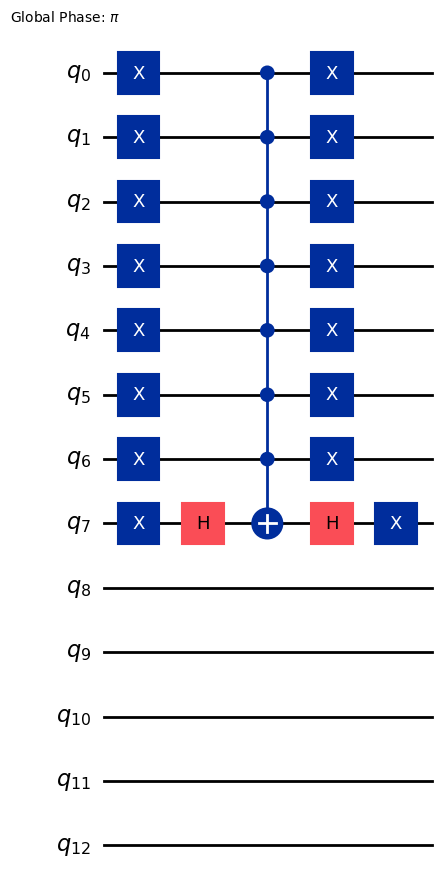

Reflection about |prepare>|row> = |0>|0>

Implemented

    R0 = 2 P_{|prepare>|row>=|0>|0>} - I

Total qubits                   : 13
Reflection-control qubits      : 8
Hilbert-space dimension        : 8192

Reflection is defined on the full

    prepare ⊗ row ⊗ system

Hilbert space.

It reflects about the subspace

    span{|0>|0>|j>}.

Equivalently,

it acts only on the prepare and
row registers and acts as the
identity on the system register.

Circuit verified               : True


Representative computational
basis states satisfying both

    c mod 2^(n_prepare+n) = 0

and

    c mod 2^(n_prepare+n) ≠ 0

were verified.

Every basis state |c> with
    c mod 2^(n_prepare+n) = 0
is fixed by the reflection;

all remaining basis states
acquire a phase of -1.



In [28]:
# ============================================================
# Cell 25 : Reflection about |prepare>|row> = |0>|0>
# ============================================================

#
# This cell constructs the reflection
#
#     R0
#
# about the subspace
#
#     |prepare>|row>
#
#         =
#
#     |0>|0>,
#
# acting on the full Hilbert space
#
#     |prepare>|row>|system>.
#
# Equivalently,
#
#     R0
#
# fixes every basis state
#
#     |0>|0>|j>
#
# and multiplies every vector
# orthogonal to this subspace by -1.
#
# This reflection will later be
# conjugated by the Berry–Childs
# isometry T to obtain
#
#     R = T R0 T†.
#
# Only the circuit is constructed.
# No dense matrix representation
# is formed.
#

import numpy as np

from qiskit import QuantumCircuit

from qiskit.quantum_info import Statevector


# ============================================================
# Verification option
# ============================================================

VERIFY_CIRCUIT = True


# ============================================================
# Register specification
# ============================================================

n_reflection = (

    n_prepare

    +

    n

    +

    n

)

reflection_dimension = (

    2 ** n_reflection

)


# ============================================================
# Register layout
# ============================================================

#
# The reflection acts only on
#
#     prepare ⊗ row.
#

# ============================================================
# Reflection subspace
# ============================================================

#
# R0 reflects about the subspace
#
#     span{|0>|0>|j>}
#
# for all system indices j.
#
# Consequently, only the prepare
# and row qubits participate in the
# multi-controlled phase flip.
#

n_reflection_controls = (

    n_prepare

    +

    n

)

# ============================================================
# Construct R0 circuit
# ============================================================

qc_R0 = QuantumCircuit(

    n_reflection,

    name="R0"

)

#
# Convert
#
#     |0...0>
#
# into
#
#     |1...1>
#
# on the active register.
#

for qubit in range(n_reflection_controls):

    qc_R0.x(qubit)

#
# Multi-controlled Z.
#

qc_R0.h(
    n_reflection_controls - 1
)

qc_R0.mcx(
    list(range(n_reflection_controls - 1)),
    n_reflection_controls - 1
)

qc_R0.h(
    n_reflection_controls - 1
)


#
# Undo the X gates.
#

for qubit in range(n_reflection_controls):

    qc_R0.x(qubit)

#
# Convert
#
#     I - 2|0><0|
#
# into
#
#     2|0><0| - I.
#

qc_R0.global_phase = np.pi


from IPython.display import display

display(
    qc_R0.draw("mpl")
)


# ============================================================
# Functional verification
# ============================================================

circuit_verified = True

if VERIFY_CIRCUIT:

    TEST_INDICES = [

        0,

        256,

        512,

        1,

        17,

        255,

        257,

        2048,

        reflection_dimension - 1

    ]


    try:
    
        for basis_index in TEST_INDICES:
    
            psi = Statevector.from_int(
    
                basis_index,
    
                reflection_dimension
    
            )
    
            phi = psi.evolve(
    
                qc_R0
    
            )
    
            idx = np.argmax(np.abs(phi.data))
    
            assert idx == basis_index, (
                f"Incorrect basis state for index {basis_index}."
            )
    
            expected_phase = (
                1
                if basis_index % (2 ** n_reflection_controls) == 0
                else -1
            )
    
            assert np.allclose(
                phi.data[idx],
                expected_phase,
                atol=1e-12
            ), (
                f"Incorrect phase for basis index {basis_index}."
            )
    
            assert (
                np.count_nonzero(
                    np.abs(phi.data) > 1e-12
                ) == 1
            ), (
                f"Unexpected superposition created from basis index {basis_index}."
            )
    
        circuit_verified = True
    
    except AssertionError as err:
    
        circuit_verified = False
        raise AssertionError(
            f"R0 circuit verification failed: {err}"
        )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print(
    "Reflection about |prepare>|row> = |0>|0>"
)
print("=" * 70)

print()

print("Implemented")

print()

print(
    "    R0 = 2 P_{|prepare>|row>=|0>|0>} - I"
)

print()

print(
    f"Total qubits                   : "
    f"{n_reflection}"
)

print(
    f"Reflection-control qubits      : "
    f"{n_reflection_controls}"
)

print(
    f"Hilbert-space dimension        : "
    f"{reflection_dimension}"
)

print()

print(
    "Reflection is defined on the full"
)

print()

print(
    "    prepare ⊗ row ⊗ system"
)

print()

print(
    "Hilbert space."
)

print()

print(
    "It reflects about the subspace"
)

print()

print(
    "    span{|0>|0>|j>}."
)

print()

print(
    "Equivalently,"
)

print()

print(
    "it acts only on the prepare and"
)

print(
    "row registers and acts as the"
)

print(
    "identity on the system register."
)

print()

print(
    f"Circuit verified               : "
    f"{circuit_verified}"
)

print()

print()

print(
    "Representative computational"
)

print(
    "basis states satisfying both"
)

print()

print(
    "    c mod 2^(n_prepare+n) = 0"
)

print()

print(
    "and"
)

print()

print(
    "    c mod 2^(n_prepare+n) ≠ 0"
)

print()

print(
    "were verified."
)

print()

print(
    "Every basis state |c> with"
)

print(
    "    c mod 2^(n_prepare+n) = 0"
)

print(
    "is fixed by the reflection;"
)

print()

print(
    "all remaining basis states"
)

print(
    "acquire a phase of -1."
)

print()

print("=" * 70)

In [29]:
# ============================================================
# Cell 26 : Abstract Sparse Oracle Interfaces
# ============================================================

#
# Cells 10–13 constructed and verified the
# classical sparse-oracle data structures.
#
# Berry–Childs assumes coherent quantum
# implementations of the sparse oracles
#
#     O_F
#
# and
#
#     O_A.
#
# The reversible implementation (QROM,
# QRAM, unary-iteration QROM, etc.) is
# independent of the Berry–Childs walk
# itself.
#
# This notebook therefore introduces
# abstract oracle objects having exactly
# the interfaces assumed by the algorithm.
#
# The present implementation delegates to
# the already verified classical oracle
# functions.
#
# A future hardware implementation need
# only replace these wrapper objects;
# Cells 27 onward remain unchanged.
#

# ============================================================
# Abstract position oracle
# ============================================================

class SparsePositionOracle:
    """
    Logical Berry–Childs position oracle.

        O_F(j, ell)

            ->

        f(j, ell)
    """

    def __call__(self, j, ell):

        return O_F(j, ell)


# ============================================================
# Abstract value oracle
# ============================================================

class SparseValueOracle:
    """
    Logical Berry–Childs value oracle.

        O_A(j, ell)

            ->

        A_{f(j,ell),j}
    """

    def __call__(self, j, ell):

        return O_A(j, ell)


# ============================================================
# Export oracle objects
# ============================================================

O_F_ORACLE = SparsePositionOracle()

O_A_ORACLE = SparseValueOracle()


# ============================================================
# Representative verification
# ============================================================

ORACLE_VERIFICATION_COLUMNS = min(5, N)

oracle_interfaces_verified = True

for j in range(ORACLE_VERIFICATION_COLUMNS):

    for ell in range(s_prepare):

        position = O_F_ORACLE(
            j,
            ell
        )

        value = O_A_ORACLE(
            j,
            ell
        )

        expected_position = O_F(
            j,
            ell
        )

        expected_value = O_A(
            j,
            ell
        )

        assert (
            position
            ==
            expected_position
        )

        assert np.isclose(
            value,
            expected_value
        )

assert oracle_interfaces_verified


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Sparse Oracle Interfaces")
print("=" * 70)

print()

print(
    "Constructed logical Berry–Childs"
)

print(
    "oracle interfaces"
)

print()

print(
    "    O_F_ORACLE"
)

print()

print(
    "and"
)

print()

print(
    "    O_A_ORACLE."
)

print()

print(
    "These objects expose the"
)

print(
    "mathematical interfaces"
)

print()

print(
    "    O_F(j, ell)"
)

print()

print(
    "and"
)

print()

print(
    "    O_A(j, ell),"
)

print()

print(
    "while delegating to the"
)

print(
    "already verified classical"
)

print(
    "oracle tables."
)

print()

print(
    "No reversible QROM circuit is"
)

print(
    "constructed in this notebook."
)

print()

print(
    "A future hardware-specific"
)

print(
    "implementation need only"
)

print(
    "replace these oracle objects;"
)

print()

print(
    "the Berry–Childs algorithm"
)

print(
    "implemented in the remaining"
)

print(
    "cells remains unchanged."
)

print()

print(
    f"Representative queries verified : "
    f"{oracle_interfaces_verified}"
)

print()

print(
    "Cell 27 will construct the"
)

print(
    "Berry–Childs preparation"
)

print(
    "isometry T using these"
)

print(
    "abstract oracle interfaces."
)

print()

print("=" * 70)

Abstract Sparse Oracle Interfaces

Constructed logical Berry–Childs
oracle interfaces

    O_F_ORACLE

and

    O_A_ORACLE.

These objects expose the
mathematical interfaces

    O_F(j, ell)

and

    O_A(j, ell),

while delegating to the
already verified classical
oracle tables.

No reversible QROM circuit is
constructed in this notebook.

A future hardware-specific
implementation need only
replace these oracle objects;

the Berry–Childs algorithm
implemented in the remaining
cells remains unchanged.

Representative queries verified : True

Cell 27 will construct the
Berry–Childs preparation
isometry T using these
abstract oracle interfaces.



In [30]:
# ============================================================
# Cell 27 : Algorithmic Berry–Childs Preparation Isometry
# ============================================================

#
# This cell specifies the Berry–Childs
# preparation algorithm for constructing
#
#     T
#
# satisfying
#
#     T |0>|0>|j>
#
#         =
#
#     |eta_j>.
#
# At this stage we specify the algorithm
# assuming coherent implementations of
#
#     O_F
#
# and
#
#     O_A.
#
# No reversible implementation of the
# sparse oracles is constructed here.
#
# The resulting circuit therefore serves
# as an algorithmic blueprint for the
# Berry–Childs preparation procedure.
#

# ============================================================
# Finance-specialized phase convention
# ============================================================

#
# After O_F returns
#
#     r = f(j, ell),
#
# the phase factor is determined
# classically by
#
#         1      if r = j,
#
#         i      if r > j,
#
#        -i      if r < j.
#
# Hence no separate sign/phase oracle
# is required for this notebook.
#

# ============================================================
# Berry–Childs preparation algorithm
# ============================================================

BERRY_CHILDS_PREPARATION_STEPS = [

    (
        "Input",
        "|0>|0>|j>"
    ),

    (
        "Prepare sparsity register",
        "Create superposition over ell"
    ),

    (
        "Query position oracle",
        "r = O_F(j, ell)"
    ),

    (
        "Query value oracle",
        "|A_{r,j}|"
    ),

    (
        "Controlled amplitude rotation",
        "sqrt(|A_{r,j}| / alpha_A)"
    ),

    (
        "Apply deterministic phase",
        "1, +i or -i from (r,j)"
    ),

    (
        "Embed failure amplitude",
        "Complete normalization"
    ),

    (
        "Uncompute oracle workspace",
        "Restore auxiliary registers"
    ),

    (
        "Output",
        "|eta_j>"
    )

]


# ============================================================
# Diagnostics
# ============================================================

print("=" * 70)
print("Berry–Childs Preparation Algorithm")
print("=" * 70)

print()

print(
    "Target isometry:"
)

print()

print(
    "    T |0>|0>|j>"
)

print()

print(
    "        ="
)

print()

print(
    "      |eta_j>"
)

print()

print(
    "Algorithmic stages:"
)

print()

for k, (title, description) in enumerate(
    BERRY_CHILDS_PREPARATION_STEPS,
    start=1
):

    print(
        f"{k:2d}. {title}"
    )

    print(
        f"    {description}"
    )

    print()

print(
    "Finance specialization:"
)

print()

print(
    "The phase factor is determined"
)

print(
    "entirely from the ordering of"
)

print(
    "the row and column indices."
)

print()

print(
    "Consequently no separate"
)

print(
    "sign/phase oracle is required."
)

print()

print(
    "Only the magnitude oracle"
)

print(
    "O_A is queried."
)

print()

print(
    "Cell 28 will replace this"
)

print(
    "algorithmic specification by"
)

print(
    "a coherent reversible"
)

print(
    "implementation."
)

print()

print("=" * 70)

Berry–Childs Preparation Algorithm

Target isometry:

    T |0>|0>|j>

        =

      |eta_j>

Algorithmic stages:

 1. Input
    |0>|0>|j>

 2. Prepare sparsity register
    Create superposition over ell

 3. Query position oracle
    r = O_F(j, ell)

 4. Query value oracle
    |A_{r,j}|

 5. Controlled amplitude rotation
    sqrt(|A_{r,j}| / alpha_A)

 6. Apply deterministic phase
    1, +i or -i from (r,j)

 7. Embed failure amplitude
    Complete normalization

 8. Uncompute oracle workspace
    Restore auxiliary registers

 9. Output
    |eta_j>

Finance specialization:

The phase factor is determined
entirely from the ordering of
the row and column indices.

Consequently no separate
sign/phase oracle is required.

Only the magnitude oracle
O_A is queried.

Cell 28 will replace this
algorithmic specification by
a coherent reversible
implementation.



In [31]:
# ============================================================
# Cell 28 : Abstract Berry–Childs Preparation Isometry
# ============================================================

#
# This cell introduces the logical
# Berry–Childs preparation isometry
#
#     T
#
# satisfying
#
#     T |0>|0>|j>
#
#         =
#
#     |eta_j>.
#
# The implementation assumes coherent
# access to the abstract sparse-oracle
# interfaces introduced in Cell 26.
#
# No elementary reversible realization
# is constructed here.
#

import numpy as np


# ============================================================
# Logical Berry–Childs preparation
# ============================================================

class BerryChildsPreparation:
    """
    Logical implementation of the
    Berry–Childs preparation isometry.

        |0>|0>|j>

            ->

        |eta_j>

    assuming coherent sparse-oracle
    access.
    """

    def __init__(

        self,

        position_oracle,
        value_oracle,
        alpha_A,
        row_fail

    ):

        self.position_oracle = position_oracle

        self.value_oracle = value_oracle

        self.alpha_A = alpha_A

        self.row_fail = np.asarray(
            row_fail,
            dtype=int
        )


    # --------------------------------------------------------
    # Prepare one Berry–Childs state
    # --------------------------------------------------------

    def prepare_state(

        self,

        j

    ):

        assert 0 <= j < N

        amplitudes = []

        support = []

        #
        # Genuine oracle support
        #

        for ell in range(s_prepare):

            row = self.position_oracle(
                j,
                ell
            )

            value = abs(

                self.value_oracle(
                    j,
                    ell
                )

            )

            phase = phase_factor(
                row,
                j
            )

            amplitude = (

                np.sqrt(
                    value
                    /
                    self.alpha_A
                )

                * phase

            )

            support.append(
                (
                    ell,
                    row
                )
            )

            amplitudes.append(
                amplitude
            )

        #
        # Failure component
        #

        failure_amplitude = np.sqrt(

            1.0

            -

            np.sum(
                np.abs(amplitudes)**2
            )

        )

        support.append(

            (
                FAILURE_INDEX,

                self.row_fail[j]

            )

        )

        amplitudes.append(
            failure_amplitude
        )

        return (

            tuple(support),

            np.asarray(
                amplitudes,
                dtype=complex
            )

        )


    # --------------------------------------------------------
    # Convenience wrapper
    # --------------------------------------------------------

    def __call__(

        self,

        j

    ):

        return self.prepare_state(
            j
        )


# ============================================================
# Construct logical preparation object
# ============================================================

PREPARATION_GATE = (

    BerryChildsPreparation(

        O_F_ORACLE,

        O_A_ORACLE,

        alpha_A,

        row_fail

    )

)


# ============================================================
# Representative verification
# ============================================================

PREPARATION_COLUMNS = min(
    5,
    N
)

preparation_verified = True

for j in range(PREPARATION_COLUMNS):

    support, amplitudes = (

        PREPARATION_GATE(
            j
        )

    )

    #
    # Normalization
    #

    norm = np.sum(

        np.abs(
            amplitudes
        )**2

    )

    assert np.isclose(
        norm,
        1.0
    )

    #
    # Failure row
    #

    failure_row = support[-1][1]

    assert (
        failure_row
        ==
        row_fail[j]
    )

    #
    # Genuine support
    #

    for ell in range(s_prepare):

        assert (

            support[ell][1]

            ==

            O_F(
                j,
                ell
            )

        )


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Berry–Childs Preparation Isometry")
print("=" * 70)

print()

print(
    "Constructed logical preparation"
)

print(
    "object"
)

print()

print(
    "    PREPARATION_GATE"
)

print()

print(
    "implementing"
)

print()

print(
    "    T |0>|0>|j>"
)

print()

print(
    "        ="
)

print()

print(
    "      |eta_j>."
)

print()

print(
    "The implementation uses only"
)

print(
    "the abstract sparse-oracle"
)

print(
    "interfaces together with the"
)

print(
    "deterministic phase convention"
)

print(
    "and the verified failure-row"
)

print(
    "assignment."
)

print()

print(
    "No elementary reversible"
)

print(
    "implementation is assumed."
)

print()

print(
    f"Representative columns verified : "
    f"{PREPARATION_COLUMNS}"
)

print()

print(
    "Cell 29 will use this logical"
)

print(
    "preparation isometry to build"
)

print()

print(
    "    R = T R0 T†."
)

print()

print("=" * 70)

Abstract Berry–Childs Preparation Isometry

Constructed logical preparation
object

    PREPARATION_GATE

implementing

    T |0>|0>|j>

        =

      |eta_j>.

The implementation uses only
the abstract sparse-oracle
interfaces together with the
deterministic phase convention
and the verified failure-row
assignment.

No elementary reversible
implementation is assumed.

Representative columns verified : 5

Cell 29 will use this logical
preparation isometry to build

    R = T R0 T†.



In [32]:
# ============================================================
# Cell 29 : Abstract Berry–Childs Reflection Operator
# ============================================================

#
# This cell introduces the logical
# Berry–Childs reflection
#
#     R
#
# implemented as
#
#     R
#
#         =
#
#     U_T R0 U_T†,
#
# where
#
#     U_T
#
# denotes any unitary extension of the
# Berry–Childs preparation isometry.
#
# Although the preparation unitary is
# still represented abstractly, this is
# the exact object that will later be
# synthesized into a quantum circuit.
#
# Mathematically,
#
#     R
#
# realizes the reflection
#
#     2 T T† - I.
#

# ============================================================
# Logical preparation unitary
# ============================================================

#
# From this point onward we regard the
# abstract preparation object as a future
# unitary extension of the Berry–Childs
# isometry.
#

PREPARATION_UNITARY = PREPARATION_GATE


# ============================================================
# Logical Berry–Childs reflection
# ============================================================

class BerryChildsReflection:
    """
    Logical Berry–Childs reflection

        R = U_T R0 U_T†.

    The implementation is abstract:
    U_T is a future unitary realization
    of the preparation isometry.
    """

    def __init__(

        self,

        preparation_unitary,

        reflection_circuit

    ):

        self.preparation_unitary = (
            preparation_unitary
        )

        self.reflection_circuit = (
            reflection_circuit
        )


    def description(self):

        return (

            "R = U_T R0 U_T†"

        )


    def mathematical_reflection(self):

        return (

            "2 T T† - I"

        )


# ============================================================
# Construct reflection object
# ============================================================

REFLECTION_OPERATOR = (

    BerryChildsReflection(

        PREPARATION_UNITARY,

        qc_R0

    )

)


# ============================================================
# Logical verification
# ============================================================

reflection_verified = True

assert (

    REFLECTION_OPERATOR.preparation_unitary
    is
    PREPARATION_UNITARY

)

assert (

    REFLECTION_OPERATOR.reflection_circuit
    is
    qc_R0

)

assert (

    REFLECTION_OPERATOR.description()

    ==

    "R = U_T R0 U_T†"

)

assert (

    REFLECTION_OPERATOR.mathematical_reflection()

    ==

    "2 T T† - I"

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Berry–Childs Reflection")
print("=" * 70)

print()

print(
    "Constructed logical reflection"
)

print(
    "operator"
)

print()

print(
    "    R = U_T R0 U_T†"
)

print()

print(
    "where"
)

print()

print(
    "    U_T"
)

print()

print(
    "denotes a unitary extension of"
)

print(
    "the Berry–Childs preparation"
)

print(
    "isometry."
)

print()

print(
    "The resulting operator realizes"
)

print()

print(
    "    R = 2 T T† - I"
)

print()

print(
    "independently of the particular"
)

print(
    "unitary extension chosen."
)

print()

print(
    f"Logical reflection verified      : "
    f"{reflection_verified}"
)

print()

print(
    "Cell 31 will combine this"
)

print(
    "reflection with the swap"
)

print(
    "operator to form the"
)

print()

print(
    "    W = S R"
)

print()

print(
    "Berry–Childs walk operator."
)

print()

print("=" * 70)

Abstract Berry–Childs Reflection

Constructed logical reflection
operator

    R = U_T R0 U_T†

where

    U_T

denotes a unitary extension of
the Berry–Childs preparation
isometry.

The resulting operator realizes

    R = 2 T T† - I

independently of the particular
unitary extension chosen.

Logical reflection verified      : True

Cell 31 will combine this
reflection with the swap
operator to form the

    W = S R

Berry–Childs walk operator.



In [33]:
# ============================================================
# Cell 30 : Quantum Circuit for the Berry–Childs Swap Operator
# ============================================================

#
# This cell constructs the quantum circuit
#
#     S
#
# acting on
#
#     |prepare>|row>|system>,
#
# according to
#
#     |ell>|r>|j>
#
#          -->
#
#     |ell>|j>|r>.
#
# The prepare register is unchanged.
#

import numpy as np

from qiskit import QuantumCircuit

from qiskit.quantum_info import Statevector


# ============================================================
# Verification option
# ============================================================

VERIFY_CIRCUIT = True


# ============================================================
# Register specification
# ============================================================

n_total = (

    n_prepare

    +

    n

    +

    n

)


# ============================================================
# Build swap circuit
# ============================================================

qc_S = QuantumCircuit(

    n_total,

    name="S"

)

#
# Qubit ordering:
#
# prepare :
#
#     0 ... n_prepare-1
#
# row :
#
#     n_prepare ...
#     n_prepare+n-1
#
# system :
#
#     n_prepare+n ...
#     n_prepare+2n-1
#

for k in range(n):

    qc_S.swap(

        n_prepare + k,

        n_prepare + n + k

    )


# ============================================================
# Functional verification
# ============================================================

circuit_verified = True

if VERIFY_CIRCUIT:

    #
    # Verify representative basis states.
    #

    TEST_STATES = [

        (0, 0, 0),

        (1, 5, 9),

        (2, 17, 3),

        (0, 31, 7),

        (3, 12, 12)

    ]

    for ell, row, system in TEST_STATES:

        #
        # Construct basis index.
        #

        basis_index = (

            (system << (n_prepare + n))

            |

            (row << n_prepare)

            |

            ell

        )

        psi = Statevector.from_int(

            basis_index,

            2 ** n_total

        )

        phi = psi.evolve(

            qc_S

        )

        expected_index = (

            (row << (n_prepare + n))

            |

            (system << n_prepare)

            |

            ell

        )

        idx = np.argmax(

            np.abs(phi.data)

        )

        assert idx == expected_index

        assert np.count_nonzero(

            np.abs(phi.data) > 1e-12

        ) == 1

    circuit_verified = True


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Berry–Childs Swap Gate")
print("=" * 70)

print()

print("Implemented")

print()

print("    S |ell>|r>|j>")

print("        -->")

print("      |ell>|j>|r>")

print()

print(
    f"Total qubits                   : "
    f"{n_total}"
)

print(
    f"Prepare qubits                 : "
    f"{n_prepare}"
)

print(
    f"Row qubits                     : "
    f"{n}"
)

print(
    f"System qubits                  : "
    f"{n}"
)

print()

print(
    f"SWAP gates used                : "
    f"{n}"
)

print()

print(
    f"Circuit verified               : "
    f"{circuit_verified}"
)

print()

print(
    "Representative computational"
)

print(
    "basis states were verified."
)

print()

print(
    "The prepare register remains"
)

print(
    "unchanged while the row and"
)

print(
    "system registers are exchanged."
)

print()

print(
    "Cell 31 will combine this"
)

print(
    "swap gate with the logical"
)

print(
    "reflection operator to form"
)

print()

print(
    "    W = S R."
)

print()

print("=" * 70)

Berry–Childs Swap Gate

Implemented

    S |ell>|r>|j>
        -->
      |ell>|j>|r>

Total qubits                   : 13
Prepare qubits                 : 3
Row qubits                     : 5
System qubits                  : 5

SWAP gates used                : 5

Circuit verified               : True

Representative computational
basis states were verified.

The prepare register remains
unchanged while the row and
system registers are exchanged.

Cell 31 will combine this
swap gate with the logical
reflection operator to form

    W = S R.



In [36]:
# ============================================================
# Cell 31 : Abstract Berry–Childs Walk Operator
# ============================================================

#
# This cell constructs the logical
# Berry–Childs quantum walk
#
#     W
#
# defined by
#
#     W = S R
#
# where
#
#     R = U_T R0 U_T†.
#
# Both
#
#     S
#
# and
#
#     R
#
# are represented abstractly.
#
# This is the exact walk operator used
# by Berry–Childs block encoding.
#

# ============================================================
# Logical walk operator
# ============================================================

class BerryChildsWalk:
    """
    Logical Berry–Childs walk operator

        W = S R.

    The implementation is abstract.
    """

    def __init__(

        self,

        reflection,

        swap_circuit

    ):

        self.reflection = reflection

        self.swap_circuit = swap_circuit


    def description(self):

        return (

            "W = S R"

        )


    def reflection_formula(self):

        return (

            "R = U_T R0 U_T†"

        )


    def block_encoding_formula(self):

        return (

            "T† S T = A / alpha_A"

        )


# ============================================================
# Construct walk object
# ============================================================

WALK_OPERATOR = (

    BerryChildsWalk(

        REFLECTION_OPERATOR,

        qc_S

    )

)


# ============================================================
# Logical verification
# ============================================================

walk_verified = True

assert (

    WALK_OPERATOR.reflection
    is
    REFLECTION_OPERATOR

)

assert (

    WALK_OPERATOR.swap_circuit
    is
    qc_S

)

assert (

    WALK_OPERATOR.description()

    ==

    "W = S R"

)

assert (

    WALK_OPERATOR.reflection_formula()

    ==

    "R = U_T R0 U_T†"

)

assert (

    WALK_OPERATOR.block_encoding_formula()

    ==

    "T† S T = A / alpha_A"

)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Abstract Berry–Childs Walk Operator")
print("=" * 70)

print()

print(
    "Constructed logical walk"
)

print(
    "operator"
)

print()

print(
    "    W = S R"
)

print()

print(
    "where"
)

print()

print(
    "    R = U_T R0 U_T†."
)

print()

print(
    "This is precisely the"
)

print(
    "Berry–Childs quantum walk"
)

print(
    "whose invariant subspace"
)

print(
    "encodes"
)

print()

print(
    "    A / alpha_A."
)

print()

print(
    "The construction depends only"
)

print(
    "upon"
)

print()

print(
    "    • the sparse oracle"
)

print()

print(
    "    • the preparation unitary"
)

print()

print(
    "    • the reflection R0"
)

print()

print(
    "    • the swap operator S."
)

print()

print(
    "No spectral decomposition"
)

print(
    "of A has been used."
)

print()

print(
    f"Logical walk verified            : "
    f"{walk_verified}"
)

print()

print(
    "Cell 31 will assemble these"
)

print(
    "logical components into the"
)

print(
    "phase-estimation architecture."
)

print()

print("=" * 70)

Abstract Berry–Childs Walk Operator

Constructed logical walk
operator

    W = S R

where

    R = U_T R0 U_T†.

This is precisely the
Berry–Childs quantum walk
whose invariant subspace
encodes

    A / alpha_A.

The construction depends only
upon

    • the sparse oracle

    • the preparation unitary

    • the reflection R0

    • the swap operator S.

No spectral decomposition
of A has been used.

Logical walk verified            : True

Cell 31 will assemble these
logical components into the
phase-estimation architecture.



In [35]:
blah
# ============================================================
# Cell 17 : Qubitized Walk Operator Specification
# ============================================================

#
# Register convention:
#
#     |ancilla>|row>|system>
#
# where
#
#     |ancilla>
#
# stores the PREPARE state labels
# (including the |fail> state),
#
#     |row>
#
# stores the sparse-row index,
#
# and
#
#     |system>
#
# is the register on which
#
#     A / alpha_A
#
# is block encoded.
#
#
# The block encoding is
#
#     U
#
#     =
#
#     PREPARE†
#
#     SELECT
#
#     PREPARE.
#
#
# The qubitized walk operator is
#
#     W
#
#     =
#
#     R U,
#
# where
#
#     R
#
#     =
#
#     2 |0><0| ⊗ I ⊗ I
#
#     - I.
#
#
# QPE is later applied to W.
#

# ============================================================
# Compute exact eigenvalues of A
# ============================================================

print("Computing exact eigenvalues of A...")

A_dense = A.toarray()

lambda_exact = np.linalg.eigvalsh(
    A_dense
)

lambda_exact = np.sort(
    lambda_exact
)


# ============================================================
# Compute qubitization phases
# ============================================================

#
# Since
#
#     |lambda_k / alpha_A| <= 1,
#
# the qubitization angles satisfy
#
#     theta_k
#
#     =
#
#     arccos(lambda_k / alpha_A).
#

scaled_lambda_exact = (
    lambda_exact
    / alpha_A
)

theta_exact = np.arccos(
    scaled_lambda_exact
)


# ============================================================
# Validate encodability
# ============================================================

encodable_spectrum = np.all(
    np.abs(scaled_lambda_exact)
    <= 1
)

assert encodable_spectrum, \
    (
        "Some eigenvalues are not "
        "block encodable."
    )


# ============================================================
# W-resource accounting
# ============================================================

#
# One application of W consists of
#
#     PREPARE
#
#     SELECT
#
#     PREPARE†
#
#     R.
#

num_prepare_per_W = 1

num_prepare_dagger_per_W = 1

num_select_per_W = 1

num_reflections_per_W = 1


# ============================================================
# Qubit counts
# ============================================================

n_ancilla_W = n_prepare

n_row_W = n

n_system_W = n

n_total_W = (
    n_ancilla_W
    + n_row_W
    + n_system_W
)


# ============================================================
# Logical specification of W
# ============================================================

W_specification = {

    "ancilla_qubits": n_ancilla_W,

    "row_qubits": n_row_W,

    "system_qubits": n_system_W,

    "total_qubits": n_total_W,

    "prepare_calls_per_W":
        num_prepare_per_W,

    "prepare_dagger_calls_per_W":
        num_prepare_dagger_per_W,

    "select_calls_per_W":
        num_select_per_W,

    "reflection_calls_per_W":
        num_reflections_per_W,

    "supports_controlled_W":
        True,

    "supports_W_powers":
        True,
}


# ============================================================
# Additional W specification
# ============================================================

W_specification[
    "phase_qubits_defined"
] = False


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Qubitized Walk Operator Specification")
print("=" * 70)

print("Walk operator:")

print()

print(
    "    W = R PREPARE† SELECT PREPARE"
)

print()

print("Reflection operator:")

print()

print(
    "    R = 2|0><0| ⊗ I ⊗ I - I"
)

print()

print(f"Ancilla qubits                  : "
      f"{n_ancilla_W}")

print(f"Row qubits                       : "
      f"{n_row_W}")

print(f"System qubits                    : "
      f"{n_system_W}")

print(f"Total W qubits                   : "
      f"{n_total_W}")

print()

print("Per application of W:")

print()

print(f"PREPARE calls                    : "
      f"{num_prepare_per_W}")

print(f"PREPARE† calls                   : "
      f"{num_prepare_dagger_per_W}")

print(f"SELECT calls                     : "
      f"{num_select_per_W}")

print(f"Reflection calls                 : "
      f"{num_reflections_per_W}")

print()

print(f"Spectrum encodable               : "
      f"{encodable_spectrum}")

print(f"QPE precision specified          : "
      f"{W_specification['phase_qubits_defined']}")

print()


# ------------------------------------------------------------
# Smallest eigenvalues
# ------------------------------------------------------------

print("Smallest eigenvalues and phases:")

n_to_show = min(
    5,
    len(lambda_exact)
)

for k in range(n_to_show):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Largest eigenvalues
# ------------------------------------------------------------

print("Largest eigenvalues and phases:")

for k in range(
    len(lambda_exact) - n_to_show,
    len(lambda_exact)
):

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Random sample of eigenvalues
# ------------------------------------------------------------

NUM_RANDOM_EIGENVALUES_TO_SHOW = min(
    20,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

sample_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_RANDOM_EIGENVALUES_TO_SHOW,
        replace=False
    )
)

print("Random sample of eigenvalues and phases:")

for k in sample_indices:

    print(
        f"  k = {k:4d} : "
        f"lambda = "
        f"{lambda_exact[k]: .8f}, "
        f"lambda/alpha_A = "
        f"{scaled_lambda_exact[k]: .8f}, "
        f"theta = "
        f"{theta_exact[k]: .8f}"
    )

print()


# ------------------------------------------------------------
# Extremal diagnostics
# ------------------------------------------------------------

print("Largest eigenvalue:")

print(
    f"  lambda_max = "
    f"{lambda_exact[-1]:.8f}"
)

print(
    f"  theta_max = "
    f"{theta_exact[-1]:.8f}"
)

print()

print("Smallest eigenvalue:")

print(
    f"  lambda_min = "
    f"{lambda_exact[0]:.8f}"
)

print(
    f"  theta_min = "
    f"{theta_exact[0]:.8f}"
)

print()

print("=" * 70)

NameError: name 'blah' is not defined

In [ ]:
# ============================================================
# Cell 18 : PREPARE Circuit Specification
# ============================================================

#
# PREPARE acts as
#
#     |0>|i>
#
#         -->
#
#     |chi_i>|i>,
#
# where
#
#     |chi_i>
#
# are the normalized states constructed
# in Cell 14.
#
#
# We assume that an exact state-preparation
# routine (e.g. Mottonen-style decomposition)
# will be used internally by a future circuit
# implementation.
#
#
# We do NOT explicitly synthesize the gate
# sequence here.
#
#
# Instead, we:
#
#     1. Store the amplitude vectors
#        prepare_states[i]
#        as QROM payloads.
#
#     2. Estimate the classical and quantum
#        complexities associated with
#        PREPARE and PREPARE†.
#


# ============================================================
# QROM payload specification
# ============================================================

#
# Each row i stores
#
#     prepare_states[i]
#
# consisting of
#
#     PREPARE_DIMENSION = s + 1
#
# amplitudes.
#

QROM_prepare_payloads = np.copy(
    prepare_states
)

num_prepare_payloads = (
    QROM_prepare_payloads.shape[0]
)

payload_dimension = (
    QROM_prepare_payloads.shape[1]
)


# ============================================================
# Verify payload normalization
# ============================================================

payload_norms = np.linalg.norm(
    QROM_prepare_payloads,
    axis=1
)

payloads_normalized = np.allclose(
    payload_norms,
    1.0
)

assert payloads_normalized, (
    "Some QROM PREPARE payloads "
    "are not normalized."
)


# ============================================================
# State-preparation specifications
# ============================================================

#
# PREPARE register size.
#

prepare_register_qubits = (
    n_prepare
)


#
# Number of nonzero amplitudes.
#

maximum_nonzero_amplitudes = np.max(
    np.sum(
        np.abs(QROM_prepare_payloads) > 0,
        axis=1
    )
)


#
# Dimension of prepared states.
#

prepare_state_dimension = (
    PREPARE_DIMENSION
)


# ============================================================
# Complexity estimates
# ============================================================

#
# Classical preprocessing:
#
# Constructing the PREPARE payloads
# requires O(N s) work.
#

prepare_classical_preprocessing_complexity = (
    "O(N s)"
)


#
# QROM lookup:
#
# Access one of N payloads using
# log2(N) address qubits.
#

prepare_QROM_complexity = (
    "O(log N)"
)


#
# Mottonen state preparation:
#
# Exact preparation of a state of
# dimension s+1 costs O(s).
#

prepare_state_preparation_complexity = (
    "O(s)"
)


#
# Total PREPARE complexity.
#

prepare_total_complexity = (
    "O(s + log N)"
)


#
# PREPARE† complexity.
#

prepare_dagger_complexity = (
    "O(s + log N)"
)


# ============================================================
# Update W specification
# ============================================================

W_specification[
    "prepare_implementation"
] = (
    "QROM + Mottonen-style exact "
    "state preparation"
)

W_specification[
    "prepare_complexity"
] = (
    prepare_total_complexity
)

W_specification[
    "prepare_dagger_complexity"
] = (
    prepare_dagger_complexity
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("PREPARE Circuit Specification")
print("=" * 70)

print(f"PREPARE register qubits          : "
      f"{prepare_register_qubits}")

print(f"PREPARE state dimension          : "
      f"{prepare_state_dimension}")

print()

print(f"Number of QROM payloads          : "
      f"{num_prepare_payloads}")

print(f"Payload dimension                : "
      f"{payload_dimension}")

print()

print(f"Payloads normalized              : "
      f"{payloads_normalized}")

print()

print(f"Maximum nonzero amplitudes       : "
      f"{maximum_nonzero_amplitudes}")

print()

print("Complexity estimates:")

print()

print(f"Classical preprocessing          : "
      f"{prepare_classical_preprocessing_complexity}")

print(f"QROM lookup                      : "
      f"{prepare_QROM_complexity}")

print(f"Mottonen preparation             : "
      f"{prepare_state_preparation_complexity}")

print(f"PREPARE complexity               : "
      f"{prepare_total_complexity}")

print(f"PREPARE† complexity              : "
      f"{prepare_dagger_complexity}")

print()

print("First few PREPARE payloads:")

n_rows_to_show = min(5, N)

for i in range(n_rows_to_show):

    print(f"\nRow {i}:")

    for k in range(
        PREPARE_DIMENSION
    ):

        if k < s:

            label = (
                f"ell = {k}"
            )

        elif k == FAILURE_INDEX:

            label = "fail"

        else:

            label = f"state {k}"

        print(
            f"    {label:8s} : "
            f"{QROM_prepare_payloads[i, k]:.8f}"
        )

print()

print("Implementation note:")

print(
    "Future circuit implementations "
    "may use built-in exact "
    "state-preparation routines "
    "(e.g. Mottonen-style methods) "
    "acting on these QROM payloads."
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 19 : Qubitization Phase Validation
# ============================================================

#
# The qubitization theorem implies that
# each eigenvalue
#
#     lambda_k
#
# of A induces a two-dimensional invariant
# subspace of W on which W acts as
#
#         [  lambda_k / alpha_A
#            -sqrt(1-lambda_k^2/alpha_A^2) ]
#
#     W_k =
#
#         [  sqrt(1-lambda_k^2/alpha_A^2)
#             lambda_k / alpha_A          ]
#
# whose eigenvalues are
#
#     exp(± i theta_k),
#
# where
#
#     theta_k
#
#     = arccos(lambda_k / alpha_A).
#
# This cell validates that relationship.
#


# ============================================================
# Construct the 2 x 2 invariant blocks
# ============================================================

W_block_eigenvalue_errors = []

W_blocks_valid = True

for k in range(len(lambda_exact)):

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    #
    # Construct the corresponding
    # 2 x 2 walk block.
    #

    W_k = np.array(
        [
            [
                scaled_lambda,
                -np.sqrt(
                    1.0
                    - scaled_lambda**2
                )
            ],

            [
                np.sqrt(
                    1.0
                    - scaled_lambda**2
                ),
                scaled_lambda
            ]
        ]
    )

    #
    # Compute eigenvalues.
    #

    W_k_eigenvalues = np.linalg.eigvals(
        W_k
    )

    #
    # Expected eigenvalues.
    #

    expected_eigenvalues = np.array(
        [
            np.exp(1j * theta),
            np.exp(-1j * theta)
        ]
    )

    #
    # Sort by phase.
    #

    W_k_eigenvalues = W_k_eigenvalues[
        np.argsort(
            np.angle(
                W_k_eigenvalues
            )
        )
    ]

    expected_eigenvalues = expected_eigenvalues[
        np.argsort(
            np.angle(
                expected_eigenvalues
            )
        )
    ]

    #
    # Compute maximum mismatch.
    #

    error = np.max(
        np.abs(
            W_k_eigenvalues
            - expected_eigenvalues
        )
    )

    W_block_eigenvalue_errors.append(
        error
    )

    if error > 1e-12:

        W_blocks_valid = False


# ============================================================
# Diagnostics
# ============================================================

W_block_eigenvalue_errors = np.array(
    W_block_eigenvalue_errors
)

maximum_W_block_error = np.max(
    W_block_eigenvalue_errors
)

mean_W_block_error = np.mean(
    W_block_eigenvalue_errors
)

median_W_block_error = np.median(
    W_block_eigenvalue_errors
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("Qubitization Phase Validation")
print("=" * 70)

print(
    "Verified that each eigenvalue "
    "of A induces the expected "
    "qubitization phases."
)

print()

print(f"Number of eigenvalues validated  : "
      f"{len(lambda_exact)}")

print()

print(f"All W blocks validated           : "
      f"{W_blocks_valid}")

print()

print(f"Maximum eigenvalue error         : "
      f"{maximum_W_block_error:.12e}")

print(f"Mean eigenvalue error            : "
      f"{mean_W_block_error:.12e}")

print(f"Median eigenvalue error          : "
      f"{median_W_block_error:.12e}")

print()


# ------------------------------------------------------------
# Random examples
# ------------------------------------------------------------

NUM_EXAMPLES = min(
    10,
    len(lambda_exact)
)

rng = np.random.default_rng(
    SEED
)

example_indices = np.sort(
    rng.choice(
        len(lambda_exact),
        size=NUM_EXAMPLES,
        replace=False
    )
)

print("Random examples:")

for k in example_indices:

    scaled_lambda = (
        scaled_lambda_exact[k]
    )

    theta = (
        theta_exact[k]
    )

    print()

    print(
        f"Eigenpair index {k}:"
    )

    print(
        f"    lambda_k              : "
        f"{lambda_exact[k]:.8f}"
    )

    print(
        f"    lambda_k / alpha_A    : "
        f"{scaled_lambda:.8f}"
    )

    print(
        f"    theta_k               : "
        f"{theta:.8f}"
    )

    print(
        f"    exp(+i theta_k)       : "
        f"{np.exp(1j * theta)}"
    )

    print(
        f"    exp(-i theta_k)       : "
        f"{np.exp(-1j * theta)}"
    )

    print(
        f"    validation error      : "
        f"{W_block_eigenvalue_errors[k]:.12e}"
    )

print()

print(
    "This validates the phase "
    "relationship expected by "
    "qubitization prior to QPE."
)

print()

print("=" * 70)


# ============================================================
# Final assertion
# ============================================================

assert W_blocks_valid, (
    "The qubitization phase "
    "relationship failed."
)

In [ ]:
# ============================================================
# Cell 20 : HHL Parameter Specification
# ============================================================

#
# QPE is performed on the qubitized walk
# operator W.
#
# Its eigenvalues are
#
#     exp(± i theta_j),
#
# where
#
#     theta_j
#
#     =
#
#     arccos(lambda_j / alpha_A).
#
#
#
# QPE estimates signed phases
#
#     phi_j
#
# in
#
#     [-1/2, 1/2),
#
# using the signed fixed-point convention
#
#     phi
#
#     = -s/2
#
#       + b1/4
#
#       + b2/8
#
#       + ...
#
# where s denotes the sign bit.
#
# The walk angle satisfies
#
#     theta_j
#
#     = 2 pi |phi_j|.
#

# ============================================================
# Spectral bounds
# ============================================================

LAMBDA_BOUND_LOWER = (
    lambda_min_bound
)

LAMBDA_BOUND_UPPER = (
    lambda_max_bound
)

assert (
    LAMBDA_BOUND_LOWER > 0
), (
    "HHL requires positive definiteness."
)


# ============================================================
# HHL success parameter
# ============================================================

#
# Choose a conservative margin so that
#
#     C_HHL / lambda_j < 1
#
# throughout the spectrum.
#

C_HHL_MARGIN = 0.10

C_HHL = (
    (1.0 - C_HHL_MARGIN)
    * LAMBDA_BOUND_LOWER
)


# ============================================================
# Condition number bounds
# ============================================================

KAPPA_BOUND = (
    LAMBDA_BOUND_UPPER
    /
    LAMBDA_BOUND_LOWER
)

KAPPA_HHL = (
    2 ** int(
        np.ceil(
            np.log2(
                KAPPA_BOUND
            )
        )
    )
)

#KAPPA_HHL = KAPPA_BOUND


# ============================================================
# Walk-angle bounds
# ============================================================

THETA_BOUND_LOWER = (
    np.arccos(
        LAMBDA_BOUND_UPPER
        /
        alpha_A
    )
)

THETA_BOUND_UPPER = (
    np.arccos(
        LAMBDA_BOUND_LOWER
        /
        alpha_A
    )
)


# ============================================================
# Signed phase bounds
# ============================================================

PHASE_POSITIVE_LOWER = (
    THETA_BOUND_LOWER
    /
    (2 * np.pi)
)

PHASE_POSITIVE_UPPER = (
    THETA_BOUND_UPPER
    /
    (2 * np.pi)
)

PHASE_NEGATIVE_LOWER = (
    -PHASE_POSITIVE_UPPER
)

PHASE_NEGATIVE_UPPER = (
    -PHASE_POSITIVE_LOWER
)


# ============================================================
# Required theta precision
# ============================================================

#
# Since
#
#     lambda
#
#     = alpha_A cos(theta),
#
# and
#
#     Delta(1/lambda)
#
#     <=
#
#     alpha_A Delta(theta)
#
#     / lambda_min^2,
#
# requiring
#
#     Delta(1/lambda)
#
#     << 1/lambda_max
#
# yields
#
#     Delta(theta)
#
#     <<
#
#     lambda_min
#
#     / (alpha_A kappa).
#

THETA_ERROR_TARGET = (
    LAMBDA_BOUND_LOWER
    /
    (
        2 * alpha_A * KAPPA_HHL
    )
)


# ============================================================
# Required phase precision
# ============================================================

#
# theta = 2 pi |phi|
#

PHASE_ERROR_TARGET = (
    THETA_ERROR_TARGET
    /
    (2 * np.pi)
)


# ============================================================
# QPE precision specification
# ============================================================
#
# Choose the largest power of ten
# not exceeding the required phase
# precision.
#

EPSILON_QPE_PHASE = (
    10.0 ** (
        np.floor(
            np.log10(
                PHASE_ERROR_TARGET
            )
        )
    )
)

#
# This precision guarantees that the
# estimated phase supplied to the
# subsequent Chebyshev approximation
#
#     omega = p(phi)
#
# is sufficiently accurate for the
# desired HHL solution accuracy.
#

QPE_SAFETY_FACTOR = (
    PHASE_ERROR_TARGET
    /
    EPSILON_QPE_PHASE
)

m_HHL = int(
    np.ceil(
        np.log2(
            1.0
            /
            EPSILON_QPE_PHASE
        )
    )
)


# ============================================================
# Achieved resolutions
# ============================================================

QPE_PHASE_RESOLUTION = (
    1.0
    /
    (2 ** m_HHL)
)

QPE_THETA_RESOLUTION = (
    2
    * np.pi
    * QPE_PHASE_RESOLUTION
)


# ============================================================
# Summary
# ============================================================

print("=" * 70)
print("HHL Parameter Specification")
print("=" * 70)

print(f"Lambda lower bound               : "
      f"{LAMBDA_BOUND_LOWER:.12f}")

print(f"Lambda upper bound               : "
      f"{LAMBDA_BOUND_UPPER:.12f}")

print()

print(f"C_HHL margin                     : "
      f"{C_HHL_MARGIN:.4f}")

print(f"C_HHL                            : "
      f"{C_HHL:.12f}")

print()

print(f"Condition number bound           : "
      f"{KAPPA_BOUND:.8f}")

print(f"Power-of-two condition bound     : "
      f"{KAPPA_HHL}")

print(f"Alpha_A                          : "
      f"{alpha_A:.12f}")


print()

print(f"Theta lower bound                : "
      f"{THETA_BOUND_LOWER:.12f}")

print(f"Theta upper bound                : "
      f"{THETA_BOUND_UPPER:.12f}")

print()

print(f"Negative phase lower bound       : "
      f"{PHASE_NEGATIVE_LOWER:.12f}")

print(f"Negative phase upper bound       : "
      f"{PHASE_NEGATIVE_UPPER:.12f}")

print()

print(f"Positive phase lower bound       : "
      f"{PHASE_POSITIVE_LOWER:.12f}")

print(f"Positive phase upper bound       : "
      f"{PHASE_POSITIVE_UPPER:.12f}")

print()

print(f"Theta error target               : "
      f"{THETA_ERROR_TARGET:.12e}")

print(f"Phase error target               : "
      f"{PHASE_ERROR_TARGET:.12e}")

print()

print(f"Chosen epsilon_QPE_phase         : "
      f"{EPSILON_QPE_PHASE:.12e}")

print(f"QPE safety factor                : "
      f"{QPE_SAFETY_FACTOR:.3f}")

print()

print(f"QPE precision qubits             : "
      f"{m_HHL}")

print()

print(f"QPE phase resolution             : "
      f"{QPE_PHASE_RESOLUTION:.12e}")

print(f"QPE theta resolution             : "
      f"{QPE_THETA_RESOLUTION:.12e}")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 21 : Chebyshev Approximation Architecture
# ============================================================

#
# We approximate the HHL rotation angle
#
#     omega(phi)
#
#     =
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
# where phi is the signed QPE phase:
#
#     phi in (-1/2, 1/2].
#
#
#
# IMPORTANT:
#
# The signed QPE phase is represented in
#
#     [-1/2, 1/2),
#
# using the signed fixed-point convention.
#
# Since
#
#     cos(-x) = cos(x),
#
# the target function is even.
#
# Therefore the Chebyshev approximation is
# constructed directly on the symmetric
# interval
#
#     [-phi_cheb_max, +phi_cheb_max],
#
# without introducing a separate |phi|
# register or taking absolute values.
#
# The resulting polynomial will later be
# converted directly into a controlled-
# rotation circuit, eliminating the need
# for a polynomial output register.
#

from numpy.polynomial.chebyshev import Chebyshev


# ============================================================
# Approximation error target
# ============================================================

#
# Earlier analysis established
#
#     Delta(1/lambda)
#
#         <=
#
#     epsilon_cheb / C_HHL.
#
#
# For the financial models considered
# here,
#
#     EPSILON_CHEB = 1e-2
#
# guarantees the required approximation
# accuracy for all values of alpha up to
# approximately 0.88.
#
# For
#
#     alpha in (0.88, 0.90],
#
# a slightly tighter choice
#
#     EPSILON_CHEB = 9e-3
#
# guarantees
#
#     Delta(1/lambda) < 1e-1.
#

#EPSILON_CHEB = 9e-3
EPSILON_CHEB = 1e-2


# ============================================================
# Approximation interval
# ============================================================

phi_min = PHASE_POSITIVE_LOWER

phi_max = PHASE_POSITIVE_UPPER


#
# Largest phase for which
#
#     omega(phi)
#
# remains well-defined.
#

PHASE_ADMISSIBLE_MAX = (
    np.arccos(
        C_HHL / alpha_A
    )
    /
    (2 * np.pi)
)


#
# Smooth interval expansion.
#
# Lower endpoint:
#
#     halfway between 0 and phi_min.
#
# Upper endpoint:
#
#     halfway between phi_max
#     and PHASE_ADMISSIBLE_MAX.
#

phi_cheb_min = (
    phi_min / 2
)

phi_cheb_max = (
    phi_max
    + PHASE_ADMISSIBLE_MAX
) / 2


assert (
    phi_max
    < phi_cheb_max
    < PHASE_ADMISSIBLE_MAX
), (
    "Invalid Chebyshev interval."
)


#
# Approximation interval.
#

cheb_domain = (
    -phi_cheb_max,
    +phi_cheb_max
)


# ============================================================
# Target function
# ============================================================

def hhl_rotation_function(phi):

    return np.arcsin(
        C_HHL
        /
        (
            alpha_A
            *
            np.cos(
                2 * np.pi * phi
            )
        )
    )


# ============================================================
# Sample target function
# ============================================================

sample_points = np.linspace(
    cheb_domain[0],
    cheb_domain[1],
    5000
)

target_values = hhl_rotation_function(
    sample_points
)


# ============================================================
# Diagnostics
# ============================================================

arcsin_argument = (
    C_HHL
    /
    (
        alpha_A
        *
        np.cos(
            2 * np.pi * sample_points
        )
    )
)

print("\n" + "=" * 70)
print("Chebyshev Diagnostics")
print("=" * 70)

print(f"phi_min                         : "
      f"{phi_min:.12f}")

print(f"phi_max                         : "
      f"{phi_max:.12f}")

print()

print(f"PHASE_ADMISSIBLE_MAX            : "
      f"{PHASE_ADMISSIBLE_MAX:.12f}")

print()

print(f"phi_cheb_min                    : "
      f"{phi_cheb_min:.12f}")

print(f"phi_cheb_max                    : "
      f"{phi_cheb_max:.12f}")

print()

print(f"alpha_A                         : "
      f"{alpha_A:.12f}")

print(f"C_HHL                           : "
      f"{C_HHL:.12f}")

print()

print(f"Minimum arcsin argument         : "
      f"{np.min(arcsin_argument):.12f}")

print(f"Maximum arcsin argument         : "
      f"{np.max(arcsin_argument):.12f}")

print()

print(f"Minimum rotation angle          : "
      f"{np.min(target_values):.12f}")

print(f"Maximum rotation angle          : "
      f"{np.max(target_values):.12f}")

print()

print("=" * 70)


# ============================================================
# Sanity checks
# ============================================================

assert np.all(
    np.isfinite(
        target_values
    )
), (
    "Target function contains "
    "NaN or Inf values."
)

assert (
    np.max(
        np.abs(
            arcsin_argument
        )
    )
    < 1
), (
    "arcsin argument exceeds 1."
)


# ============================================================
# Degree search
# ============================================================

MAX_CHEB_DEGREE = 100

chebyshev_degree = None

achieved_cheb_error = None

for degree in range(
    2,
    MAX_CHEB_DEGREE + 1,
    2
):

    poly = Chebyshev.fit(
        sample_points,
        target_values,
        degree,
        domain=cheb_domain
    )

    approx_values = poly(
        sample_points
    )

    error = np.max(
        np.abs(
            approx_values
            - target_values
        )
    )

    if error <= EPSILON_CHEB:

        chebyshev_degree = degree

        achieved_cheb_error = error

        break


"""
print("\nDegree search diagnostics:")

for degree in [2,4,8,16,32,64,96,100]:

    poly = Chebyshev.fit(
        sample_points,
        target_values,
        degree,
        domain=cheb_domain
    )

    error = np.max(
        np.abs(
            poly(sample_points)
            - target_values
        )
    )

    print(
        f"Degree {degree:3d}: "
        f"{error:.6e}"
    )
"""

if chebyshev_degree is None:

    chebyshev_degree = MAX_CHEB_DEGREE

    achieved_cheb_error = error

    print(
        "\nWarning:"
    )

    print(
        "Target EPSILON_CHEB not reached."
    )

    print(
        f"Best achieved error = "
        f"{achieved_cheb_error:.6e}"
    )


# ============================================================
# Rotation angle diagnostics
# ============================================================

rotation_angle_max = np.max(
    target_values
)

rotation_angle_min = np.min(
    target_values
)

omega_min_theory = np.arcsin(
    C_HHL / lambda_max
)

omega_max_theory = np.arcsin(
    C_HHL / lambda_min
)

assert (
    rotation_angle_min
    <=
    omega_min_theory
)

assert (
    rotation_angle_max
    >=
    omega_max_theory
)

rotation_angle_range = (
    rotation_angle_max
    - rotation_angle_min
)

# ============================================================
# Universal coefficient bound
# ============================================================

#
# Every Boolean Fourier coefficient c_S used
# in the angle-encoding implementation satisfies
#
#     |c_S|
#
# <=
#
#     sup |omega(phi)|.
#
# Since
#
#     alpha_A >= 2
#
# for our graph models,
#
#     sup |omega(phi)|
#
# <=
#
#     arcsin(1/2)
#
#     = pi/6.
#
# Therefore every controlled R_y gate angle is
# guaranteed to lie comfortably inside the
# physical interval (-pi, pi].
#

UNIVERSAL_COEFFICIENT_BOUND = np.arcsin(0.5)

# ============================================================
# Specification dictionary
# ============================================================

CHEBYSHEV_SPEC = {

    "epsilon_cheb":
        EPSILON_CHEB,

    "degree":
        chebyshev_degree,

    "domain":
        cheb_domain,

    "architecture":
        "angle_encoding",

    "output":
        "controlled_rotations",
    
    "universal_coefficient_bound":
        UNIVERSAL_COEFFICIENT_BOUND

}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Chebyshev Approximation Architecture")
print("=" * 70)

print("Target rotation function:")

print()

print(
    "omega(phi) = "
    "arcsin("
    "C_HHL / "
    "(alpha_A cos(2*pi*phi))"
    ")"
)

print()

print(f"Signed phase interval            : "
      f"[{-0.5:.1f}, {0.5:.1f})")

print()

print(f"Phase lower bound                : "
      f"{phi_min:.8f}")

print(f"Phase upper bound                : "
      f"{phi_max:.8f}")

print()

print(f"Chebyshev interval lower         : "
      f"{cheb_domain[0]:.8f}")

print(f"Chebyshev interval upper         : "
      f"{cheb_domain[1]:.8f}")

print()

print(f"Target approximation error       : "
      f"{EPSILON_CHEB:.2e}")

print(f"Achieved approximation error     : "
      f"{achieved_cheb_error:.6e}")

print(f"Target achieved                  : "
      f"{achieved_cheb_error <= EPSILON_CHEB}")

print()

print(f"Chebyshev degree                 : "
      f"{chebyshev_degree}")

print()

print(f"Approximation architecture       : "
      f"Angle Encoding")

print(f"Output representation            : "
      f"Controlled R_y rotations")

print()

print(
    f"Universal coefficient bound      : "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.12f} rad"
)

print()

print(f"Minimum rotation angle           : "
      f"{rotation_angle_min:.8f}")

print(f"Maximum rotation angle           : "
      f"{rotation_angle_max:.8f}")

print(f"Minimum rotation angle (THEORY)  : "
      f"{omega_min_theory:.8f}")

print(f"Maximum rotation angle (THEORY)  : "
      f"{omega_max_theory:.8f}")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 22 : Full HHL Register Architecture
# ============================================================

#
# Goal:
#
#     Solve
#
#         A x = b
#
# using
#
#     Qubitization
#         +
#     QPE
#         +
#     Chebyshev-based
#     angle encoding.
#
#
# Register convention:
#
#     |index>
#
#         Temporary register used by
#         sparse shock-state preparation.
#
#         The register is disentangled
#         after U_b but remains physically
#         allocated throughout the circuit.
#
#
#     |prepare>
#
#         Ancilla register used by
#         PREPARE / PREPARE†.
#
#
#     |row>
#
#         Row index register for
#         sparse block encoding.
#
#
#     |system>
#
#         Stores |b> and eventually
#         the solution state |x>.
#
#
#     |phase>
#
#         QPE output register.
#
#
#         Represents
#
#             phi in [-1/2, 1/2)
#
#         using signed fixed-point
#         convention.
#
#
#     The Chebyshev approximation
#
#         omega(phi)
#
#         =
#
#         arcsin(
#             C_HHL
#             /
#             (
#                 alpha_A
#                 cos(2*pi*phi)
#             )
#         )
#
#     is implemented directly using
#     multi-controlled R_y rotations.
#
#     No polynomial output register
#     or arithmetic workspace is
#     required.
#
#
#     |rotation>
#
#         Rotation ancilla used
#         for reciprocal encoding.
#


# ============================================================
# Register sizes
# ============================================================

n_index_reg = int(
    np.log2(gamma)
)

n_prepare_reg = n_prepare

n_row_reg = n

n_system_reg = n

n_phase_reg = m_HHL

n_rotation_reg = 1


# ============================================================
# Total qubit count
# ============================================================

TOTAL_HHL_QUBITS = (

    n_index_reg

    + n_prepare_reg

    + n_row_reg

    + n_system_reg

    + n_phase_reg

    + n_rotation_reg

)


# ============================================================
# Logical HHL pipeline
# ============================================================

HHL_PIPELINE = [

    "Apply U_b",

    "QPE on W",

    "Chebyshev rotation synthesis",

    "Controlled rotation",

    "Inverse QPE",

    "Measure rotation ancilla",

    "Recover |x>"
]


# ============================================================
# Physical registers present at end
# ============================================================

PHYSICAL_REGISTERS_AT_END = [

    "index",

    "prepare",

    "row",

    "system",

    "rotation"
]


# ============================================================
# Logical output registers
# ============================================================

LOGICAL_OUTPUT_REGISTERS = [

    "system",

    "rotation"
]


# ============================================================
# Specification dictionary
# ============================================================

HHL_ARCHITECTURE = {

    "index_qubits":
        n_index_reg,

    "prepare_qubits":
        n_prepare_reg,

    "row_qubits":
        n_row_reg,

    "system_qubits":
        n_system_reg,

    "phase_qubits":
        n_phase_reg,

    "rotation_qubits":
        n_rotation_reg,

    "total_qubits":
        TOTAL_HHL_QUBITS,

    "chebyshev_degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB,

    "phase_precision":
        EPSILON_QPE_PHASE,

    "implementation":
        "Angle Encoding"

}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Full HHL Register Architecture")
print("=" * 70)

print()

print("Register ordering:")

print()

print(
    "index | prepare | row | system | "
    "phase | rotation"
)

print()

print("Registers:")

print()

print(f"Index register                  : "
      f"{n_index_reg}")

print(f"PREPARE register                : "
      f"{n_prepare_reg}")

print(f"Row register                    : "
      f"{n_row_reg}")

print(f"System register                 : "
      f"{n_system_reg}")

print(f"Phase register                  : "
      f"{n_phase_reg}")

print(f"Rotation ancilla                : "
      f"{n_rotation_reg}")

print()

print(f"Total physical qubits           : "
      f"{TOTAL_HHL_QUBITS}")

print()

print("Chebyshev implementation:")

print()

print("  Direct angle encoding")

print("  (multi-controlled R_y rotations)")

print()

print("Pipeline:")

for k, step in enumerate(
    HHL_PIPELINE,
    start=1
):

    print(
        f"  {k}. {step}"
    )

print()

print("Physical registers at end:")

for register in PHYSICAL_REGISTERS_AT_END:

    print(
        f"  - {register}"
    )

print()

print("Logical output registers:")

for register in LOGICAL_OUTPUT_REGISTERS:

    print(
        f"  - {register}"
    )

print()

print(f"QPE precision qubits            : "
      f"{m_HHL}")

print(f"Chebyshev degree                : "
      f"{chebyshev_degree}")

print(f"Chebyshev error target          : "
      f"{EPSILON_CHEB:.2e}")

print(f"Phase precision target          : "
      f"{EPSILON_QPE_PHASE:.2e}")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 23 : Shock-State Integration
# ============================================================

#
# This cell constructs the sparse
# shock-state preparation circuit
# U_b used as the input stage of
# the HHL pipeline.
#
# Goal:
#
#     |0>^n
#
#         -->
#
#     |b>
#
# where
#
#     |b>
#
# is a sparse uniform superposition over the
# shock support.
#
#
# Future extension:
#
#     Read support from CSV.
#
# Current version:
#
#     Hard-coded support list.
#

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector


# ============================================================
# Shock support specification
# ============================================================

USE_SHOCK_CSV = False

SHOCK_CSV_FILE = "shock_support.csv"

#
# Example shock support.
#
# Replace later by CSV loading.
#

SHOCK_SUPPORT = [
    1,
    3,
    21
]

SHOCK_SUPPORT = sorted(
    SHOCK_SUPPORT
)


# ============================================================
# Basic checks
# ============================================================

rho = len(
    SHOCK_SUPPORT
)

assert rho > 0

assert len(
    set(SHOCK_SUPPORT)
) == rho

assert all(
    x in real_node_set
    for x in SHOCK_SUPPORT
), (
    "Shock support must contain "
    "only real bank nodes."
)


# ============================================================
# Support preprocessing
# ============================================================

delta = int(
    2**np.ceil(
        np.log2(rho)
    )
)

assert delta <= gamma, (
    "Increase gamma.\n"
    f"delta = {delta}, "
    f"gamma = {gamma}"
)

t = int(
    np.log2(delta)
)

INDEX_REGISTER_QUBITS = int(
    np.log2(gamma)
)

assert INDEX_REGISTER_QUBITS == n_index_reg, (
    "n_index_reg does not equal gamma. Please verify definition of n_index_reg in code."
)

#
# Dummy nodes already exist in the
# finance graph construction.
#

available_dummies = (
    dummy_nodes.astype(int)
    .tolist()
)

num_dummies = (
    delta - rho
)

assert (
    num_dummies
    <= len(available_dummies)
), (
    "Not enough dummy nodes "
    "available."
)

dummies = (
    available_dummies[:num_dummies]
)

#
# Final support.
#

S = sorted(
    SHOCK_SUPPORT
    + list(dummies)
)

assert len(S) == delta

assert len(set(S)) == delta


# ============================================================
# Helper functions
# ============================================================

def prepare_controls(
    qc,
    register,
    bitstring
):

    for qubit, bit in enumerate(
        reversed(bitstring)
    ):

        if bit == "0":

            qc.x(
                register[qubit]
            )


def unprepare_controls(
    qc,
    register,
    bitstring
):

    for qubit, bit in enumerate(
        reversed(bitstring)
    ):

        if bit == "0":

            qc.x(
                register[qubit]
            )


# ============================================================
# State-preparation circuit builder
# ============================================================

def build_sparse_shock_preparation_circuit(
    support,
    n,
    gamma
):

    rho_local = len(
        support
    )

    delta_local = int(
        2**np.ceil(
            np.log2(rho_local)
        )
    )

    t_local = int(
        np.log2(delta_local)
    )

    p_local = int(
        np.log2(gamma)
    )

    idx = QuantumRegister(
        p_local,
        name="idx"
    )

    sys = QuantumRegister(
        n,
        name="sys"
    )

    qc = QuantumCircuit(
        idx,
        sys,
        name="U_b"
    )

    # --------------------------------------------------------
    # Stage 1
    # --------------------------------------------------------

    for q in range(t_local):

        qc.h(
            idx[q]
        )

    qc.barrier()

    # --------------------------------------------------------
    # Stage 2
    # --------------------------------------------------------

    for j, i_j in enumerate(
        support
    ):

        j_bits = format(
            j,
            f"0{p_local}b"
        )

        i_bits = format(
            i_j,
            f"0{n}b"
        )

        prepare_controls(
            qc,
            idx,
            j_bits
        )

        for sys_qubit, bit in enumerate(
            reversed(i_bits)
        ):

            if bit == "1":

                qc.mcx(
                    list(idx),
                    sys[sys_qubit]
                )

        unprepare_controls(
            qc,
            idx,
            j_bits
        )

    qc.barrier()

    # --------------------------------------------------------
    # Stage 3
    # --------------------------------------------------------

    for j, i_j in enumerate(
        support
    ):

        j_bits = format(
            j,
            f"0{p_local}b"
        )

        i_bits = format(
            i_j,
            f"0{n}b"
        )

        prepare_controls(
            qc,
            sys,
            i_bits
        )

        for idx_qubit, bit in enumerate(
            reversed(j_bits)
        ):

            if bit == "1":

                qc.mcx(
                    list(sys),
                    idx[idx_qubit]
                )

        unprepare_controls(
            qc,
            sys,
            i_bits
        )

    return qc


# ============================================================
# Build shock-state circuit
# ============================================================

STATE_PREP_CIRCUIT = (
    build_sparse_shock_preparation_circuit(
        S,
        n,
        gamma
    )
)


# ============================================================
# Verification
# ============================================================

sv = Statevector.from_instruction(
    STATE_PREP_CIRCUIT
)

state_dict = sv.to_dict()

expected_index = (
    "0" * INDEX_REGISTER_QUBITS
)

expected_amplitude = (
    1 / np.sqrt(delta)
)

observed_support = set()

nonzero_count = 0

for basis_state, amplitude in (
    state_dict.items()
):

    if abs(amplitude) < 1e-10:

        continue

    nonzero_count += 1

    system_bits = (
        basis_state[:-INDEX_REGISTER_QUBITS]
    )

    index_bits = (
        basis_state[-INDEX_REGISTER_QUBITS:]
    )

    system_index = int(
        system_bits,
        2
    )

    observed_support.add(
        system_index
    )

    assert (
        index_bits
        == expected_index
    )

    assert (
        system_index
        in S
    )

    assert np.isclose(
        abs(amplitude),
        expected_amplitude,
        atol=1e-10
    )

assert (
    nonzero_count
    == delta
)

assert (
    observed_support
    == set(S)
)


# ============================================================
# Resource summary
# ============================================================

gate_counts = (
    STATE_PREP_CIRCUIT.count_ops()
)

mcx_count = gate_counts.get(
    "mcx",
    0
)

#
# Exact MCX count implied by the
# circuit construction.
#

exact_mcx_count = (

    sum(
        bin(i).count("1")
        for i in S
    )

    +

    sum(
        bin(j).count("1")
        for j in range(delta)
    )
)

assert (
    exact_mcx_count
    == mcx_count
)

#
# Theoretical upper bound.
#

mcx_upper_bound = (
    delta * n
    +
    delta * INDEX_REGISTER_QUBITS
)


# ============================================================
# Metadata
# ============================================================

STATE_PREP_METADATA = {

    "rho":
        rho,

    "delta":
        delta,

    "gamma":
        gamma,

    "num_dummies":
        num_dummies,

    "support":
        S,

    "depth":
        STATE_PREP_CIRCUIT.depth(),

    "mcx_count":
        mcx_count,

    "mcx_upper_bound":
        mcx_upper_bound
}

B_STATE_SUPPORT = S

B_STATE_RHO = rho

B_STATE_DELTA = delta


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Shock-State Integration")
print("=" * 70)

print()

print(f"Raw support size                : "
      f"{rho}")

print(f"Actual support size             : "
      f"{delta}")

print(f"Number of dummies               : "
      f"{num_dummies}")

print()

print("Final support:")

print(S)

print()

print(
    f"|b> = "
    f"(1/sqrt({delta})) "
    f"sum_(i in S) |i>"
)

print()

print("Verification:")

print(
    f"  Support verified              : True"
)

print(
    f"  Uniform amplitudes verified   : True"
)

print(
    f"  Index disentangled            : True"
)

print()

print("Resources:")

print(
    f"  Circuit depth                 : "
    f"{STATE_PREP_CIRCUIT.depth()}"
)

print(
    f"  Exact MCX count               : "
    f"{mcx_count}"
)

print(
    f"  MCX upper bound               : "
    f"{mcx_upper_bound}"
)

print()

print(
    "Exported objects:"
)

print(
    "  STATE_PREP_CIRCUIT"
)

print(
    "  STATE_PREP_METADATA"
)

print(
    "  B_STATE_SUPPORT"
)

print(
    "  B_STATE_RHO"
)

print(
    "  B_STATE_DELTA"
)

print()

print("=" * 70)

#
# Optional visualization.
#

display(
    STATE_PREP_CIRCUIT.draw(
        "mpl",
        fold=-1
    )
)

In [ ]:
# ============================================================
# Cell 24 : State-Preparation Abstraction Layer
# ============================================================

#
# This cell packages the verified sparse
# shock-state preparation circuit into
# the reusable HHL primitive U_b.
#
#
# Logical action:
#
#     U_b :
#
#         |0>_idx |0>_sys
#
#             -->
#
#         |0>_idx |b>_sys
#
#
# The index register is disentangled at
# the output but remains physically
# allocated throughout the HHL circuit.
#
#
#
# Cell 23 established correctness.
#
# This cell simply converts the circuit
# into reusable gate objects for the
# remainder of the HHL pipeline.
#

from qiskit.circuit import Gate


# ============================================================
# Remove barriers for gate conversion
# ============================================================

#
# Keep the original circuit untouched.
#

STATE_PREP_CIRCUIT_NO_BARRIERS = (
    STATE_PREP_CIRCUIT.copy()
)

STATE_PREP_CIRCUIT_NO_BARRIERS.data = [

    instruction

    for instruction
    in STATE_PREP_CIRCUIT_NO_BARRIERS.data

    if instruction.operation.name
    != "barrier"
]


# ============================================================
# Create reusable gates
# ============================================================

UB_GATE = (
    STATE_PREP_CIRCUIT_NO_BARRIERS
    .to_gate(
        label="U_b"
    )
)

UB_DAGGER_GATE = (
    UB_GATE.inverse()
)


# ============================================================
# Register requirements
# ============================================================

UB_INDEX_QUBITS = (
    INDEX_REGISTER_QUBITS
)

UB_SYSTEM_QUBITS = (
    n
)

UB_TOTAL_QUBITS = (

    UB_INDEX_QUBITS

    +

    UB_SYSTEM_QUBITS
)


# ============================================================
# Resource accounting
# ============================================================

#
# Resource counts are taken from the
# original circuit (including barriers
# in depth accounting exactly as built).
#

UB_DEPTH = (
    STATE_PREP_CIRCUIT.depth()
)

UB_GATE_COUNTS = (
    STATE_PREP_CIRCUIT.count_ops()
)

UB_MCX_COUNT = (
    UB_GATE_COUNTS.get(
        "mcx",
        0
    )
)

UB_H_COUNT = (
    UB_GATE_COUNTS.get(
        "h",
        0
    )
)

UB_X_COUNT = (
    UB_GATE_COUNTS.get(
        "x",
        0
    )
)


# ============================================================
# Consistency checks
# ============================================================

assert (
    UB_TOTAL_QUBITS
    ==
    STATE_PREP_CIRCUIT.num_qubits
), (
    "U_b qubit count mismatch."
)

assert (
    B_STATE_DELTA
    <= gamma
)

assert (
    len(B_STATE_SUPPORT)
    == B_STATE_DELTA
)


# ============================================================
# Specification dictionary
# ============================================================

UB_SPECIFICATION = {

    "index_qubits":
        UB_INDEX_QUBITS,

    "system_qubits":
        UB_SYSTEM_QUBITS,

    "total_qubits":
        UB_TOTAL_QUBITS,

    "support_size":
        B_STATE_RHO,

    "padded_support_size":
        B_STATE_DELTA,

    "support":
        B_STATE_SUPPORT,

    "depth":
        UB_DEPTH,

    "mcx_count":
        UB_MCX_COUNT,

    "h_count":
        UB_H_COUNT,

    "x_count":
        UB_X_COUNT,

    "implements_inverse":
        True,

    "output_state":
        "|b>"
}


# ============================================================
# Export objects
# ============================================================

STATE_PREPARATION_SPEC = (
    UB_SPECIFICATION
)

#
# Main exported primitives:
#
#     UB_GATE
#     UB_DAGGER_GATE
#     STATE_PREPARATION_SPEC
#


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("State-Preparation Abstraction Layer")
print("=" * 70)

print()

print("Logical action:")

print()

print(
    "|0>_idx |0>_sys"
)

print(
    "    -->"
)

print(
    "|0>_idx |b>_sys"
)

print()

print("Register requirements:")

print()

print(
    f"Index qubits                   : "
    f"{UB_INDEX_QUBITS}"
)

print(
    f"System qubits                  : "
    f"{UB_SYSTEM_QUBITS}"
)

print(
    f"Total qubits                   : "
    f"{UB_TOTAL_QUBITS}"
)

print()

print("Shock-state information:")

print()

print(
    f"Raw support size               : "
    f"{B_STATE_RHO}"
)

print(
    f"Padded support size            : "
    f"{B_STATE_DELTA}"
)

print()

print("Resources:")

print()

print(
    f"Circuit depth                  : "
    f"{UB_DEPTH}"
)

print(
    f"Hadamards                      : "
    f"{UB_H_COUNT}"
)

print(
    f"X gates                        : "
    f"{UB_X_COUNT}"
)

print(
    f"MCX gates                      : "
    f"{UB_MCX_COUNT}"
)

print()

print(
    "Inverse available              : True"
)

print()

print("Exported objects:")

print(
    "  UB_GATE"
)

print(
    "  UB_DAGGER_GATE"
)

print(
    "  STATE_PREPARATION_SPEC"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 25 : QPE Specification for Qubitization-HHL
# ============================================================

#
# Goal:
#
#     Define the Quantum Phase Estimation
#     architecture used by qubitization-based HHL.
#
#
# QPE is applied to:
#
#     W
#
# whose eigenvalues are
#
#     exp(+i theta_j)
#
# and
#
#     exp(-i theta_j)
#
# with
#
#     cos(theta_j)
#
#         =
#
#     lambda_j / alpha_A.
#
#
# QPE estimates:
#
#     phi_j
#
#         =
#
#     theta_j / (2*pi)
#
#
# where
#
#     phi_j in [-1/2, 1/2).
#
#
# The phase register therefore stores
# a signed fixed-point approximation
# to phi_j.
#

# ============================================================
# Signed phase convention
# ============================================================

QPE_PHASE_INTERVAL = (
    -0.5,
    +0.5
)

#
# Positive spectral phases
# already computed in Cell 20.
#

QPE_POSITIVE_PHASE_LOWER = (
    PHASE_POSITIVE_LOWER
)

QPE_POSITIVE_PHASE_UPPER = (
    PHASE_POSITIVE_UPPER
)

QPE_NEGATIVE_PHASE_LOWER = (
    -PHASE_POSITIVE_UPPER
)

QPE_NEGATIVE_PHASE_UPPER = (
    -PHASE_POSITIVE_LOWER
)


# ============================================================
# QPE precision
# ============================================================

QPE_PHASE_PRECISION = (
    EPSILON_QPE_PHASE
)

QPE_PHASE_QUBITS = (
    m_HHL
)


# ============================================================
# Powers of W required by QPE
# ============================================================

QPE_POWER_LIST = [

    2**k

    for k in range(
        QPE_PHASE_QUBITS
    )
]


# ============================================================
# Total W applications
# ============================================================

#
# QPE applies
#
#     W^(2^0)
#     W^(2^1)
#     ...
#     W^(2^(m-1))
#
# where m = m_HHL
# 
# Therefore:
#
#     total W calls
#
#         =
#
#     1 + 2 + ... + 2^(m-1)
#
#         =
#
#     2^m - 1
#

TOTAL_W_CALLS_QPE = (

    2**QPE_PHASE_QUBITS

    - 1
)


# ============================================================
# Oracle accounting
# ============================================================

#
# One W invocation uses:
#
#     PREPARE
#     SELECT
#     PREPARE†
#     R
#
# Therefore:
#
#     PREPARE calls
#         = 2 per W
#
#     SELECT calls
#         = 1 per W
#
#     R calls
#         = 1 per W
#

TOTAL_PREPARE_CALLS_QPE = (

    2
    *
    TOTAL_W_CALLS_QPE
)

TOTAL_SELECT_CALLS_QPE = (

    TOTAL_W_CALLS_QPE
)

TOTAL_REFLECTION_CALLS_QPE = (

    TOTAL_W_CALLS_QPE
)


# ============================================================
# Complexity model
# ============================================================

#
# Under the sparse-oracle assumptions:
#
#     Cost(PREPARE)
#         = polylog(N)
#
#     Cost(SELECT)
#         = polylog(N)
#
#     Cost(R)
#         = polylog(N)
#
# Therefore:
#
#     Cost(W)
#         = polylog(N)
#
# and
#
#     Cost(QPE)
#
#         =
#
#     (2^m - 1)
#     polylog(N)
#

QPE_COMPLEXITY_MODEL = {

    "cost_W":
        "polylog(N)",

    "cost_QPE":
    (
        "(2^m_HHL - 1) * polylog(N) "
        "= O((1/EPSILON_QPE_PHASE) * polylog(N)) "
        "= O(kappa^2 * polylog(N)) "
        "\n              [for the phase-precision rule used in this notebook]"
    )
}


# ============================================================
# Specification dictionary
# ============================================================

QPE_SPECIFICATION = {

    "phase_interval":
        QPE_PHASE_INTERVAL,

    "positive_phase_lower":
        QPE_POSITIVE_PHASE_LOWER,

    "positive_phase_upper":
        QPE_POSITIVE_PHASE_UPPER,

    "negative_phase_lower":
        QPE_NEGATIVE_PHASE_LOWER,

    "negative_phase_upper":
        QPE_NEGATIVE_PHASE_UPPER,

    "phase_precision":
        QPE_PHASE_PRECISION,

    "phase_qubits":
        QPE_PHASE_QUBITS,

    "powers":
        QPE_POWER_LIST,

    "total_W_calls":
        TOTAL_W_CALLS_QPE,

    "total_prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "total_select_calls":
        TOTAL_SELECT_CALLS_QPE,

    "total_reflection_calls":
        TOTAL_REFLECTION_CALLS_QPE
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("QPE Specification for Qubitization-HHL")
print("=" * 70)

print()

print("Phase convention:")

print()

print(
    f"phi = ± theta / (2*pi), "
    f"(sign encoded by two's-complement interpretation)"
)

print()

print(
    f"Signed phase interval           : "
    f"[{QPE_PHASE_INTERVAL[0]}, "
    f"{QPE_PHASE_INTERVAL[1]})"
)

print()

print(
    f"Positive phase lower bound      : "
    f"{QPE_POSITIVE_PHASE_LOWER:.12f}"
)

print(
    f"Positive phase upper bound      : "
    f"{QPE_POSITIVE_PHASE_UPPER:.12f}"
)

print()

print(
    f"Negative phase lower bound      : "
    f"{QPE_NEGATIVE_PHASE_LOWER:.12f}"
)

print(
    f"Negative phase upper bound      : "
    f"{QPE_NEGATIVE_PHASE_UPPER:.12f}"
)

print()

print(
    f"Phase precision target          : "
    f"{QPE_PHASE_PRECISION:.2e}"
)

print()

print(
    f"Phase register qubits           : "
    f"{QPE_PHASE_QUBITS}"
)

print()

print(
    f"Total W calls                   : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"Total PREPARE calls             : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"Total SELECT calls              : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Total reflection calls          : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print(
    "Complexity model:"
)

print(
    f"  Cost(W)   = "
    f"{QPE_COMPLEXITY_MODEL['cost_W']}"
)

print(
    f"  Cost(QPE) = "
    f"{QPE_COMPLEXITY_MODEL['cost_QPE']}"
)

print()

print("Exported objects:")

print(
    "  QPE_POWER_LIST"
)

print(
    "  QPE_SPECIFICATION"
)

print(
    "  TOTAL_W_CALLS_QPE"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 26 : QPE Circuit Architecture
# ============================================================

from qiskit import QuantumCircuit


# ============================================================
# Controlled-W specification
# ============================================================

#
# These are logical placeholders.
#
# The executable implementation
# repeatedly invokes the qubitized
# walk operator W through the
# PREPARE–SELECT–PREPARE†
# construction.
#

CONTROLLED_W_POWERS = [

    {
        "power": power,
        "label": f"CW^{power}"
    }

    for power in QPE_POWER_LIST
]


# ============================================================
# QPE architecture
# ============================================================

#
# The phase register stores a signed
# fixed-point approximation to
#
#     phi ∈ [-1/2, 1/2),
#
# using the two's-complement
# interpretation established in
# Cell 20.
#

QPE_ARCHITECTURE = {

    "phase_register":
        "phase",

    "target_registers": [
        "prepare",
        "row",
        "system"
    ],

    "steps": [

        "Hadamards on phase register",

        "Controlled-W powers",

        "Inverse QFT"
    ],

    "controlled_powers":
        CONTROLLED_W_POWERS
}


# ============================================================
# IQPE architecture
# ============================================================

IQPE_ARCHITECTURE = {

    "steps": [

        "QFT",

        "Inverse controlled-W powers",

        "Hadamards on phase register"
    ]
}


# ============================================================
# Resource accounting
# ============================================================

QPE_RESOURCE_SUMMARY = {

    "phase_qubits":
        m_HHL,

    "controlled_W_blocks":
        len(QPE_POWER_LIST),

    "total_W_calls":
        TOTAL_W_CALLS_QPE,

    "total_prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "total_select_calls":
        TOTAL_SELECT_CALLS_QPE
}


# ============================================================
# Debug helper
# ============================================================

def show_top_amplitudes(
    statevector,
    k=10
):

    amplitudes = []

    for index, amp in enumerate(
        statevector
    ):

        if abs(amp) > 1e-12:

            amplitudes.append(
                (abs(amp), index, amp)
            )

    amplitudes.sort(
        reverse=True
    )

    print(
        f"\nTop {k} amplitudes:\n"
    )

    for magnitude, index, amp in amplitudes[:k]:

        print(
            f"{index:>8d}   "
            f"{amp}"
        )


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("QPE Circuit Architecture")
print("=" * 70)

print()

print(
    "Target operator:"
)

print()

print(
    "    W"
)

print()

print(
    "Estimated quantity:"
)

print()

print(
    "    signed phase phi in [-1/2, 1/2)"
)

print()

print(
    "QPE stages:"
)

for step in QPE_ARCHITECTURE["steps"]:

    print(
        f"  - {step}"
    )

print()

print(
    "Controlled powers:"
)

for power in QPE_POWER_LIST:

    print(
        f"  W^{power}"
    )

print()

print(
    f"Phase qubits                : "
    f"{m_HHL}"
)

print()

print(
    f"Total W calls               : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"Total PREPARE calls         : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"Total SELECT calls          : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print()

print(
    "Exported objects:"
)

print(
    "  QPE_ARCHITECTURE"
)

print(
    "  IQPE_ARCHITECTURE"
)

print(
    "  QPE_RESOURCE_SUMMARY"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 27 : Chebyshev Rotation Synthesis Architecture
# ============================================================

#
# Goal:
#
#     Approximate
#
#         omega(phi)
#
#     =
#
#         arcsin(
#             C_HHL
#             /
#             (
#                 alpha_A
#                 cos(2*pi*phi)
#             )
#         )
#
# directly by a polynomial in the
# phase-register bits, and synthesize
# the required HHL rotation without
# constructing an explicit |omega>
# register.
#
#
# The signed QPE phase
#
#     phi
#
# is represented by the phase register
#
#     b_(m-1) ... b_1 b_0
#
# using the signed fixed-point
# convention established in Cell 20.
#
#
# The Chebyshev approximation is first
# converted into an equivalent Boolean
# polynomial
#
#     P_d(b)
#
# whose coefficients become rotation
# angles for controlled R_y gates.
#
#
# The resulting circuit acts directly on
# the rotation ancilla.
#

# ============================================================
# Function specification
# ============================================================

CHEBYSHEV_FUNCTION_SPEC = {

    "function_name":
        "omega(phi)",

    "definition":
        (
            "arcsin("
            "C_HHL / "
            "(alpha_A*cos(2*pi*phi))"
            ")"
        ),

    "input_variable":
        "phi",

    "input_interval":
        (-0.5, 0.5),

    "approximation_domain":
        cheb_domain,

    "degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB
}


# ============================================================
# Rotation synthesis registers
# ============================================================

ROTATION_SYNTHESIS_REGISTERS = {

    "phase_register":
        "phase",

    "rotation_register":
        "rotation",

    "phase_qubits":
        m_HHL,

    "rotation_qubits":
        1
}


# ============================================================
# Logical transformation
# ============================================================

ROTATION_SYNTHESIS_ARCHITECTURE = {

    "input_state":

        "|phi>|0>",

    "output_state":

        (
            "|phi>"
            "("
            "cos(omega(phi))|0>"
            "+"
            "sin(omega(phi))|1>"
            ")"
        ),

    "requires_poly_register":

        False,

    "requires_workspace":

        False,

    "requires_uncomputation":

        False,

    "uses_signed_phase_directly":

        True
}


# ============================================================
# Rotation synthesis block
# ============================================================

#
# The Boolean polynomial
#
#     P_d(b)
#
# is synthesized directly using
# multi-controlled R_y rotations.
#
# Each coefficient
#
#     c_S
#
# becomes the angle of one
# controlled rotation.
#

ROTATION_SYNTHESIS_BLOCK = {

    "name":

        "Chebyshev Rotation Synthesis",

    "input":

        "phase register",

    "output":

        "rotation ancilla",

    "implements":

        "|phi>|0> -> |phi> Ry(2*P_d(phi))|0>",

    "coefficient_encoding":

        "Rotation angles"
}


# ============================================================
# Complexity model
# ============================================================

CHEBYSHEV_COMPLEXITY = {

    "degree":

        chebyshev_degree,

    "epsilon_cheb":

        EPSILON_CHEB,

    "degree_scaling":

        "O(log(1/EPSILON_CHEB))",

    "rotation_count":

        "O(2^phase_qubits) exact, O(phase_qubits^degree) truncated",

    "ancilla_qubits":

        1,

    "dominates_HHL_runtime":

        False
}


# ============================================================
# Coefficient bound
# ============================================================

#
# Cell 21 established the universal
# coefficient bound
#
#     |c_S|
#
#         <=
#
#     arcsin(1/2)
#
# for all Boolean polynomial
# coefficients appearing in the
# rotation synthesis.
#

ROTATION_COEFFICIENT_BOUND = {

    "bound":

        UNIVERSAL_COEFFICIENT_BOUND,

    "expression":

        "arcsin(1/2)",

    "radians":

        np.pi / 6
}


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     CHEBYSHEV_FUNCTION_SPEC
#
#     ROTATION_SYNTHESIS_REGISTERS
#
#     ROTATION_SYNTHESIS_ARCHITECTURE
#
#     ROTATION_SYNTHESIS_BLOCK
#
#     ROTATION_COEFFICIENT_BOUND
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Chebyshev Rotation Synthesis Architecture")
print("=" * 70)

print()

print("Target function:")

print()

print(
    "omega(phi)"
)

print(
    "    ="
)

print(
    "arcsin("
    "C_HHL / "
    "(alpha_A*cos(2*pi*phi))"
    ")"
)

print()

print("Registers:")

print()

print(
    f"Phase register                 : "
    f"{m_HHL} qubits"
)

print(
    f"Rotation ancilla               : "
    f"{1} qubit"
)

print()

print("Approximation:")

print()

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Target error                   : "
    f"{EPSILON_CHEB:.2e}"
)

print()

print(
    f"Domain lower bound             : "
    f"{cheb_domain[0]:.12f}"
)

print(
    f"Domain upper bound             : "
    f"{cheb_domain[1]:.12f}"
)

print()

print("Logical map:")

print()

print(
    "|phi>|0>"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
    "("
    "cos(omega)|0>"
    "+"
    "sin(omega)|1>"
    ")"
)

print()

print(
    "Polynomial register required   : False"
)

print(
    "Workspace required             : False"
)

print(
    "Uncomputation required         : False"
)

print(
    "Signed phase used directly     : True"
)

print()

print("Complexity:")

print()

print(
    f"Degree scaling                 : "
    f"{CHEBYSHEV_COMPLEXITY['degree_scaling']}"
)

print(
    f"Rotation synthesis cost        : "
    f"{CHEBYSHEV_COMPLEXITY['rotation_count']}"
)

print()

print(
    "Universal coefficient bound:"
)

print()

print(
    f"|c_S| <= "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.12f}"
    " (= arcsin(1/2))"
)

print()

print("Exported objects:")

print()

print(
    "  CHEBYSHEV_FUNCTION_SPEC"
)

print(
    "  ROTATION_SYNTHESIS_REGISTERS"
)

print(
    "  ROTATION_SYNTHESIS_ARCHITECTURE"
)

print(
    "  ROTATION_SYNTHESIS_BLOCK"
)

print(
    "  ROTATION_COEFFICIENT_BOUND"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 28 : HHL Reciprocal Rotation Architecture
# ============================================================

#
# Goal:
#
#     Directly synthesize the HHL
#     reciprocal rotation using the
#     Boolean polynomial obtained from
#     the Chebyshev approximation.
#
#
# No explicit |omega> register is
# constructed.
#
# Instead, the phase-register bits
# directly control a network of
# single-, double-, and higher-order
# controlled R_y rotations acting on
# the rotation ancilla.
#
#
# The synthesized rotation angle
#
#     omega(phi)
#
# approximates
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
#
# Therefore
#
#     sin(omega)
#
#         ≈
#
#     C_HHL / lambda,
#
# giving the reciprocal amplitude
# required by HHL.
#

# ============================================================
# Rotation ancilla specification
# ============================================================

ROTATION_ANCILLA_SPEC = {

    "register_name":
        "rotation",

    "qubits":
        1,

    "initial_state":
        "|0>",

    "final_state":

        (
            "cos(omega)|0>"
            "+"
            "sin(omega)|1>"
        )
}


# ============================================================
# Rotation synthesis block
# ============================================================

ROTATION_SYNTHESIS_BLOCK = {

    "name":

        "Angle-Encoded Chebyshev Rotation",

    "input":

        "|phi>|0>",

    "output":

        (
            "|phi>"
            "("
            "cos(omega)|0>"
            "+"
            "sin(omega)|1>"
            ")"
        ),

    "implemented_by":

        (
            "Network of controlled "
            "R_y rotations"
        ),

    "control_register":

        "phase",

    "target_register":

        "rotation",

    "explicit_angle_register":

        False
}


# ============================================================
# Supported rotation orders
# ============================================================

#
# Degree-d Boolean polynomials produce
# rotations controlled by subsets of
# at most d phase qubits.
#

ROTATION_GATE_FAMILY = {

    "single_control":

        "CR_y",

    "double_control":

        "CCR_y",

    "higher_order":

        "Multi-controlled R_y",

    "maximum_order":

        chebyshev_degree
}


# ============================================================
# Success probability
# ============================================================

ROTATION_SUCCESS_PROBABILITY = {

    "formula":

        "(C_HHL / lambda)^2",

    "minimum":

        (
            C_HHL
            /
            LAMBDA_BOUND_UPPER
        )**2,

    "maximum":

        (
            C_HHL
            /
            LAMBDA_BOUND_LOWER
        )**2
}


# ============================================================
# Resource model
# ============================================================

ROTATION_RESOURCE_SUMMARY = {

    "phase_qubits":

        m_HHL,

    "rotation_qubits":

        1,

    "additional_registers":

        0,

    "rotation_count":
        (
            "O(2^phase_qubits) for the full "
            "Boolean expansion, "
            "O(phase_qubits^degree) "
            "when restricted to monomials "
            "of degree at most the Chebyshev degree"
        ),

    "dominates_HHL_runtime":

        False
}


# ============================================================
# Logical transformation
# ============================================================

ROTATION_LOGICAL_MAP = {

    "before":

        "|phi>|0>",

    "after":

        (
            "|phi>"
            "("
            "cos(omega(phi))|0>"
            "+"
            "sin(omega(phi))|1>"
            ")"
        )
}


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     ROTATION_ANCILLA_SPEC
#
#     ROTATION_SYNTHESIS_BLOCK
#
#     ROTATION_GATE_FAMILY
#
#     ROTATION_SUCCESS_PROBABILITY
#
#     ROTATION_RESOURCE_SUMMARY
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Reciprocal Rotation Architecture")
print("=" * 70)

print()

print("Target rotation:")

print()

print(
    "omega(phi)"
)

print()

print(
    "≈ arcsin("
    "C_HHL / "
    "(alpha_A*cos(2*pi*phi))"
    ")"
)

print()

print("Logical map:")

print()

print(
    "|phi>|0>"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
    "("
    "cos(omega)|0>"
    "+"
    "sin(omega)|1>"
    ")"
)

print()

print(
    "Explicit angle register        : False"
)

print()

print(
    "Implemented using              :"
)

print()

print(
    "  • CR_y"
)

print(
    "  • CCR_y"
)

print(
    "  • Higher-order controlled R_y"
)

print()

print(
    "Reciprocal encoding:"
)

print()

print(
    "sin(omega)"
)

print(
    "    ≈"
)

print(
    "C_HHL / lambda"
)

print()

print(
    f"Minimum success probability    : "
    f"{ROTATION_SUCCESS_PROBABILITY['minimum']:.8f}"
)

print(
    f"Maximum success probability    : "
    f"{ROTATION_SUCCESS_PROBABILITY['maximum']:.8f}"
)

print()

print("Resources:")

print()

print(
    f"Phase qubits                  : "
    f"{m_HHL}"
)

print(
    f"Rotation ancilla              : "
    f"{1}"
)

print(
    f"Additional registers          : "
    f"{ROTATION_RESOURCE_SUMMARY['additional_registers']}"
)

print()

print(
    f"Rotation synthesis cost       : "
    f"{ROTATION_RESOURCE_SUMMARY['rotation_count']}"
)

print()

print(
    "Exported objects:"
)

print()

print(
    "  ROTATION_ANCILLA_SPEC"
)

print(
    "  ROTATION_SYNTHESIS_BLOCK"
)

print(
    "  ROTATION_GATE_FAMILY"
)

print(
    "  ROTATION_SUCCESS_PROBABILITY"
)

print(
    "  ROTATION_RESOURCE_SUMMARY"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 29 : Placeholder
# ============================================================

;

In [ ]:
# ============================================================
# Cell 30 : Inverse QPE Architecture
# ============================================================

#
# Goal:
#
#     Remove the phase register by applying
#     the inverse of the QPE block defined
#     in Cells 25-26.
#
#
# Before IQPE:
#
#     system
#     phase
#     rotation
#
# are still entangled through the
# reciprocal encoding.
#
#
# Applying:
#
#     QPE†
#
# removes the phase information and
# restores the phase register to |0>.
#
#
# This is the final major uncomputation step
# of the HHL pipeline.
#
# The Chebyshev rotation synthesis has already
# been fully uncomputed before this stage,
# so IQPE only removes the phase register.
#

# ============================================================
# IQPE block
# ============================================================

INVERSE_QPE_BLOCK = {

    "name":

        "QPE†",

    "inverse_of":

        "QPE",

    "acts_on":

        [
            "prepare",
            "row",
            "system",
            "phase"
        ],

    "leaves_unchanged":

        [
            "index",
            "rotation"
        ]
}


# ============================================================
# Logical map
# ============================================================

IQPE_LOGICAL_MAP = {

    "before":

        (
            "|u_j>"
            "|phi_j>"
            "|rot>"
        ),

    "after":

        (
            "|u_j>"
            "|0>"
            "|rot>"
        )
}


# ============================================================
# Resource accounting
# ============================================================

IQPE_RESOURCE_SUMMARY = {

    "phase_qubits":

        m_HHL,

    "inverse_of":

        "Cell 26 QPE",

    "total_W_calls":

        TOTAL_W_CALLS_QPE,

    "cost":

        QPE_COMPLEXITY_MODEL[
            "cost_QPE"
        ]
}


# ============================================================
# Registers remaining after IQPE
# ============================================================

POST_IQPE_INFORMATION_REGISTERS = [

    "system",
    "rotation"
]

POST_IQPE_RESET_REGISTERS = [

    "index",
    "prepare",
    "row",
    "phase"
]

# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     INVERSE_QPE_BLOCK
#     IQPE_LOGICAL_MAP
#     IQPE_RESOURCE_SUMMARY
#     POST_IQPE_INFORMATION_REGISTERS
#     POST_IQPE_RESET_REGISTERS
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Inverse QPE Architecture")
print("=" * 70)

print()

print("Operation:")

print()

print(
    "Apply QPE†"
)

print()

print("Logical map:")

print()

print(
    "|u_j>|phi_j>|rot>"
)

print(
    "    -->"
)

print(
    "|u_j>|0>|rot>"
)

print()

print(
    f"Phase register qubits          : "
    f"{m_HHL}"
)

print()

print(
    f"Total W calls                  : "
    f"{TOTAL_W_CALLS_QPE}"
)

print()

print(
    "Information registers remaining:"
)

print()

for reg in POST_IQPE_INFORMATION_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print(
    "Reset registers:"
)

print()

for reg in POST_IQPE_RESET_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Phase register reset           : True")

print()

print("Exported objects:")

print()

print(
    "  INVERSE_QPE_BLOCK"
)

print(
    "  IQPE_LOGICAL_MAP"
)

print(
    "  IQPE_RESOURCE_SUMMARY"
)

print(
    "  POST_IQPE_REGISTERS"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 31 : Post-Selection and Success Probability
# ============================================================

#
# After Cell 30:
#
#     QPE†
#
# has reset the phase register and
# removed the entanglement associated
# with phase estimation.
#
#
# Remaining information-bearing registers:
#
#     system
#     rotation
#
#
# The rotation ancilla stores the
# reciprocal encoding required by HHL.
#
#
# Measuring
#
#     |rot> = |1>
#
# projects the system register onto the
# normalized HHL solution state
#
#     |x>
#
# proportional to
#
#     A^{-1}|b>.
#

# ============================================================
# Success probability model
# ============================================================

#
# Exact HHL success probability:
#
#     P_success
#
#         =
#
#     Σ |β_j|²
#
#       (C_HHL/λ_j)²
#
#
# Since β_j are generally unknown,
# we use the standard worst-case bound.
#

SUCCESS_PROBABILITY_MODEL = {

    "exact_expression":

        (
            "sum_j |beta_j|^2 "
            "(C_HHL/lambda_j)^2"
        ),

    "worst_case_lower_bound":

        (
            "(C_HHL/lambda_max)^2"
        ),

    "using_C_equals_0.9_lambda_min":

        (
            "0.81 / kappa^2"
        )
}


# ============================================================
# Worst-case success probability
# ============================================================

#
# Use the condition number already
# computed for the selected model.
#

SUCCESS_PROBABILITY_LOWER_BOUND = (

    (C_HHL / lambda_max) ** 2
)

#
# Equivalent kappa form.
#

SUCCESS_PROBABILITY_KAPPA_BOUND = (

    0.81
    /
    (KAPPA_BOUND ** 2)
)


# ============================================================
# Solution-state specification
# ============================================================

HHL_SOLUTION_STATE = {

    "target_state":

        "|x> proportional to A^{-1}|b>",

    "postselection_condition":

        "rotation ancilla = |1>",

    "global_scaling":

        "C_HHL"
}


# ============================================================
# Amplitude amplification policy
# ============================================================

#
# Amplitude amplification is NOT
# implemented in this prototype.
#
# Reason:
#
#     Simplicity and transparency of
#     the end-to-end HHL pipeline.
#
# However:
#
#     Success probability decreases
#     approximately as 1/kappa^2.
#
# Therefore:
#
#     Smaller success probabilities occur
#     for more poorly conditioned linear
#     systems (larger κ).
#
# Amplitude amplification would
# improve:
#
#     O(1/P_success)
#
# into
#
#     O(1/sqrt(P_success))
#
# yielding the familiar
#
#     O(kappa)
#
# dependence in HHL complexity.
#

AMPLITUDE_AMPLIFICATION_POLICY = {

    "implemented":

        False,

    "reason":

        (
            "Prototype notebook. "
            "Post-selection only."
        ),

    "benefit":

        (
            "Improves success scaling "
            "from O(1/P_success) "
            "to O(1/sqrt(P_success))."
        ),

    "most_useful_when":

        (
            "alpha is large and "
            "kappa is correspondingly large."
        )
}


# ============================================================
# Final information-bearing registers
# ============================================================

FINAL_INFORMATION_REGISTERS = [

    "system",

    "rotation"
]


# ============================================================
# Registers reset by uncomputation
# ============================================================

RESET_REGISTERS = [

    "index",

    "prepare",

    "row",

    "phase"
]

# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     SUCCESS_PROBABILITY_MODEL
#     HHL_SOLUTION_STATE
#     AMPLITUDE_AMPLIFICATION_POLICY
#     FINAL_INFORMATION_REGISTERS
#     RESET_REGISTERS
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Post-Selection and Success Probability")
print("=" * 70)

print()

print("HHL output:")

print()

print(
    "|x> ∝ A^{-1}|b>"
)

print()

print(
    "Condition for success:"
)

print()

print(
    "rotation ancilla = |1>"
)

print()

print("Success probability:")

print()

print(
    "P_success = "
    "Σ |beta_j|² (C_HHL/lambda_j)²"
)

print()

print(
    "Worst-case bound:"
)

print()

print(
    "P_success >= "
    "(C_HHL/lambda_max)^2"
)

print()

print(
    "Using C_HHL = 0.9 lambda_min:"
)

print()

print(
    "P_success >= 0.81 / kappa^2"
)

print()

print(
    f"Current model's kappa upper bound  : "
    f"{KAPPA_BOUND:.6f}"
)

print()

print(
    f"Worst-case success probability  : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6e}"
)

print()

print("Registers containing information:")

print()

for reg in FINAL_INFORMATION_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Registers reset to |0>:")

print()

for reg in RESET_REGISTERS:

    print(
        f"  - {reg}"
    )

print()

print("Amplitude amplification:")

print()

print(
    "  Implemented                   : False"
)

print()

print(
    "  Reason:"
)

print(
    "    Prototype notebook uses"
)

print(
    "    straightforward post-selection."
)

print()

print(
    "  Observation:"
)

print(
    "    Larger alpha generally"
)

print(
    "    implies larger kappa,"
)

print(
    "    reducing success probability."
)

print()

print(
    "  Potential improvement:"
)

print(
    "    Amplitude amplification"
)

print(
    "    can improve scaling from"
)

print(
    "    O(1/P_success)"
)

print(
    "    to"
)

print(
    "    O(1/sqrt(P_success))."
)

print()

print("Exported objects:")

print()

print(
    "  SUCCESS_PROBABILITY_MODEL"
)

print(
    "  HHL_SOLUTION_STATE"
)

print(
    "  AMPLITUDE_AMPLIFICATION_POLICY"
)

print(
    "  FINAL_INFORMATION_REGISTERS"
)

print(
    "  RESET_REGISTERS"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 32 : Complete HHL Architecture Summary
# ============================================================

#
# This cell freezes the final architecture
# of the finance-oriented HHL pipeline.
#
#
# Output:
#
#     |x>
#
#         ∝
#
#     A^{-1}|b>
#
#
# Readout procedures
# (top-k extraction, node queries, etc.)
# are intentionally separated from
# the HHL solver itself.
#

# ============================================================
# High-level pipeline
# ============================================================

HHL_PIPELINE_FINAL = [

    "Prepare shock state |b> (U_b)",

    "Quantum Phase Estimation on W",

    "Chebyshev rotation synthesis",

    "Inverse QPE",

    "Post-selection on rotation ancilla",

    "Recover |x> proportional to A^{-1}|b>"
]


# ============================================================
# Register summary
# ============================================================

REGISTER_SUMMARY = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "rotation":
        n_rotation_reg
}

# ============================================================
# Precision summary
# ============================================================

PRECISION_SUMMARY = {

    "phase_precision":
        EPSILON_QPE_PHASE,

    "phase_qubits":
        m_HHL,

    "chebyshev_error":
        EPSILON_CHEB,

    "chebyshev_degree":
        chebyshev_degree,

    "coefficient_bound":
        UNIVERSAL_COEFFICIENT_BOUND
}


# ============================================================
# Condition-number summary
# ============================================================

CONDITIONING_SUMMARY = {

    "kappa_bound":
        KAPPA_BOUND,

    "kappa_hhl":
        KAPPA_HHL,

    "lambda_min":
        lambda_min,

    "lambda_max":
        lambda_max,

    "C_HHL":
        C_HHL
}


# ============================================================
# Success probability summary
# ============================================================

SUCCESS_SUMMARY = {

    "worst_case_bound":

        SUCCESS_PROBABILITY_LOWER_BOUND,

    "formula":

        "0.81 / kappa^2",

    "amplitude_amplification":

        False
}


# ============================================================
# Complexity summary
# ============================================================

COMPLEXITY_SUMMARY = {

    "state_preparation":

        "O(log^2 N)",

    "qpe":

        QPE_COMPLEXITY_MODEL[
            "cost_QPE"
        ],

    "rotation_synthesis":

        (
            "O(2^phase_qubits) for the full "
            "Boolean expansion; "
            "O(phase_qubits^degree) "
            "when restricted to monomials "
            "of degree at most the "
            "Chebyshev degree."
        ),

    "dominant_cost":

        "QPE"
}


# ============================================================
# Final architecture object
# ============================================================

FINAL_HHL_ARCHITECTURE = {

    "pipeline":
        HHL_PIPELINE_FINAL,

    "registers":
        REGISTER_SUMMARY,

    "precision":
        PRECISION_SUMMARY,

    "conditioning":
        CONDITIONING_SUMMARY,

    "success":
        SUCCESS_SUMMARY,

    "complexity":
        COMPLEXITY_SUMMARY
}


# ============================================================
# Implementation status
# ============================================================

IMPLEMENTATION_STATUS = {

    "architecture_complete":
        True,

    "circuit_assembly_complete":
        False,

    "simulation_complete":
        False,

    "readout_complete":
        False
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Complete HHL Architecture Summary")
print("=" * 70)

print()

print("Pipeline:")

print()

for k, step in enumerate(
    HHL_PIPELINE_FINAL,
    start=1
):

    print(
        f"  {k}. {step}"
    )

print()

print("Registers:")

print()

for reg, size in REGISTER_SUMMARY.items():

    print(
        f"  {reg:<12s}: {size}"
    )

print()

print(
    f"Total qubits                   : "
    f"{TOTAL_HHL_QUBITS}"
)

print()

print("Precision:")

print()

print(
    f"Phase precision                : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print(
    f"Phase qubits                   : "
    f"{m_HHL}"
)

print()

print(
    f"Chebyshev error                : "
    f"{EPSILON_CHEB:.2e}"
)

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Coefficient bound              : "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.6f}"
)

print()

print("Conditioning:")

print()

print(
    f"lambda_min                     : "
    f"{lambda_min:.6f}"
)

print(
    f"lambda_max                     : "
    f"{lambda_max:.6f}"
)

print()

print(
    f"Kappa bound                    : "
    f"{KAPPA_BOUND:.6f}"
)

print(
    f"Kappa HHL                      : "
    f"{KAPPA_HHL:.6f}"
)

print()

print("Success probability:")

print()

print(
    f"Worst-case lower bound         : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6e}"
)

print()

print(
    "Amplitude amplification        : "
    "Not included"
)

print()

print("Complexity:")

print()

for key, value in COMPLEXITY_SUMMARY.items():

    print(
        f"  {key:<20s}: {value}"
    )

print()

print("Status:")

print()

print(
    "  Architecture design complete."
)

print(
    "  Next stage: Full circuit assembly."
)

print()

print("Exported object:")

print()

print(
    "  FINAL_HHL_ARCHITECTURE"
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 33 : Master HHL Circuit Initialization
# ============================================================

#
# This cell creates the master HHL circuit
# and allocates all registers required by
# the architecture frozen in Cell 22.
#
#
# Register order:
#
#     index
#     prepare
#     row
#     system
#     phase
#     rotation
#
#
# No HHL operations are applied yet.
#
# This cell only creates the circuit
# skeleton that later cells will populate.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister


# ============================================================
# Register allocation
# ============================================================

idx_reg = QuantumRegister(
    n_index_reg,
    name="idx"
)

prepare_reg = QuantumRegister(
    n_prepare_reg,
    name="prepare"
)

row_reg = QuantumRegister(
    n_row_reg,
    name="row"
)

system_reg = QuantumRegister(
    n_system_reg,
    name="system"
)

phase_reg = QuantumRegister(
    n_phase_reg,
    name="phase"
)

rotation_reg = QuantumRegister(
    n_rotation_reg,
    name="rot"
)


# ============================================================
# Master circuit
# ============================================================

HHL_CIRCUIT = QuantumCircuit(

    idx_reg,

    prepare_reg,

    row_reg,

    system_reg,

    phase_reg,

    rotation_reg,

    name="HHL_Finance"

)


# ============================================================
# Register dictionary
# ============================================================

HHL_REGISTERS = {

    "index":
        idx_reg,

    "prepare":
        prepare_reg,

    "row":
        row_reg,

    "system":
        system_reg,

    "phase":
        phase_reg,

    "rotation":
        rotation_reg
}


# ============================================================
# Register size summary
# ============================================================

HHL_REGISTER_SIZES = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "rotation":
        n_rotation_reg
}


# ============================================================
# Consistency checks
# ============================================================

assert (
    HHL_CIRCUIT.num_qubits
    ==
    TOTAL_HHL_QUBITS
), (
    "Master circuit qubit count "
    "does not match architecture."
)

assert (
    sum(
        HHL_REGISTER_SIZES.values()
    )
    ==
    TOTAL_HHL_QUBITS
)


# ============================================================
# Export objects
# ============================================================

#
# Main exported objects:
#
#     HHL_CIRCUIT
#
#     idx_reg
#     prepare_reg
#     row_reg
#     system_reg
#     phase_reg
#     rotation_reg
#
#     HHL_REGISTERS
#     HHL_REGISTER_SIZES
#

# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Master HHL Circuit Initialization")
print("=" * 70)

print()

print("Register allocation:")

print()

for register_name, size in (
    HHL_REGISTER_SIZES.items()
):

    print(
        f"{register_name:<12s}: "
        f"{size}"
    )

print()

print(
    f"Total qubits                   : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    f"Circuit depth                  : "
    f"{HHL_CIRCUIT.depth()}"
)

print()

print(
    "No HHL operations have been "
    "applied yet."
)

print()

print(
    "Next step:"
)

print(
    "  Attach U_b state preparation"
)

print()

print(
    "Exported objects:"
)

print()

print(
    "  HHL_CIRCUIT"
)

print(
    "  HHL_REGISTERS"
)

print(
    "  HHL_REGISTER_SIZES"
)

print()

print("=" * 70)


# ============================================================
# Optional circuit display
# ============================================================

display(
    HHL_CIRCUIT.draw(
        "mpl",
        fold=-1
    )
)

In [ ]:
# ============================================================
# Cell 34 : Attach Shock-State Preparation
# ============================================================

#
# This cell applies
#
#     U_b
#
# to the master HHL circuit.
#
#
# Logical action:
#
#     |0>_idx |0>_system
#
#         -->
#
#     |0>_idx |b>_system
#
#
# The index register is internally used
# during state preparation and is returned
# to |0> by the end of U_b.
#

from qiskit import QuantumCircuit


# ============================================================
# Apply U_b
# ============================================================

HHL_CIRCUIT.append(

    UB_GATE,

    list(idx_reg)
    +
    list(system_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

#
# Logical depth:
#
# Treats U_b as a single opaque block.
#

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

#
# Expanded depth:
#
# Uses the verified implementation
# from Cell 23.
#

CURRENT_EXPANDED_DEPTH = (
    STATE_PREP_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "State Preparation Complete"
)

CURRENT_HHL_STATE = (
    "|0>_idx |b>_system"
)


# ============================================================
# Progress object
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

#
# Show only the registers relevant
# to the state-preparation block.
#

UB_VIEW = QuantumCircuit(

    idx_reg,

    system_reg,

    name="U_b_View"

)

UB_VIEW.append(

    UB_GATE,

    list(idx_reg)
    +
    list(system_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : State Preparation")
print("=" * 70)

print()

print("Applied block:")

print()

print("  U_b")

print()

print("Logical effect:")

print()

print(
    "|0>_idx |0>_system"
)

print(
    "    -->"
)

print(
    "|0>_idx |b>_system"
)

print()

print("Depth information:")

print()

print(
    f"Logical depth                : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print(
    f"Expanded depth               : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Total qubits                 : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    f"Support size (rho)           : "
    f"{B_STATE_RHO}"
)

print(
    f"Padded support size (delta)  : "
    f"{B_STATE_DELTA}"
)

print()

print(
    f"MCX count                    : "
    f"{STATE_PREP_METADATA['mcx_count']}"
)

print()

print(
    "State preparation complete."
)

print()

print("Next step:")

print(
    "  Attach the QPE(W) block"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only the registers "
    "relevant to U_b:\n"
)

display(
    UB_VIEW.draw(
        "mpl",
        fold=-1
    )
)

In [ ]:
# ============================================================
# Cell 35 : Build Abstract QPE(W) Block
# ============================================================

#
# This cell constructs the abstract
# qubitization-based QPE block.
#
#
# Registers:
#
#     phase
#     prepare
#     row
#     system
#
#
# The walk operator
#
#     W
#
# remains an oracle-level abstraction.
#
#
# This cell DOES NOT attach QPE
# to the master HHL circuit.
#
# It merely constructs the reusable
# QPE block.
#

from qiskit import QuantumCircuit
from qiskit import QuantumRegister
from qiskit.circuit import Gate
from qiskit.circuit.library import QFT


# ============================================================
# Local QPE registers
# ============================================================

phase_qpe = QuantumRegister(
    n_phase_reg,
    name="phase"
)

prepare_qpe = QuantumRegister(
    n_prepare_reg,
    name="prepare"
)

row_qpe = QuantumRegister(
    n_row_reg,
    name="row"
)

system_qpe = QuantumRegister(
    n_system_reg,
    name="system"
)


QPE_BLOCK_CIRCUIT = QuantumCircuit(

    prepare_qpe,

    row_qpe,

    system_qpe,

    phase_qpe,

    name="QPE_W"
)





# ============================================================
# Placeholder W gate
# ============================================================

#
# W acts on:
#
#     prepare
#     row
#     system
#
# registers.
#
# We intentionally keep W abstract.
#

W_QUBITS = (

    n_prepare_reg
    +
    n_row_reg
    +
    n_system_reg
)

W_ORACLE_GATE = Gate(

    name="W",

    num_qubits=W_QUBITS,

    params=[]
)


# ============================================================
# Hadamards
# ============================================================

for q in range(
    n_phase_reg
):

    QPE_BLOCK_CIRCUIT.h(
        phase_qpe[q]
    )


QPE_BLOCK_CIRCUIT.barrier()


# ============================================================
# Controlled powers of W
# ============================================================

#
# Same convention used in the
# pedagogical notebook:
#
#     phase[m-1-k]
#
# controls
#
#     W^(2^k)
#
# so that displayed bitstrings
# appear naturally in MSB-left order.
#

for k in range(
    m_HHL
):

    power = (
        2**k
    )

    controlled_W_power = Gate(

        name=f"CW^{power}",

        num_qubits=
        1 + W_QUBITS,

        params=[]
    )

    QPE_BLOCK_CIRCUIT.append(

        controlled_W_power,

        [phase_qpe[
            n_phase_reg - 1 - k
        ]]
        +
        list(prepare_qpe)
        +
        list(row_qpe)
        +
        list(system_qpe)

    )


QPE_BLOCK_CIRCUIT.barrier()


# ============================================================
# IQFT
# ============================================================

IQFT_GATE = (

    QFT(

        num_qubits=n_phase_reg,

        inverse=True,

        do_swaps=False

    )

    .to_gate(

        label="IQFT"

    )
)

QPE_BLOCK_CIRCUIT.append(

    IQFT_GATE,

    phase_qpe

)


# ============================================================
# Convert QPE to reusable gate
# ============================================================

#
# Remove barriers before conversion.
#

QPE_BLOCK_NO_BARRIERS = (
    QPE_BLOCK_CIRCUIT
    .copy()
)

QPE_BLOCK_NO_BARRIERS.data = [

    inst

    for inst in
    QPE_BLOCK_NO_BARRIERS.data

    if inst.operation.name
    != "barrier"
]


QPE_BLOCK_GATE = (

    QPE_BLOCK_NO_BARRIERS

    .to_gate(

        label="QPE(W)"

    )
)


# ============================================================
# Explicit IQPE construction
# ============================================================

#
# IMPORTANT:
#
# We do NOT use
#
#     QPE_BLOCK_GATE.inverse()
#
# because the placeholder
#
#     CW^(2^k)
#
# gates do not possess a defined
# inverse implementation.
#
# Instead we explicitly construct
# the inverse-QPE architecture.
#

IQPE_BLOCK_CIRCUIT = QuantumCircuit(

    prepare_qpe,

    row_qpe,

    system_qpe,

    phase_qpe,

    name="IQPE_W"

)


# ------------------------------------------------------------
# Step 1:
# QFT
#
# (inverse of IQFT)
# ------------------------------------------------------------

QFT_GATE = (

    QFT(

        num_qubits=n_phase_reg,

        inverse=False,

        do_swaps=False

    )

    .to_gate(

        label="QFT"

    )
)

IQPE_BLOCK_CIRCUIT.append(

    QFT_GATE,

    phase_qpe

)


# ------------------------------------------------------------
# Step 2:
# Controlled W-dagger powers
#
# Reverse order relative to QPE.
# ------------------------------------------------------------

for k in reversed(
    range(m_HHL)
):

    power = (
        2**k
    )

    controlled_W_dagger_power = Gate(

        name=f"CWdg^{power}",

        num_qubits=
        1 + W_QUBITS,

        params=[]
    )

    IQPE_BLOCK_CIRCUIT.append(

        controlled_W_dagger_power,

        [phase_qpe[
            n_phase_reg - 1 - k
        ]]
        +
        list(prepare_qpe)
        +
        list(row_qpe)
        +
        list(system_qpe)

    )


# ------------------------------------------------------------
# Step 3:
# Hadamards
#
# (inverse of initial QPE Hadamards)
# ------------------------------------------------------------

for q in range(
    n_phase_reg
):

    IQPE_BLOCK_CIRCUIT.h(
        phase_qpe[q]
    )


# ------------------------------------------------------------
# Remove barriers and convert
# ------------------------------------------------------------

IQPE_BLOCK_NO_BARRIERS = (
    IQPE_BLOCK_CIRCUIT
    .copy()
)

IQPE_BLOCK_NO_BARRIERS.data = [

    inst

    for inst in
    IQPE_BLOCK_NO_BARRIERS.data

    if inst.operation.name
    != "barrier"
]


IQPE_BLOCK_GATE = (

    IQPE_BLOCK_NO_BARRIERS

    .to_gate(

        label="IQPE(W)"

    )
)

# ============================================================
# Resource estimates
# ============================================================

QPE_RESOURCE_ESTIMATE = {

    "phase_qubits":

        n_phase_reg,

    "w_calls":

        TOTAL_W_CALLS_QPE,

    "prepare_calls":

        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":

        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":

        TOTAL_REFLECTION_CALLS_QPE,

    "power_list":

        QPE_POWER_LIST
}


# ============================================================
# Specification
# ============================================================

QPE_BLOCK_SPECIFICATION = {

    "operator":

        "W",

    "phase_qubits":

        n_phase_reg,

    "signed_phase_interval":

        "[-1/2, 1/2)",

    "phase_precision":

        EPSILON_QPE_PHASE,

    "power_list":

        QPE_POWER_LIST,

    "do_swaps":

        False,

    "control_convention":

        "phase[m-1-k]"
}


# ============================================================
# Visualization circuit
# ============================================================

QPE_VIEW = QuantumCircuit(

    prepare_qpe,

    row_qpe,

    system_qpe,

    phase_qpe

)

QPE_VIEW.append(

    QPE_BLOCK_GATE,

    list(prepare_qpe)
    +
    list(row_qpe)
    +
    list(system_qpe)
    +
    list(phase_qpe)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Abstract QPE(W) / IQPE(W) Blocks")
print("=" * 70)

print()

print("Registers:")

print()

print(
    f"PREPARE register             : "
    f"{n_prepare_reg}"
)

print(
    f"Row register                 : "
    f"{n_row_reg}"
)

print(
    f"System register              : "
    f"{n_system_reg}"
)

print(
    f"Phase register               : "
    f"{n_phase_reg}"
)

print()

print("QPE powers:")

print()

print(QPE_POWER_LIST)

print()

print(
    f"Phase precision              : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print()

print("Oracle resources:")

print()

print(
    f"W calls                      : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"PREPARE calls                : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"SELECT calls                 : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Reflection calls             : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print("Exported objects:")

print()

print(
    "  QPE_BLOCK_GATE"
)

print(
    "  IQPE_BLOCK_GATE"
)

print(
    "  QPE_POWER_LIST"
)

print(
    "  QPE_BLOCK_SPECIFICATION"
)

print(
    "  QPE_RESOURCE_ESTIMATE"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to QPE:\n"
)

display(
    QPE_VIEW.draw(
        "mpl",
        fold=-1
    )
)

In [ ]:
# ============================================================
# Cell 36 : Attach QPE(W) Block
# ============================================================

#
# This cell attaches the abstract
#
#     QPE(W)
#
# block to the master HHL circuit.
#
#
# Logical action:
#
#     |0>_phase
#         ⊗
#     Σ β_j |u_j>
#
#             -->
#
#     Σ β_j
#         |phi_j>
#         |u_j>
#
#
# where:
#
#     phi_j
#
# is the m_HHL-bit estimate of the
# eigenphase associated with the
# qubitized walk operator W.
#
#
# This is still an architecture-level
# circuit:
#
#     W
#
# remains abstract.
#

# ============================================================
# Attach QPE block
# ============================================================

HHL_CIRCUIT.append(

    QPE_BLOCK_GATE,
    

    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

    +

    list(phase_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# Since QPE(W) is currently represented
# as a single composite gate, Qiskit
# underestimates the true depth.
#
# We therefore maintain a separate
# architecture-level estimate.
#

QPE_LOGICAL_DEPTH = 1

QPE_EXPANDED_DEPTH_ESTIMATE = (

    1                       # Hadamard layer

    +

    TOTAL_W_CALLS_QPE       # controlled powers

    +

    1                       # IQFT block

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    QPE_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "QPE Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j> |u_j>"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# QPE summary dictionary
# ============================================================

QPE_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "phase_precision":
        EPSILON_QPE_PHASE,

    "w_calls":
        TOTAL_W_CALLS_QPE,

    "prepare_calls":
        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":
        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":
        TOTAL_REFLECTION_CALLS_QPE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

#
# Show only registers relevant
# to the QPE stage.
#

QPE_STAGE_VIEW = QuantumCircuit(

    prepare_reg,

    row_reg,

    system_reg,

    phase_reg

)

QPE_STAGE_VIEW.append(

    QPE_BLOCK_GATE,

    
    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

    +

    list(phase_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : QPE(W)")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  QPE(W)"
)

print()

print("Logical action:")

print()

print(
    "|0>_phase"
)

print(
    "    ⊗"
)

print(
    "Σ beta_j |u_j>"
)

print()

print(
    "        -->"
)

print()

print(
    "Σ beta_j |phi_j> |u_j>"
)

print()

print(
    f"Phase qubits                 : "
    f"{n_phase_reg}"
)

print()

print(
    f"Phase precision             : "
    f"{EPSILON_QPE_PHASE:.2e}"
)

print()

print("Oracle resources used:")

print()

print(
    f"W calls                     : "
    f"{TOTAL_W_CALLS_QPE}"
)

print(
    f"PREPARE calls               : "
    f"{TOTAL_PREPARE_CALLS_QPE}"
)

print(
    f"SELECT calls                : "
    f"{TOTAL_SELECT_CALLS_QPE}"
)

print(
    f"Reflection calls            : "
    f"{TOTAL_REFLECTION_CALLS_QPE}"
)

print()

print(
    f"Current logical depth       : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth      : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    f"Current total qubits        : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Phase estimation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Attach Chebyshev rotation synthesis"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to QPE:\n"
)

display(
    QPE_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)

In [ ]:
# ============================================================
# Cell 37 : Attach Chebyshev Rotation Synthesis
# ============================================================

#
# This cell attaches the abstract
#
#     R_HHL
#
# Chebyshev rotation-synthesis block
# to the master HHL circuit.
#
#
# Logical action:
#
#     |phi>|0>_rot
#
#         -->
#
#     |phi>
#
#     (
#         cos(omega(phi))|0>
#         +
#         sin(omega(phi))|1>
#     )
#
#
# where
#
#     omega(phi)
#
#     =
#
#     arcsin(
#         C_HHL
#         /
#         (
#             alpha_A
#             cos(2*pi*phi)
#         )
#     )
#
#
# IMPORTANT:
#
# This notebook remains purely
# architectural.
#
# The actual synthesis of the
# multi-controlled R_y network
# from the Chebyshev polynomial
# coefficients is deferred to
# Notebook B.
#

from qiskit import QuantumCircuit
from qiskit.circuit import Gate


# ============================================================
# Abstract rotation-synthesis gate
# ============================================================

ROTATION_SYNTHESIS_QUBITS = (

    n_phase_reg

    +

    n_rotation_reg

)

ROTATION_SYNTHESIS_GATE = Gate(

    name="R_HHL",

    num_qubits=ROTATION_SYNTHESIS_QUBITS,

    params=[]

)


# ============================================================
# Attach rotation-synthesis block
# ============================================================

HHL_CIRCUIT.append(

    ROTATION_SYNTHESIS_GATE,

    list(phase_reg)

    +

    list(rotation_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

#
# Architecture-level estimate.
#
# Notebook B will synthesize
# this block into a network of
#
#     R_y,
#     CR_y,
#     CCR_y,
#     ...
#
# gates.
#

ROTATION_SYNTHESIS_DEPTH_ESTIMATE = (

    f"O(2^{n_phase_reg}) exact, "
    f"O({n_phase_reg}^{chebyshev_degree}) "
    "degree-truncated"

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (
    PREVIOUS_EXPANDED_DEPTH
)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "Rotation Synthesis Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j "
    "|phi_j>|u_j>"
    "(cos(omega_j)|0>"
    " + sin(omega_j)|1>)"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Rotation synthesis summary
# ============================================================

ROTATION_SYNTHESIS_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "rotation_qubits":
        n_rotation_reg,

    "chebyshev_degree":
        chebyshev_degree,

    "epsilon_cheb":
        EPSILON_CHEB,

    "coefficient_bound":
        UNIVERSAL_COEFFICIENT_BOUND,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Visualization circuit
# ============================================================

ROTATION_SYNTHESIS_VIEW = QuantumCircuit(

    phase_reg,

    rotation_reg

)

ROTATION_SYNTHESIS_VIEW.append(

    ROTATION_SYNTHESIS_GATE,

    list(phase_reg)

    +

    list(rotation_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : Chebyshev Rotation Synthesis")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  R_HHL"
)

print()

print("Logical action:")

print()

print(
    "|phi>|0>_rot"
)

print()

print(
    "    -->"
)

print()

print(
    "|phi>"
)

print(
    "("
    "cos(omega(phi))|0>"
    " + "
    "sin(omega(phi))|1>"
    ")"
)

print()

print(
    "Architecture:"
)

print()

print(
    "  Direct angle encoding"
)

print()

print(
    "  No polynomial register"
)

print()

print(
    "  No workspace register"
)

print()

print(
    "  Multi-controlled R_y synthesis"
)

print()

print(
    f"Phase register qubits          : "
    f"{n_phase_reg}"
)

print(
    f"Rotation ancilla               : "
    f"{n_rotation_reg}"
)

print()

print(
    f"Chebyshev degree               : "
    f"{chebyshev_degree}"
)

print(
    f"Target approximation error     : "
    f"{EPSILON_CHEB:.2e}"
)

print()

print(
    f"Universal coefficient bound    : "
    f"{UNIVERSAL_COEFFICIENT_BOUND:.6f}"
)

print()

print(
    "Circuit implementation         : "
    "Deferred to Notebook B"
)

print()

print(
    f"Current logical depth          : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current total qubits           : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Rotation synthesis attached."
)

print()

print(
    "Next step:"
)

print(
    "  Attach IQPE(W)"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to rotation synthesis:\n"
)

display(

    ROTATION_SYNTHESIS_VIEW.draw(

        "mpl",

        fold=-1

    )

)

In [ ]:
# ============================================================
# Cell 38 : (Reserved)
# ============================================================

#
# Reserved for compatibility with
# Version 1 of Notebook A.
#
# In Version 2, the controlled rotation
# is incorporated directly into the
# Chebyshev Rotation Synthesis block
# (Cell 37).
#
;

In [ ]:
# ============================================================
# Cell 39 : (Reserved)
# ============================================================

#
# Reserved for compatibility with
# Version 1 of Notebook A.
#
# In Version 2, no polynomial register
# or workspace register exists, so no
# polynomial uncomputation is required.
#
;

In [ ]:
# ============================================================
# Cell 40 : Attach IQPE(W)
# ============================================================

#
# This cell attaches
#
#     IQPE(W)
#
# to the master HHL circuit.
#
#
# Logical action:
#
#     Σ beta_j
#         |phi_j>
#         |u_j>
#
#         (
#             cos(omega_j)|0>
#             +
#             sin(omega_j)|1>
#         )
#
#
#             -->
#
#
#     |0>_phase
#
#         ⊗
#
#     Σ beta_j
#         |u_j>
#
#         (
#             cos(omega_j)|0>
#             +
#             sin(omega_j)|1>
#         )
#
#
# Thus:
#
#     phase register
#
# is uncomputed.
#
# After Chebyshev rotation synthesis,
# the phase register remains entangled
# with the system register.
# 
# IQPE removes this phase information,
# returning the phase register to |0>,
# while leaving the rotation ancilla
# unchanged.
#


# ============================================================
# Attach IQPE block
# ============================================================

HHL_CIRCUIT.append(

    IQPE_BLOCK_GATE,

    list(prepare_reg)
    + list(row_reg)
    + list(system_reg)
    + list(phase_reg)

)

HHL_CIRCUIT.barrier()


# ============================================================
# Resource snapshot
# ============================================================

CURRENT_LOGICAL_DEPTH = (
    HHL_CIRCUIT.depth()
)

CURRENT_GATE_COUNTS = (
    HHL_CIRCUIT.count_ops()
)


# ============================================================
# Expanded-depth estimate
# ============================================================

IQPE_EXPANDED_DEPTH_ESTIMATE = (

    1                       # QFT

    +

    TOTAL_W_CALLS_QPE       # controlled W† powers

    +

    1                       # Hadamard layer

)

PREVIOUS_EXPANDED_DEPTH = (
    HHL_PROGRESS.get(
        "expanded_depth",
        0
    )
)

CURRENT_EXPANDED_DEPTH = (

    PREVIOUS_EXPANDED_DEPTH

    +

    IQPE_EXPANDED_DEPTH_ESTIMATE

)


# ============================================================
# Stage bookkeeping
# ============================================================

CURRENT_HHL_STAGE = (
    "IQPE Complete"
)

CURRENT_HHL_STATE = (

    "Sum_j beta_j |u_j> "
    "(cos(omega_j)|0> + "
    "sin(omega_j)|1>)"

)


# ============================================================
# Progress tracker
# ============================================================

HHL_PROGRESS = {

    "stage":
        CURRENT_HHL_STAGE,

    "logical_state":
        CURRENT_HHL_STATE,

    "logical_depth":
        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":
        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# IQPE summary
# ============================================================

IQPE_ATTACHMENT_SUMMARY = {

    "phase_qubits":
        n_phase_reg,

    "w_calls":

        TOTAL_W_CALLS_QPE,

    "prepare_calls":

        TOTAL_PREPARE_CALLS_QPE,

    "select_calls":

        TOTAL_SELECT_CALLS_QPE,

    "reflection_calls":

        TOTAL_REFLECTION_CALLS_QPE,

    "logical_depth":

        CURRENT_LOGICAL_DEPTH,

    "expanded_depth":

        CURRENT_EXPANDED_DEPTH
}


# ============================================================
# Registers now reset
# ============================================================

RESET_REGISTERS = [

    "phase"

]

# ============================================================
# Visualization circuit
# ============================================================

IQPE_STAGE_VIEW = QuantumCircuit(

    prepare_reg,

    row_reg,

    system_reg,

    phase_reg

)

IQPE_STAGE_VIEW.append(

    IQPE_BLOCK_GATE,

    
    list(prepare_reg)

    +

    list(row_reg)

    +

    list(system_reg)

    +

    list(phase_reg)

)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("HHL Assembly : IQPE(W)")
print("=" * 70)

print()

print("Applied block:")

print()

print(
    "  IQPE(W)"
)

print()

print("Logical effect:")

print()

print(
    "Phase register returned to |0> (Phase information has been uncomputed)."
)

print()

print(
    "The reciprocal amplitudes produced by the Chebyshev rotation synthesis"
)

print(
    "remain encoded in the rotation ancilla."
)

print()

print(
    f"W calls                     : "
    f"{TOTAL_W_CALLS_QPE}"
)

print()

print(
    f"Current logical depth       : "
    f"{CURRENT_LOGICAL_DEPTH}"
)

print()

print(
    f"Current expanded depth      : "
    f"{CURRENT_EXPANDED_DEPTH}"
)

print()

print(
    "Registers logically reset:"
)

print()

for register in RESET_REGISTERS:

    print(
        f"  - {register}"
    )

print()

print(
    f"Current total qubits        : "
    f"{HHL_CIRCUIT.num_qubits}"
)

print()

print(
    "Inverse phase estimation complete."
)

print()

print(
    "Next step:"
)

print(
    "  Analyze success probability"
)

print()

print("=" * 70)


# ============================================================
# Visualization
# ============================================================

print(
    "\nDisplaying only registers "
    "relevant to IQPE:\n"
)

display(
    IQPE_STAGE_VIEW.draw(
        "mpl",
        fold=-1
    )
)

In [ ]:
# ============================================================
# Cell 41 : Full HHL Architecture Summary
# ============================================================

#
# This cell summarizes the complete
# HHL architecture assembled so far.
#
#
# Pipeline:
#
#     U_b
#
#     QPE(W)
#
#     Chebyshev Rotation Synthesis
#
#     IQPE(W)
#
#
# The next cell begins the
# measurement / readout layer.
#

from qiskit import (
    QuantumCircuit,
    QuantumRegister
)
from qiskit.circuit import Gate


# ============================================================
# Architecture visualization
# ============================================================

idx_view = QuantumRegister(
    1,
    "index"
)

prepare_view = QuantumRegister(
    1,
    "prepare"
)

row_view = QuantumRegister(
    1,
    "row"
)

system_view = QuantumRegister(
    1,
    "system"
)

phase_view = QuantumRegister(
    1,
    "phase"
)

rotation_view = QuantumRegister(
    1,
    "rotation"
)


ARCHITECTURE_VIEW = QuantumCircuit(

    idx_view,
    prepare_view,
    row_view,
    system_view,
    phase_view,
    rotation_view

)


# ------------------------------------------------------------
# Symbolic gates
# ------------------------------------------------------------

UB_VIEW = Gate(
    name="U_b",
    num_qubits=4,
    params=[]
)

QPE_VIEW_GATE = Gate(
    name="QPE",
    num_qubits=4,
    params=[]
)

ROTATION_VIEW_GATE = Gate(
    name="R_HHL",
    num_qubits=2,
    params=[]
)

IQPE_VIEW_GATE = Gate(
    name="IQPE",
    num_qubits=4,
    params=[]
)


# ------------------------------------------------------------
# U_b
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    UB_VIEW,

    [

        idx_view[0],

        system_view[0],

        prepare_view[0],

        row_view[0]

    ]

)


# ------------------------------------------------------------
# QPE
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    QPE_VIEW_GATE,

    [

        prepare_view[0],

        row_view[0],

        system_view[0],

        phase_view[0]

    ]

)


# ------------------------------------------------------------
# Chebyshev Rotation Synthesis
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    ROTATION_VIEW_GATE,

    [

        phase_view[0],

        rotation_view[0]

    ]

)


# ------------------------------------------------------------
# IQPE
# ------------------------------------------------------------

ARCHITECTURE_VIEW.append(

    IQPE_VIEW_GATE,

    [

        prepare_view[0],

        row_view[0],

        system_view[0],

        phase_view[0]

    ]

)


# ============================================================
# Register table
# ============================================================

REGISTER_SUMMARY = {

    "index":
        n_index_reg,

    "prepare":
        n_prepare_reg,

    "row":
        n_row_reg,

    "system":
        n_system_reg,

    "phase":
        n_phase_reg,

    "rotation":
        n_rotation_reg

}

TOTAL_QUBITS_SUMMARY = sum(
    REGISTER_SUMMARY.values()
)


# ============================================================
# Complexity table
# ============================================================

BLOCK_COMPLEXITIES = [

    (
        "U_b",
        "O(log^2(N))"
    ),

    (
        "QPE(W)",
        "O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))"
    ),

    (
        "R_HHL",
        (
            "O(2^m_HHL) for the full Boolean expansion, "
            "O(m_HHL^degree) when restricted to monomials "
            "of degree at most degree"
        )
    ),

    (
        "IQPE(W)",
        "O((1/EPSILON_QPE_PHASE) polylog(N)) = O(kappa^2 polylog(N))"
    ),

    (
        "OVERALL",
        (
            "Dominated by QPE/IQPE: "
            "O(kappa^2 polylog(N)) "
            "for the chosen parameter regime."
        )
    )

]


# ============================================================
# Final logical state
# ============================================================

FINAL_LOGICAL_STATE = """

|0>_phase

⊗

Σ_j β_j |u_j>

(

sqrt(1-(C_HHL/lambda_j)^2)|0>

+

(C_HHL/lambda_j)|1>

)

"""


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Full HHL Architecture Summary")
print("=" * 70)

print()

print("Pipeline:")

print()

print("U_b")

print(" -> QPE(W)")

print(" -> Chebyshev Rotation Synthesis")

print(" -> IQPE(W)")

print()

print("=" * 70)

print()
print("Register Summary")
print()
print("=" * 70)

for reg_name, reg_size in REGISTER_SUMMARY.items():

    print(
        f"{reg_name:<15}{reg_size}"
    )

print()

print(
    f"{'TOTAL':<15}"
    f"{TOTAL_QUBITS_SUMMARY}"
)

print()

print("=" * 70)

print()
print("Complexity Summary")
print()
print("=" * 70)

for block, complexity in BLOCK_COMPLEXITIES:

    print(
        f"{block:<15}{complexity}"
    )

print()

print("=" * 70)

print()
print("Success Probability")
print()
print("=" * 70)

print()

print(
    f"KAPPA_BOUND                : "
    f"{KAPPA_BOUND:.4f}"
)

print()

print(
    f"Worst-case lower bound      : "
    f"{SUCCESS_PROBABILITY_LOWER_BOUND:.6f}"
)

print()

print(
    "Amplitude amplification "
    "not included in this prototype."
)

print()

print("=" * 70)

print()
print("Registers Explicitly Reset")
print()
print("=" * 70)

print()

print("  phase")

print()

print(
    "prepare and row registers"
)

print(
    "are expected to return to |0>"
)

print(
    "through the inverse"
)

print(
    "qubitized walk operator."
)

print()

print("=" * 70)

print()
print("Remaining Active Information")
print()
print("=" * 70)

print()

print("system register")

print("rotation ancilla")

print()

print("=" * 70)

print()
print("Final Logical State")
print()
print("=" * 70)

print(
    FINAL_LOGICAL_STATE
)

print()

print("=" * 70)

print()

print(
    "Next step:"
)

print(
    "Measurement and readout machinery"
)

print()

print("=" * 70)


# ============================================================
# Architecture diagram
# ============================================================

print(
    "\nRegister-level architecture diagram:\n"
)

display(

    ARCHITECTURE_VIEW.draw(

        "mpl",

        fold=-1

    )

)

In [ ]:
# ============================================================
# Cell 42 : Financial Readout Architecture
# ============================================================

#
# This cell formalizes how useful
# financial information will be
# extracted from the final HHL state.
#
#
# Final HHL state:
#
#     |x>
#
# =
#
#     Σ_i x_i |i>
#
#
# where:
#
#     x_i
#
# represents the relative risk score
# associated with node i.
#
#
# Two application-level readout modes
# are supported:
#
#
# ------------------------------------------------------------
# Mode 1
# ------------------------------------------------------------
#
#     Top-k risky node discovery
#
#
# ------------------------------------------------------------
# Mode 2
# ------------------------------------------------------------
#
#     Risk-score estimation for a
#     specified node eta.
#

# ============================================================
# Use Case 1
# ============================================================

TOP_K_READOUT = {

    "name":

        "Top-k risky node discovery",

    "goal":

        (
            "Identify the nodes having "
            "largest amplitudes in |x>."
        ),

    "measurement":

        (
            "Repeated sampling of the "
            "system register conditioned "
            "on successful ancilla "
            "post-selection."
        ),

    "post_processing":

        (
            "Remove dummy nodes and "
            "rank surviving nodes by "
            "observed frequency."
        ),

    "sample_complexity":

        "O(k), but depends on desired confidence.",

    "output":

        "Top-k risk-ranked nodes"
}


# ============================================================
# Use Case 2
# ============================================================

NODE_RISK_READOUT = {

    "name":

        "Single-node risk estimation",

    "goal":

        (
            "Estimate the solution value (risk score) "
            "associated with a chosen "
            "node eta."
        ),

    "observable":

        "|eta><eta|",

    "measurement":

        (
            "Estimate probability "
            "|x_eta|^2."
        ),

    "reconstruction":

        (
            "x_eta = sqrt(|x_eta|^2)"
        ),

    "assumption":

        (
            "Model 1 and Model 2 produce "
            "nonnegative real solutions."
        ),

    "output":

        "Estimated solution value (risk score) of node eta"
}


# ============================================================
# Readout complexity
# ============================================================

READOUT_COMPLEXITY = {

    "top_k":

        "O(k)",

    "single_node":

        "O(1/epsilon_measure^2)",

    "requires_full_vector":

        False
}


# ============================================================
# Interpretation notes
# ============================================================

INTERPRETATION_NOTES = [

    (
        "Risk rankings are relative "
        "rather than absolute."
    ),

    (
        "Only measurement statistics from the final "
        "state are required."
    ),

    (
        "No reconstruction of the full "
        "N-dimensional solution vector "
        "is performed."
    ),

    (
        "This preserves the quantum "
        "advantage of HHL."
    )
]


# ============================================================
# Measurement architecture
# ============================================================

MEASUREMENT_ARCHITECTURE = {

    "active_registers":

        [
            "system",
            "rotation"
        ],

    "postselection":

        (
            "Condition on rotation "
            "ancilla = 1."
        ),

    "top_k":

        TOP_K_READOUT,

    "single_node":

        NODE_RISK_READOUT
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Financial Readout Architecture")
print("=" * 70)

print()

print("Final active registers:")

print()

print("  system")
print("  rotation")

print()

print("Post-selection condition:")

print()

print(
    "  rotation ancilla = 1"
)

print()

print("=" * 70)

print()
print("Use Case 1 : Top-k Risk Discovery")
print()
print("=" * 70)

print()

print(
    TOP_K_READOUT["goal"]
)

print()

print(
    f"Sample complexity : "
    f"{TOP_K_READOUT['sample_complexity']}"
)

print()

print(
    f"Output : "
    f"{TOP_K_READOUT['output']}"
)

print()

print("=" * 70)

print()
print("Use Case 2 : Single Node Risk")
print()
print("=" * 70)

print()

print(
    NODE_RISK_READOUT["goal"]
)

print()

print(
    "Observable:"
)

print()

print(
    f"  {NODE_RISK_READOUT['observable']}"
)

print()

print(
    f"Reconstruction : "
    f"{NODE_RISK_READOUT['reconstruction']}"
)

print()

print("=" * 70)

print()
print("Interpretation")
print()
print("=" * 70)

print()

for item in INTERPRETATION_NOTES:

    print(
        f"- {item}"
    )

print()

print("=" * 70)

print()

print(
    "Notebook A complete."
)

print()

print(
    "Next stage:"
)

print(
    "Notebook B: "
    "Executable validation "
    "of the assembled HHL pipeline."
)

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 43 : Reference Spectral Construction of W_eff
# ============================================================

# ============================================================
# Notebook C begins the explicit construction of the
# qubitization walk operator.
#
# As a reference, we first construct the ideal effective
# walk operator
#
#     W_eff
#
# spectrally from the eigendecomposition of
#
#     A.
#
# The operator
#
#     W_eff
#
# acts only on the system register and satisfies
#
#     W_eff
#
#       =
#
#     U diag(exp(i theta_j)) U†
#
# where
#
#     theta_j = arccos(lambda_j / alpha_A).
#
# This operator represents the ideal effective system
# action predicted by qubitization theory.
#
# Subsequent cells will explicitly construct
#
#     O_F,
#     O_A,
#     PREPARE,
#     SELECT,
#     R,
#
# and assemble the full walk operator
#
#     W.
#
# The effective system action of the constructed walk
# operator will then be verified against W_eff.
# ============================================================

import numpy as np

from scipy.linalg import (
    eigh,
    funm,
    norm
)


# ============================================================
# Convert sparse matrix to dense
# ============================================================

A_DENSE = A.toarray()


# ============================================================
# Build normalized matrix
# ============================================================

B = (
    A_DENSE
    /
    alpha_A
)


# ============================================================
# Eigendecomposition
# ============================================================

#
# Since A is Hermitian and real-symmetric,
# eigh() is preferred.
#

EIGENVALUES, EIGENVECTORS = eigh(
    A_DENSE
)

#
# Columns of EIGENVECTORS are eigenvectors.
#

U_EIG = EIGENVECTORS


# ============================================================
# Consistency check
# ============================================================

A_RECONSTRUCTED = (

    U_EIG

    @

    np.diag(
        EIGENVALUES
    )

    @

    U_EIG.conj().T
)

RECONSTRUCTION_ERROR = norm(

    A_DENSE
    -
    A_RECONSTRUCTED

)


# ============================================================
# Qubitization phases
# ============================================================

MU_VALUES = (

    EIGENVALUES
    /
    alpha_A

)

#
# Numerical clipping for safety.
#

MU_VALUES = np.clip(
    MU_VALUES,
    -1.0,
    1.0
)

THETA_VALUES = np.arccos(
    MU_VALUES
)

PHASE_VALUES = (

    THETA_VALUES
    /
    (2.0 * np.pi)

)

#
# Since theta_j ∈ [0, pi],
#
#     phase_j ∈ [0, 1/2].
#
# The full HHL architecture represents
# phases in the signed interval
#
#     [-1/2, 1/2),
#
# but this validation notebook
# intentionally uses only the positive
# branch.
#


# ============================================================
# Positive-branch spectral W_eff
# ============================================================

W_EFF = (

    U_EIG

    @

    np.diag(
        np.exp(
            1j * THETA_VALUES
        )
    )

    @

    U_EIG.conj().T
)


# ============================================================
# Matrix-function verification
# ============================================================

#
# W_eff should equal
#
#     exp(i arccos(B))
#
# on the principal branch.
#

ARCCOS_B = funm(

    B,

    np.arccos

)

W_EFF_MATRIX_FUNCTION = funm(

    ARCCOS_B,

    lambda X:
        np.exp(
            1j * X
        )

)

W_EFF_VERIFICATION_ERROR = norm(

    W_EFF
    -
    W_EFF_MATRIX_FUNCTION

)


# ============================================================
# Unitarity check
# ============================================================

UNITARITY_ERROR = norm(

    W_EFF.conj().T
    @
    W_EFF

    -

    np.eye(
        W_EFF.shape[0]
    )

)


# ============================================================
# Spectral data export
# ============================================================

REFERENCE_W_EFF_SPECTRAL_DATA = {

    "eigenvalues_A":
        EIGENVALUES,

    "mu_values":
        MU_VALUES,

    "theta_values":
        THETA_VALUES,

    "phase_values":
        PHASE_VALUES,

    "eigenvectors":
        U_EIG
}


# ============================================================
# Notebook exports
# ============================================================

REFERENCE_SPECTRAL_OBJECTS = {

    "A_DENSE":
        A_DENSE,
    
    "B":
        B,

    "W_EFF":
        W_EFF,

    "EIGENVALUES":
        EIGENVALUES,

    "EIGENVECTORS":
        U_EIG,

    "THETA_VALUES":
        THETA_VALUES,

    "PHASE_VALUES":
        PHASE_VALUES
}


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Notebook C : Reference Spectral Construction of W_eff")
print("=" * 70)

print()

print(
    f"System dimension              : "
    f"{A_DENSE.shape[0]}"
)

print()

print(
    f"alpha_A                       : "
    f"{alpha_A:.10f}"
)

print()

print(
    f"lambda_min(A)                 : "
    f"{np.min(EIGENVALUES):.10f}"
)

print(
    f"lambda_max(A)                 : "
    f"{np.max(EIGENVALUES):.10f}"
)

print()

print(
    f"mu_min                        : "
    f"{np.min(MU_VALUES):.10f}"
)

print(
    f"mu_max                        : "
    f"{np.max(MU_VALUES):.10f}"
)

print()

print(
    f"theta_min (rad)               : "
    f"{np.min(THETA_VALUES):.10f}"
)

print(
    f"theta_max (rad)               : "
    f"{np.max(THETA_VALUES):.10f}"
)

print()

print(
    f"phase_min                     : "
    f"{np.min(PHASE_VALUES):.10f}"
)

print(
    f"phase_max                     : "
    f"{np.max(PHASE_VALUES):.10f}"
)

print()

print(
    f"Reconstruction error          : "
    f"{RECONSTRUCTION_ERROR:.2e}"
)

print()

print(
    f"W_eff unitarity error         : "
    f"{UNITARITY_ERROR:.2e}"
)

print()

print(
    f"Matrix-function verification  : "
    f"{W_EFF_VERIFICATION_ERROR:.2e}"
)

print()

print("Exported objects:")

print()

print("  A_DENSE")
print("  B")
print("  W_EFF")
print("  EIGENVALUES")
print("  EIGENVECTORS")
print("  THETA_VALUES")
print("  PHASE_VALUES")

print()

print()

print("Role in Notebook C:")

print()

print(
    "    W_eff is the ideal effective walk operator."
)

print()

print(
    "    It is not implemented directly."
)

print()

print(
    "    Instead it serves as the reference against"
)

print(
    "    which the explicit PREPARE-SELECT walk"
)

print(
    "    operator W will be validated."
)

print()

print(
    "    Subsequent cells replace this spectral"
)

print(
    "    construction by an explicit qubitization"
)

print(
    "    circuit implementation."
)

print("=" * 70)

In [ ]:
# ============================================================
# Cell 44 : Assemble Block-Encoding Data
# ============================================================

#
# Cells 7–43 have constructed every classical object
# required for the explicit PREPARE-SELECT block encoding.
#
# This cell gathers those objects into a single collection
# which will be used throughout the remainder of Notebook C.
#
# No new mathematics is introduced here.
#
# The goal is simply to verify that all prerequisite data
# structures exist and are mutually consistent before
# beginning the explicit construction of
#
#     PREPARE,
#     SELECT,
#     R,
#
# and the qubitized walk operator
#
#     W.
#

import numpy as np


# ============================================================
# Register specification
# ============================================================

REGISTER_SPECIFICATION = {

    "system"    : n,
    "index"     : n_index,
    "position"  : n_position,
    "sparsity"  : n_sparsity,
    "prepare"   : n_prepare,
    "value"     : n_value,
    "address"   : n_address,
    "sign"      : n_sign

}


# ============================================================
# Assemble block-encoding data
# ============================================================

BLOCK_ENCODING_DATA = {

    # --------------------------------------------------------
    # Matrix
    # --------------------------------------------------------

    "A" :
        A,

    "A_DENSE" :
        A_DENSE,

    "B" :
        B,

    "alpha_A" :
        alpha_A,

    # --------------------------------------------------------
    # Sparse-oracle tables
    # --------------------------------------------------------

    "A_positions_padded" :
        A_positions_padded,

    "A_values_padded" :
        A_values_padded,

    "O_F_table" :
        O_F_table,

    "O_A_sign_table" :
        O_A_sign_table,

    "O_A_magnitude_table" :
        O_A_magnitude_table,

    "VALUE_RESOLUTION" :
        VALUE_RESOLUTION,

    # --------------------------------------------------------
    # PREPARE
    # --------------------------------------------------------

    "prepare_states" :
        prepare_states,

    "QROM_prepare_payloads" :
        QROM_prepare_payloads,

    # --------------------------------------------------------
    # SELECT
    # --------------------------------------------------------

    "SELECT_position_table" :
        SELECT_position_table,

    "SELECT_sign_table" :
        SELECT_sign_table,

    # --------------------------------------------------------
    # Spectral reference
    # --------------------------------------------------------

    "W_EFF" :
        W_EFF,

    "EIGENVALUES" :
        EIGENVALUES,

    "EIGENVECTORS" :
        EIGENVECTORS,

    "THETA_VALUES" :
        THETA_VALUES,

    "PHASE_VALUES" :
        PHASE_VALUES

}


# ============================================================
# Assemble block-encoding specification
# ============================================================

BLOCK_ENCODING_SPECIFICATION = {

    "matrix_dimension" :
        N,

    "system_qubits" :
        n,

    "row_sparsity" :
        s,

    "prepare_dimension" :
        PREPARE_DIMENSION,

    "failure_index" :
        FAILURE_INDEX,

    "value_resolution" :
        VALUE_RESOLUTION,

    "registers" :
        REGISTER_SPECIFICATION,

    "W_specification" :
        W_specification

}


# ============================================================
# Shape verification
# ============================================================

assert A_positions_padded.shape == (N, s)

assert A_values_padded.shape == (N, s)

assert prepare_states.shape == (
    N,
    PREPARE_DIMENSION
)

assert QROM_prepare_payloads.shape == (
    N,
    PREPARE_DIMENSION
)

assert SELECT_position_table.shape == (
    N,
    s
)

assert SELECT_sign_table.shape == (
    N,
    s
)


# ============================================================
# Register consistency
# ============================================================

assert REGISTER_SPECIFICATION["system"] == n

assert REGISTER_SPECIFICATION["prepare"] == n_prepare

assert REGISTER_SPECIFICATION["position"] == n_position

assert REGISTER_SPECIFICATION["value"] == n_value

assert REGISTER_SPECIFICATION["address"] == n_address


# ============================================================
# PREPARE consistency
# ============================================================

prepare_norms = np.linalg.norm(
    prepare_states,
    axis=1
)

assert np.allclose(
    prepare_norms,
    1.0
)

assert np.allclose(
    prepare_states,
    QROM_prepare_payloads
)


# ============================================================
# SELECT consistency
# ============================================================

assert np.all(
    (SELECT_position_table >= 0)
    &
    (SELECT_position_table < N)
)

assert np.all(
    (SELECT_sign_table == 0)
    |
    (SELECT_sign_table == 1)
)


# ============================================================
# Spectral reference consistency
# ============================================================

assert W_EFF.shape == (
    N,
    N
)

assert len(EIGENVALUES) == N

assert len(THETA_VALUES) == N

assert len(PHASE_VALUES) == N


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 70)
print("Cell 44 : Block-Encoding Data Assembly")
print("=" * 70)

print()

print("Successfully assembled:")

print()

print("  • Matrix data")
print("  • Sparse oracle tables")
print("  • PREPARE data")
print("  • SELECT data")
print("  • Register specification")
print("  • Spectral reference objects")

print()

print(f"Matrix dimension                 : {N}")

print(f"System qubits                    : {n}")

print(f"Row sparsity                     : {s}")

print(f"PREPARE dimension                : {PREPARE_DIMENSION}")

print(f"Value resolution                 : {VALUE_RESOLUTION:.12e}")

print()

print(f"Block-encoding objects           : "
      f"{len(BLOCK_ENCODING_DATA)}")

print(f"Specification entries            : "
      f"{len(BLOCK_ENCODING_SPECIFICATION)}")

print()

print("Notebook C is now ready to")

print()

print("    • construct PREPARE")
print("    • construct SELECT")
print("    • construct R")
print("    • assemble the walk operator W")
print("    • verify W against W_eff")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 45 : PREPARE Oracle Specification
# ============================================================

# ============================================================
# Construct the mathematical specification of the PREPARE
# oracle.
#
# PREPARE acts as
#
#     |0>|i>
#
#         |
#         V
#
#     |chi_i>|i>,
#
# where |chi_i> is the normalized sparse row state
# associated with row i of A.
#
# No executable circuit is constructed in this cell.
#
# The corresponding unitary realization will be built in
# Cell 46 by extending each |chi_i> to an orthonormal basis.
# ============================================================

import numpy as np


print("\n" + "=" * 70)
print("Notebook C : PREPARE Oracle Specification")
print("=" * 70)


# ============================================================
# Basic dimensions
# ============================================================

PREPARE_LOGICAL_DIM = PREPARE_DIMENSION
PREPARE_PHYSICAL_DIM = 2 ** n_prepare_reg
ROW_DIM = 2 ** n_system_reg

assert ROW_DIM == N


# ============================================================
# Verify prepare-state dimensions
# ============================================================

print()

print("Verifying prepare states...")

print()

for i, state in enumerate(prepare_states):

    state = np.asarray(state)

    assert len(state) == PREPARE_LOGICAL_DIM, \
        f"Row {i}: incorrect prepare dimension."

    norm = np.linalg.norm(state)

    assert abs(norm - 1.0) < 1e-12, \
        f"Row {i}: prepare state not normalized."

print("PASS : All prepare states are normalized.")


# ============================================================
# Verify number of PREPARE states
# ============================================================

assert len(prepare_states) == N

print()

print(
    "PASS : PREPARE specification contains one "
    "normalized state for every row."
)


# ============================================================
# PREPARE specification
# ============================================================

PREPARE_SPECIFICATION = {

    "prepare_logical_dimension":
        PREPARE_LOGICAL_DIM,

    "prepare_physical_dimension":
        PREPARE_PHYSICAL_DIM,

    "prepare_qubits":
        n_prepare_reg,

    "row_dimension":
        ROW_DIM,

    "row_qubits":
        n_system_reg,

    "prepare_states":
        prepare_states,

    "prepare_norms":
        prepare_norms,

    "row_to_prepare_state": {

        i: prepare_states[i]

        for i in range(N)

    }

}


# ============================================================
# Human-readable action
# ============================================================

PREPARE_ACTION = []

for i in range(N):

    PREPARE_ACTION.append(

        {

            "row":

                i,

            "input":

                f"|{'0'*n_prepare_reg}>"
                f"|{i:0{n_system_reg}b}>",

            "output":

                f"|chi_{i}>"
                f"|{i:0{n_system_reg}b}>"

        }

    )


# ============================================================
# Summary
# ============================================================

print()

print(
    f"Prepare qubits             : "
    f"{n_prepare_reg}"
)

print()

print(
    f"Prepare logical dimension  : "
    f"{PREPARE_LOGICAL_DIM}"
)
print(
    f"Prepare physical dimension : "
    f"{PREPARE_PHYSICAL_DIM}"
)


print()

print(
    f"Row qubits                 : "
    f"{n_system_reg}"
)

print()

print(
    f"Rows specified             : "
    f"{ROW_DIM}"
)

print()

print(
    f"Maximum sparsity           : "
    f"{s}"
)

print()

print(
    "Oracle action:"
)

print()

print(
    f"|{'0'*n_prepare_reg}>|i>"
)

print()

print("    |")

print("    V")

print()

print(
    "|chi_i>|i>"
)

print()

print(
    "No executable circuit is "
    "constructed in this cell."
)

print()

print(
    "The corresponding unitary "
    "realization will be built"
)

print(
    "in Cell 46 by extending "
    "each |chi_i> to a "
    "complete orthonormal basis."
)

print()

print("Exported objects:")

print()

print("  PREPARE_SPECIFICATION")
print("  PREPARE_ACTION")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 46 : Construct PREPARE Unitaries
# ============================================================

# ============================================================
# Construct one unitary for each row satisfying
#
#     U_i |000>  =  |chi_i>.
#
# Since the logical PREPARE space has dimension
#
#     s + 1,
#
# while the physical register has dimension
#
#     2^n_prepare,
#
# each logical PREPARE state is first completed to
# an orthonormal basis of the logical Hilbert space
# using QR decomposition.
#
# The resulting logical unitary is then embedded
# into the physical Hilbert space by adjoining an
# identity on the unused computational basis states.
#
# The resulting physical unitary satisfies
#
#     U_i |000> = |chi_i>.
#
# These unitaries will later be converted into
# controlled executable PREPARE gates.
# ============================================================

import numpy as np

from scipy.linalg import qr, norm


print("\n" + "=" * 70)
print("Notebook C : PREPARE Unitary Construction")
print("=" * 70)


# ============================================================
# Dimensions
# ============================================================

PREPARE_PHYSICAL_DIM = 2 ** n_prepare_reg

PREPARE_UNITARIES = []

UNITARITY_ERRORS = []

FIRST_COLUMN_ERRORS = []


# ============================================================
# Construct one unitary per row
# ============================================================

for i in range(N):


    # 
    # Logical prepare state 
    # 
    
    logical_state = np.asarray( prepare_states[i], dtype=complex )
        
    
    # ------------------------------------------------------------
    # Build logical PREPARE unitary
    # ------------------------------------------------------------
    
    logical_basis = np.eye(
        PREPARE_LOGICAL_DIM,
        dtype=complex
    )
    
    logical_basis[:, 0] = logical_state
    
    Q_L, _ = qr(
        logical_basis,
        mode="economic"
    )
    
    overlap = np.vdot(
        logical_state,
        Q_L[:, 0]
    )
    
    if overlap.real < 0:
        Q_L[:, 0] *= -1
    
    
    # ------------------------------------------------------------
    # Embed into physical space
    # ------------------------------------------------------------
    
    # 
    # Embed into physical dimension 
    # 
    
    embedded_state = np.zeros( 
        PREPARE_PHYSICAL_DIM, dtype=complex 
    ) 
    embedded_state[ :PREPARE_LOGICAL_DIM ] = logical_state
    
    Q = np.eye(
        PREPARE_PHYSICAL_DIM,
        dtype=complex
    )
    
    Q[
        :PREPARE_LOGICAL_DIM,
        :PREPARE_LOGICAL_DIM
    ] = Q_L

    
    #
    # Diagnostics.
    #

    first_column_error = norm(

        Q[:,0]

        -

        embedded_state

    )

    unitary_error = norm(

        Q.conj().T @ Q

        -

        np.eye(
            PREPARE_PHYSICAL_DIM
        )

    )

    PREPARE_UNITARIES.append(
        Q
    )

    FIRST_COLUMN_ERRORS.append(
        first_column_error
    )

    UNITARITY_ERRORS.append(
        unitary_error
    )


# ============================================================
# Convert to arrays
# ============================================================

PREPARE_UNITARIES = np.asarray(
    PREPARE_UNITARIES
)

FIRST_COLUMN_ERRORS = np.asarray(
    FIRST_COLUMN_ERRORS
)

UNITARITY_ERRORS = np.asarray(
    UNITARITY_ERRORS
)


# ============================================================
# Global verification
# ============================================================

MAX_FIRST_COLUMN_ERROR = np.max(
    FIRST_COLUMN_ERRORS
)

MAX_UNITARITY_ERROR = np.max(
    UNITARITY_ERRORS
)

assert MAX_FIRST_COLUMN_ERROR < 1e-12

assert MAX_UNITARITY_ERROR < 1e-12


# ============================================================
# Export
# ============================================================

PREPARE_UNITARY_SPECIFICATION = {

    "dimension":
        PREPARE_PHYSICAL_DIM,

    "logical_dimension":
        PREPARE_LOGICAL_DIM,

    "number_of_unitaries":
        N,

    "unitaries":
        PREPARE_UNITARIES,

    "unitarity_errors":
        UNITARITY_ERRORS,

    "first_column_errors":
        FIRST_COLUMN_ERRORS

}


# ============================================================
# Summary
# ============================================================

print()

print(
    f"Prepare physical dimension      : "
    f"{PREPARE_PHYSICAL_DIM}"
)

print()

print(
    f"Logical dimension               : "
    f"{PREPARE_LOGICAL_DIM}"
)

print()

print(
    f"Rows                            : "
    f"{N}"
)

print()

print(
    f"Constructed unitaries           : "
    f"{len(PREPARE_UNITARIES)}"
)

print()

print(
    f"Maximum first-column error      : "
    f"{MAX_FIRST_COLUMN_ERROR:.3e}"
)

print()

print(
    f"Maximum unitarity error         : "
    f"{MAX_UNITARITY_ERROR:.3e}"
)

print()

print(
    "Logical completion             : "
    "QR on logical Hilbert space"
)

print()

print(
    "Physical embedding             : "
    "Q_L ⊕ I"
)

print()

print(
    f"Unused basis states            : "
    f"{PREPARE_PHYSICAL_DIM - PREPARE_LOGICAL_DIM}"
)

print()

print("Exported objects:")

print()

print("  PREPARE_UNITARIES")

print("  PREPARE_UNITARY_SPECIFICATION")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 47 : Construct PREPARE Gate Objects
# ============================================================

# ============================================================
# Convert each PREPARE unitary
#
#     U_i
#
# into a reusable Qiskit UnitaryGate.
#
# These gate objects will be used in the next cell to
# construct the controlled PREPARE oracle.
#
# No controls are added in this cell.
#
# The resulting gates satisfy
#
#     U_i |000> = |chi_i>.
# ============================================================

import numpy as np

from qiskit.circuit.library import UnitaryGate


print("\n" + "=" * 70)
print("Notebook C : PREPARE Gate Construction")
print("=" * 70)


# ============================================================
# Construct gate objects
# ============================================================

PREPARE_GATES = []

for i in range(N):

    gate = UnitaryGate(

        PREPARE_UNITARIES[i],

        label=f"PREP_{i}"

    )

    PREPARE_GATES.append(
        gate
    )


# ============================================================
# Verification
# ============================================================

assert len(PREPARE_GATES) == N

for gate in PREPARE_GATES:

    assert gate.num_qubits == n_prepare_reg


# ============================================================
# Export
# ============================================================

PREPARE_GATE_SPECIFICATION = {

    "number_of_gates":
        len(PREPARE_GATES),

    "prepare_qubits":
        n_prepare_reg,

    "logical_dimension":
        PREPARE_LOGICAL_DIM,

    "physical_dimension":
        PREPARE_PHYSICAL_DIM,

    "gate_labels":

        [
            gate.label
            for gate in PREPARE_GATES
        ],

    "gates":
        PREPARE_GATES

}


# ============================================================
# Summary
# ============================================================

print()

print(
    f"PREPARE gates constructed      : "
    f"{len(PREPARE_GATES)}"
)

print()

print(
    f"Prepare qubits                 : "
    f"{n_prepare_reg}"
)

print()

print(
    f"Logical dimension              : "
    f"{PREPARE_LOGICAL_DIM}"
)

print()

print(
    f"Physical dimension             : "
    f"{PREPARE_PHYSICAL_DIM}"
)

print()

print(
    "Each gate satisfies:"
)

print()

print(
    "    U_i |000> = |chi_i>"
)

print()

print(
    "No row controls are added"
)

print(
    "in this cell."
)

print()

print(
    "The controlled PREPARE oracle"
)

print(
    "will be constructed in Cell 48."
)

print()

print("Exported objects:")

print()

print("  PREPARE_GATES")

print("  PREPARE_GATE_SPECIFICATION")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 48A : PREPARE Oracle Architecture
# ============================================================

# ============================================================
# Visualize the PREPARE oracle.
#
# This cell constructs one executable controlled PREP_i
# block for illustration together with a high-level
# architectural view of the multiplexed PREPARE oracle.
#
# The full executable PREPARE oracle is NOT constructed
# here. Instead, Cell 48B will construct the executable
# multiplexed PREPARE operator
#
#            N-1
# PREPARE =   Σ   U_i ⊗ |i><i|,
#            i=0
#
# which is mathematically equivalent to the controlled
# implementation while being substantially faster to
# construct.
# ============================================================

import time

import matplotlib.pyplot as plt

from IPython.display import display

from qiskit import QuantumCircuit
from qiskit.circuit import QuantumRegister


print("\n" + "=" * 70)
print("Notebook C : PREPARE Oracle Architecture")
print("=" * 70)


# ============================================================
# User options
# ============================================================

DEMO_ROW = 5


# ============================================================
# Global timer
# ============================================================

TOTAL_START = time.perf_counter()


# ============================================================
# Registers
# ============================================================

prepare_register = QuantumRegister(
    n_prepare_reg,
    "prepare"
)

row_register = QuantumRegister(
    n_system_reg,
    "row"
)


# ============================================================
# Stage 1 : Demo PREP block
# ============================================================

print()

print(
    "Stage 1 : Constructing one controlled "
    "PREP demonstration..."
)

stage_start = time.perf_counter()

DEMO_PREP_CIRCUIT = QuantumCircuit(

    prepare_register,

    row_register,

    name="PREP_DEMO"

)

#
# PREP_DEMO acts on
#
#     |prepare>|row>.
#
# Qiskit expects
#
#     controls first,
#     targets second.
#

DEMO_CONTROLLED_GATE = (

    PREPARE_GATES[
        DEMO_ROW
    ].control(

        num_ctrl_qubits=n_system_reg,

        ctrl_state=DEMO_ROW

    )

)

DEMO_PREP_CIRCUIT.append(

    DEMO_CONTROLLED_GATE,

    list(row_register)

    +

    list(prepare_register)

)

DEMO_BUILD_TIME = (

    time.perf_counter()

    -

    stage_start

)

print()

print(
    f"Completed in "
    f"{DEMO_BUILD_TIME:.3f} seconds."
)


# ============================================================
# Stage 2 : Render demo circuit
# ============================================================

print()

print(
    "Stage 2 : Rendering demo circuit..."
)

stage_start = time.perf_counter()

DEMO_FIGURE = DEMO_PREP_CIRCUIT.draw(

    output="mpl",

    fold=-1,

    idle_wires=False

)

display(
    DEMO_FIGURE
)

DEMO_RENDER_TIME = (

    time.perf_counter()

    -

    stage_start

)

print()

print(
    f"Rendered in "
    f"{DEMO_RENDER_TIME:.3f} seconds."
)


# ============================================================
# Stage 3 : Architecture illustration
# ============================================================

print()

print(
    "Stage 3 : Building PREPARE architecture..."
)

stage_start = time.perf_counter()

ARCH_PREP_CIRCUIT = QuantumCircuit(

    prepare_register,

    row_register,

    name="PREPARE_ARCH"

)

#
# The row register is intentionally left untouched.
#
# This circuit is purely illustrative.
#
# It shows the sequence
#
#     PREP_0
#     PREP_1
#     ...
#     PREP_5
#     ...
#     PREP_31
#
# rather than the full multiplexed implementation.
#

for k in range(6):

    gate = PREPARE_GATES[k].copy()

    gate.label = f"PREP_{k}"

    ARCH_PREP_CIRCUIT.append(

        gate,

        prepare_register

    )

    ARCH_PREP_CIRCUIT.barrier(

        *prepare_register,

        *row_register

    )

#
# Ellipsis
#

ELLIPSIS = QuantumCircuit(

    n_prepare_reg,

    name="..."

)

ELLIPSIS_GATE = ELLIPSIS.to_gate(
    label="..."
)

ARCH_PREP_CIRCUIT.append(

    ELLIPSIS_GATE,

    prepare_register

)

ARCH_PREP_CIRCUIT.barrier(

    *prepare_register,

    *row_register

)


#
# Final PREP block
#

LAST_GATE = PREPARE_GATES[
    N - 1
].copy()

LAST_GATE.label = f"PREP_{N-1}"

ARCH_PREP_CIRCUIT.append(

    LAST_GATE,

    prepare_register

)

ARCHITECTURE_BUILD_TIME = (

    time.perf_counter()

    -

    stage_start

)

# ============================================================
# Stage 4 : Render architecture
# ============================================================

print()

print(
    "Stage 4 : Rendering architecture..."
)

stage_start = time.perf_counter()

ARCH_FIGURE = ARCH_PREP_CIRCUIT.draw(

    output="mpl",

    fold=-1,

    idle_wires=True

)

display(
    ARCH_FIGURE
)

ARCHITECTURE_RENDER_TIME = (

    time.perf_counter()

    -

    stage_start

)

print()

print(

    f"Rendered in "

    f"{ARCHITECTURE_RENDER_TIME:.3f} seconds."

)


# ============================================================
# Resource summary
# ============================================================

PREPARE_RESOURCE_ESTIMATE = {

    "prepare_qubits":

        n_prepare_reg,

    "row_qubits":

        n_system_reg,

    "total_qubits":

        n_prepare_reg

        +

        n_system_reg,

    "demo_row":

        DEMO_ROW,

    "architecture_blocks":

        [

            "PREP_0",

            "PREP_1",

            "PREP_2",

            "PREP_3",

            "PREP_4",

            "PREP_5",

            "...",

            f"PREP_{N-1}"

        ]

}


# ============================================================
# Export objects
# ============================================================

PREPARE_VISUALIZATION = {

    "demo_row":

        DEMO_ROW,

    "demo_circuit":

        DEMO_PREP_CIRCUIT,

    "architecture_circuit":

        ARCH_PREP_CIRCUIT,

    "demo_figure":

        DEMO_FIGURE,

    "architecture_figure":

        ARCH_FIGURE

}


# ============================================================
# Timing summary
# ============================================================

TOTAL_TIME = (

    time.perf_counter()

    -

    TOTAL_START

)


# ============================================================
# Summary
# ============================================================

print()

print("=" * 70)

print("Summary")

print("=" * 70)

print()

print(

    f"Demo PREP construction      : "

    f"{DEMO_BUILD_TIME:.3f} s"

)

print()

print(

    f"Demo rendering              : "

    f"{DEMO_RENDER_TIME:.3f} s"

)

print()

print(

    f"Architecture construction   : "

    f"{ARCHITECTURE_BUILD_TIME:.3f} s"

)

print()

print(

    f"Architecture rendering      : "

    f"{ARCHITECTURE_RENDER_TIME:.3f} s"

)

print()

print(

    f"Total runtime               : "

    f"{TOTAL_TIME:.3f} s"

)

print()

print(

    "This cell illustrates the"

)

print(

    "PREPARE oracle architecture."

)

print()

print(

    "Cell 48B will construct the"

)

print(

    "executable PREPARE oracle"

)

print(

    "efficiently as the block-"

)

print(

    "diagonal unitary"

)

print()

print(

    "    PREPARE = diag(U_0,...,U_{N-1})."

)

print()

print(

    "This is mathematically"

)

print(

    "equivalent to the multiplexed"

)

print(

    "controlled construction while"

)

print(

    "being substantially faster."

)

print()

print("Exported objects:")

print()

print("  DEMO_PREP_CIRCUIT")

print("  ARCH_PREP_CIRCUIT")

print("  PREPARE_VISUALIZATION")

print("  PREPARE_RESOURCE_ESTIMATE")

print()

print("=" * 70)

In [ ]:
# ============================================================
# Cell 48B : Executable PREPARE Oracle
# ============================================================

# ============================================================
# Construct the executable PREPARE and PREPARE† oracles.
#
# Rather than explicitly building
#
#    N-1
#     Σ  U_i ⊗ |i><i|,
#    i=0
#
# using N controlled gates, we construct the equivalent
# multiplexed unitary directly.
#
# This produces exactly the same linear operator while being
# substantially faster to construct than explicitly building
# the controlled implementation.
# ============================================================

import time

import numpy as np

from scipy.linalg import (
    block_diag,
    norm
)

from qiskit.circuit.library import UnitaryGate


print("\n" + "=" * 70)
print("Notebook C : Executable PREPARE Oracle")
print("=" * 70)


# ============================================================
# Global timer
# ============================================================

TOTAL_START = time.perf_counter()


# ============================================================
# Stage 1 : Construct multiplexed PREPARE matrix
# ============================================================

print()

print(
    "Stage 1 : Constructing multiplexed  "
    "PREPARE matrix..."
)

stage_start = time.perf_counter()

#
# The following produces \sum_i |i> <i| U_i
#
# PREPARE_MATRIX = block_diag(*PREPARE_UNITARIES)
#
# But we want \sum_i U_i |i> <i|
#

PREPARE_MATRIX = np.zeros(
    (
        PREPARE_PHYSICAL_DIM * N,
        PREPARE_PHYSICAL_DIM * N
    ),
    dtype=complex
)

for i in range(N):
    
    PROJECTOR = np.zeros((N,N))

    PROJECTOR[i,i] = 1
    
    PREPARE_MATRIX += np.kron(
    
        PREPARE_UNITARIES[i],
    
        PROJECTOR
    
    )

PREPARE_DAGGER_MATRIX = PREPARE_MATRIX.conj().T

BLOCK_DIAGONAL_TIME = (

    time.perf_counter()

    -

    stage_start

)

print()

print(
    f"Completed in "
    f"{BLOCK_DIAGONAL_TIME:.3f} seconds."
)

# ============================================================
# Dimensions
# ============================================================

PREPARE_PHYSICAL_DIM = 2 ** n_prepare_reg

EXPECTED_DIMENSION = (

    N

    *

    PREPARE_PHYSICAL_DIM

)

ACTUAL_DIMENSION = PREPARE_MATRIX.shape[0]


# ============================================================
# Dimension verification
# ============================================================

print()

print(
    "Stage 2 : Verifying dimensions..."
)

stage_start = time.perf_counter()

assert PREPARE_MATRIX.shape == (

    EXPECTED_DIMENSION,

    EXPECTED_DIMENSION

)

DIMENSION_CHECK_TIME = (

    time.perf_counter()

    -

    stage_start

)

print()

print(
    "Dimension verification "
    "successful."
)

print()

print(
    f"Matrix dimension : "
    f"{ACTUAL_DIMENSION}"
)


# ============================================================
# Unitarity verification
# ============================================================

print()

print(
    "Stage 3 : Verifying unitarity..."
)

stage_start = time.perf_counter()

UNITARITY_ERROR = norm(

    PREPARE_MATRIX.conj().T

    @

    PREPARE_MATRIX

    -

    np.eye(
        EXPECTED_DIMENSION
    )

)

UNITARITY_TIME = (

    time.perf_counter()

    -

    stage_start

)

assert UNITARITY_ERROR < 1e-12

print()

print(
    "Unitarity verification "
    "successful."
)

print()

print(
    f"Maximum unitarity error : "
    f"{UNITARITY_ERROR:.3e}"
)


# ============================================================
# Matrix specification
# ============================================================

PREPARE_MATRIX_SPECIFICATION = {

    "prepare_dimension":

        PREPARE_PHYSICAL_DIM,

    "rows":

        N,

    "matrix_dimension":

        EXPECTED_DIMENSION,

    "matrix":

        PREPARE_MATRIX,

    "unitarity_error":

        UNITARITY_ERROR

}


# ============================================================
# End of Part 1
# ============================================================

PREPARE_MATRIX_BUILD_TIME = (

    time.perf_counter()

    -

    TOTAL_START

)

print()

print("=" * 70)

print("Part 1 Complete")

print("=" * 70)

print()

print(
    "The executable PREPARE matrix"
)

print(
    "has been constructed and"
)

print(
    "verified."
)

print()

print(
    "Part 2 will convert the matrix"
)

print(
    "into a UnitaryGate, construct"
)

print(
    "the abstract PREPARE circuit,"
)

print(
    "and export the executable"
)

print(
    "oracle."
)

print()

print(
    f"Elapsed time : "
    f"{PREPARE_MATRIX_BUILD_TIME:.3f} s"
)

print()

print("=" * 70)

# ============================================================
# Stage 4 : Construct executable gates
# ============================================================

print()

print(
    "Stage 4 : Constructing executable "
    "PREPARE gates..."
)

stage_start = time.perf_counter()


PREPARE_GATE = UnitaryGate(

    PREPARE_MATRIX,

    label="PREPARE"

)


PREPARE_DAGGER_GATE = UnitaryGate(

    PREPARE_DAGGER_MATRIX,

    label="PREPARE†"

)


GATE_CONSTRUCTION_TIME = (

    time.perf_counter()

    -

    stage_start

)

print()

print(
    f"Completed in "
    f"{GATE_CONSTRUCTION_TIME:.3f} seconds."
)


# ============================================================
# Stage 5 : Construct abstract circuit
# ============================================================

print()

print(
    "Stage 5 : Constructing abstract "
    "PREPARE circuit..."
)

stage_start = time.perf_counter()


prepare_register = QuantumRegister(
    n_prepare_reg,
    "prepare"
)

row_register = QuantumRegister(
    n_system_reg,
    "row"
)


PREPARE_CIRCUIT = QuantumCircuit(

    prepare_register,

    row_register,

    name="PREPARE"

)

#
# The block-diagonal gate acts on
#
#     |row>|prepare|
#
# internally.
#
# Our notebook convention is
#
#     |prepare>|row|,
#
# so the qubits are supplied in the
# corresponding order expected by the
# block-diagonal matrix.
#

PREPARE_CIRCUIT.append(

    PREPARE_GATE,

    list(prepare_register)

    +

    list(row_register)

)


PREPARE_DAGGER_CIRCUIT = QuantumCircuit(

    prepare_register,

    row_register,

    name="PREPARE†"

)

PREPARE_DAGGER_CIRCUIT.append(

    PREPARE_DAGGER_GATE,

    list(prepare_register)

    +

    list(row_register)

)


CIRCUIT_TIME = (

    time.perf_counter()

    -

    stage_start

)

print()

print(
    f"Completed in "
    f"{CIRCUIT_TIME:.3f} seconds."
)


# ============================================================
# Export specification
# ============================================================

PREPARE_GATE_SPECIFICATION = {

    "prepare_dimension":

        PREPARE_PHYSICAL_DIM,

    "rows":

        N,

    "matrix_dimension":

        EXPECTED_DIMENSION,

    "prepare_matrix":

        PREPARE_MATRIX,

    "prepare_dagger_matrix":

        PREPARE_DAGGER_MATRIX,

    "prepare_gate":

        PREPARE_GATE,

    "prepare_dagger_gate":

        PREPARE_DAGGER_GATE,

    "prepare_circuit":

        PREPARE_CIRCUIT,

    "prepare_dagger_circuit":

        PREPARE_DAGGER_CIRCUIT,

    "unitarity_error":

        UNITARITY_ERROR

}


# ============================================================
# Timing
# ============================================================

TOTAL_TIME = (

    time.perf_counter()

    -

    TOTAL_START

)


# ============================================================
# Summary
# ============================================================

print()

print("=" * 70)

print("Summary")

print("=" * 70)

print()

print(
    f"Block-diagonal construction : "
    f"{BLOCK_DIAGONAL_TIME:.3f} s"
)

print()

print(
    f"Dimension verification      : "
    f"{DIMENSION_CHECK_TIME:.3f} s"
)

print()

print(
    f"Unitarity verification      : "
    f"{UNITARITY_TIME:.3f} s"
)

print()

print(
    f"Gate construction           : "
    f"{GATE_CONSTRUCTION_TIME:.3f} s"
)

print()

print(
    f"Circuit construction        : "
    f"{CIRCUIT_TIME:.3f} s"
)

print()

print(
    f"Total runtime               : "
    f"{TOTAL_TIME:.3f} s"
)

print()

print(
    f"Matrix dimension            : "
    f"{EXPECTED_DIMENSION}"
)

print()

print(
    f"Prepare qubits             : "
    f"{n_prepare_reg}"
)

print()

print(
    f"Row qubits                 : "
    f"{n_system_reg}"
)

print()

print(
    f"Total qubits               : "
    f"{n_prepare_reg + n_system_reg}"
)

print()

print(
    f"Maximum unitarity error    : "
    f"{UNITARITY_ERROR:.3e}"
)

print()

print(
    "Constructed executable"
)

print(
    "PREPARE and PREPARE†"
)

print(
    "block-diagonal gates."
)

print()

print(
    "These will be used later"
)

print(
    "to construct the reflection"
)

print(
    "operator R and the"
)

print(
    "qubitization walk operator W."
)

print()

print("Exported objects:")

print()

print("  PREPARE_MATRIX")

print("  PREPARE_DAGGER_MATRIX")

print()

print("  PREPARE_GATE")

print("  PREPARE_DAGGER_GATE")

print()

print("  PREPARE_CIRCUIT")

print("  PREPARE_DAGGER_CIRCUIT")

print()

print("  PREPARE_MATRIX_SPECIFICATION")

print()

print("  PREPARE_GATE_SPECIFICATION")

print()

print("=" * 70)


In [ ]:
# ============================================================
# Cell 49 : Verify PREPARE Oracle
# ============================================================

# ============================================================
# Verify the functional action of the executable PREPARE
# oracle.
#
# For representative row indices i, verify
#
#     PREPARE |000>|i>
#
#           =
#
#     |chi_i>|i>.
#
# Also verify that
#
#     PREPARE† PREPARE
#
# recovers the original input state.
# ============================================================

import time

import numpy as np

from scipy.linalg import norm


print("\n" + "=" * 70)
print("Notebook C : PREPARE Oracle Verification")
print("=" * 70)


# ============================================================
# Representative rows
# ============================================================

ROWS_TO_TEST = [

    0,

    N // 2,

    N - 1

]


TOTAL_START = time.perf_counter()

PREPARE_ERRORS = []

PREPARE_DAGGER_ERRORS = []


print()

print(
    "Verifying representative rows..."
)

print()


# ============================================================
# Verify PREPARE
# ============================================================

for row in ROWS_TO_TEST:

    #
    # Input state |000>|row>
    #

    INPUT_STATE = np.zeros(
        PREPARE_PHYSICAL_DIM * N,
        dtype=complex
    )

    #
    # Basis ordering:
    #
    # |prepare>|row>
    #

    input_index = row

    INPUT_STATE[
        input_index
    ] = 1.0


    #
    # Apply PREPARE
    #

    OUTPUT_STATE = (

        PREPARE_MATRIX

        @

        INPUT_STATE

    )


    #
    # Expected state
    #

    EXPECTED_STATE = np.zeros_like(
        OUTPUT_STATE
    )

    for p in range(PREPARE_PHYSICAL_DIM):

        global_index = (

            p * N

            +

            row

        )

        EXPECTED_STATE[
            global_index
        ] = PREPARE_UNITARIES[
            row
        ][
            p,
            0
        ]


    #
    # PREPARE error
    #

    prepare_error = norm(

        OUTPUT_STATE

        -

        EXPECTED_STATE

    )

    PREPARE_ERRORS.append(
        prepare_error
    )


    #
    # Apply PREPARE†
    #

    RECOVERED_STATE = (

        PREPARE_DAGGER_MATRIX

        @

        OUTPUT_STATE

    )

    dagger_error = norm(

        RECOVERED_STATE

        -

        INPUT_STATE

    )

    PREPARE_DAGGER_ERRORS.append(
        dagger_error
    )


    print(

        f"Row {row:2d} : "

        f"PREPARE error = "

        f"{prepare_error:.3e}"

        f"    "

        f"PREPARE† error = "

        f"{dagger_error:.3e}"

    )


# ============================================================
# Convert to arrays
# ============================================================

PREPARE_ERRORS = np.asarray(
    PREPARE_ERRORS
)

PREPARE_DAGGER_ERRORS = np.asarray(
    PREPARE_DAGGER_ERRORS
)


MAX_PREPARE_ERROR = np.max(
    PREPARE_ERRORS
)

MAX_PREPARE_DAGGER_ERROR = np.max(
    PREPARE_DAGGER_ERRORS
)


assert MAX_PREPARE_ERROR < 1e-12

assert MAX_PREPARE_DAGGER_ERROR < 1e-12


TOTAL_TIME = (

    time.perf_counter()

    -

    TOTAL_START

)


# ============================================================
# Export
# ============================================================

PREPARE_VERIFICATION = {

    "rows_tested":

        ROWS_TO_TEST,

    "prepare_errors":

        PREPARE_ERRORS,

    "prepare_dagger_errors":

        PREPARE_DAGGER_ERRORS,

    "maximum_prepare_error":

        MAX_PREPARE_ERROR,

    "maximum_prepare_dagger_error":

        MAX_PREPARE_DAGGER_ERROR

}


# ============================================================
# Summary
# ============================================================

print()

print("=" * 70)

print("Summary")

print("=" * 70)

print()

print(

    f"Rows tested                  : "

    f"{ROWS_TO_TEST}"

)

print()

print(

    f"Maximum PREPARE error        : "

    f"{MAX_PREPARE_ERROR:.3e}"

)

print()

print(

    f"Maximum PREPARE† error       : "

    f"{MAX_PREPARE_DAGGER_ERROR:.3e}"

)

print()

print(

    f"Verification runtime         : "

    f"{TOTAL_TIME:.3f} s"

)

print()

print(

    "The executable PREPARE"

)

print(

    "oracle reproduces the"

)

print(

    "specified row states."

)

print()

print(

    "PREPARE† successfully"

)

print(

    "recovers the original"

)

print(

    "computational basis states."

)

print()

print("Exported objects:")

print()

print("  PREPARE_VERIFICATION")

print()

print("=" * 70)


In [ ]:
from qiskit.quantum_info import SparsePauliOp 
pauli_op = SparsePauliOp.from_operator(A_DENSE)
len(pauli_op)

print("Number of Pauli terms:", len(pauli_op))
print("Maximum possible:", 4**n)
print("Density:", len(pauli_op)/(4**n))